In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mplcolors
import matplotlib.dates as md
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.transforms import offset_copy
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np
from datetime import datetime, timedelta
import pyart
import glob,os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from metpy.units import check_units, concatenate, units
from scipy.ndimage import gaussian_filter
import pandas as pd
from scipy import ndimage, spatial
import time
from scipy.io import loadmat
import shutil
from joblib import Parallel, delayed, parallel_backend
from tqdm.auto import tqdm
import pickle
import string

from scipy.ndimage import label, binary_dilation
from scipy.spatial.distance import pdist, squareform
from pyart.filters import GateFilter
from scipy.spatial import cKDTree

plt.rcParams.update({'font.size': 8})


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
ZH_Ticks = np.arange(-30, 100, 10)
V_Ticks = np.arange(-100, 110, 10)
W_Ticks = np.arange(0, 22, 2)
ZDR_Ticks = np.arange(-4, 9, 1)
KDP_Ticks = np.arange(-2, 11, 1)
RHO_Ticks = np.arange(0.2, 1.10, 0.05)
PHI_Ticks = np.arange(0, 195, 15)

# GR2 Analyst Differential Phase (PHI) color table data
# Ignoring commented-out lines
# Format: (data_value, R, G, B)
ref_colors_raw = [
    (-30, 116, 78, 173),
    (-20, 150, 145, 83),
    (-10, 204, 207, 180),
    (10, 67, 97, 162),
    (18, 111, 214, 232),
    (22, 17, 213, 24),
    (35, 29, 104, 9),
    (40, 255, 226, 0),
    (50, 255, 128, 0),
    (50, 255, 0, 0),
    (60, 113, 0, 0),
    (60, 255, 255, 255),
    (65, 255, 117, 255),
    (70, 255, 11, 227),
    (70, 178, 0, 255),
    (75, 99, 0, 214),
    (75, 5, 236, 240),
    (85, 1, 32, 32),
    (90, 1, 32, 32)
]

# Sort the colors by data value in ascending order
ref_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in ref_colors_raw])
colors = np.array([item[1:] for item in ref_colors_raw]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
ref_cmap = mplcolors.LinearSegmentedColormap('GR2_REF', cdict)
ref_norm=plt.Normalize(vmin=-30, vmax=90)

# GR2 Analyst Differential Phase (PHI) color table data
# Ignoring commented-out lines
# Format: (data_value, R, G, B)
phi_colors_raw = [
    (180.0, 255, 140, 255),
    (120.0, 90, 0, 0),
    (90.0, 255, 125, 0),
    (75.0, 255, 255, 0),
    (60.0, 30, 100, 0),
    (45.0, 0, 255, 0),
    (30.0, 10, 20, 95),
    (15.0, 210, 210, 180),
    (0.0, 255, 255, 255)
]

# Sort the colors by data value in ascending order
phi_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in phi_colors_raw])
colors = np.array([item[1:] for item in phi_colors_raw]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
phi_cmap = mplcolors.LinearSegmentedColormap('GR2_PHI', cdict)

# GR2 Analyst Radial Velocity (BV) color table data
# Format: (data_value, R, G, B)
bv_colors_raw = [
    (-120, 255, 0, 128), 
    (-90.5, 0, 0, 160),
    (-70, 0, 224, 255),
    (-60, 0, 255, 225),
    (-50, 160, 255, 208),
    (-40, 0, 255, 0),
    (-10, 16, 96, 16),
    (-9.99, 16, 96, 16),
    #(-.01, 112, 128, 112),
    (0, 144, 128, 144), 
    (10, 135, 69, 88),
    (20, 119, 0, 0),
    (45, 255, 0, 0),
    (55, 255, 128, 0),
    (65, 255, 255, 0),
    (100, 190, 190, 0),
    (120, 0, 0, 0),
]

# Sort the colors by data value in ascending order
bv_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
v_values = np.array([item[0] for item in bv_colors_raw])
v_colors = np.array([item[1:] for item in bv_colors_raw]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (v_values - v_values.min()) / (v_values.max() - v_values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = v_colors[i]
    # For LinearSegmentedColormap, the value (val) defines the point,
    # and r, g, b are the colors *at* that point.
    # The (val, c, c) format ensures the color transitions smoothly
    # to and from this point, using the specified color.
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
v_cmap = mplcolors.LinearSegmentedColormap('GR2_BV_Velocity', cdict)
v_norm=plt.Normalize(vmin=-100, vmax=100)
# GR2 Analyst color table data
# Format: (data_value, R, G, B)
gr2_colors = [
    (8.00, 145, 45, 150),
    (6.00, 255, 255, 255),
    (5.00, 240, 120, 180),
    (4.00, 175, 0, 0),
    (3.00, 220, 10, 5),
    (2.00, 255, 255, 100),
    (1.50, 90, 221, 98),
    (1.00, 68, 248, 212),
    (0.25, 10, 10, 155),
    #(0.00, 142, 121, 181),
    # Note: The original table has two entries for 0.00. 
    # For a linear segmented colormap, we usually want unique data values for interpolation.
    # We'll use the first 0.00 entry's color and assume the second one is a stylistic choice
    # or meant for a discrete lookup. If discrete behavior is needed, ListedColormap might be better.
    # For LinearSegmentedColormap, duplicate x values are generally not recommended as they can cause ambiguity
    # in interpolation. I will use the first 0.00 entry (142, 121, 181) and then include -4.00.
    # If the second 0.00 (220, 220, 220) is important, it would imply a sharp color change at 0.00,
    # which can be achieved by placing the two 0.00 points very close to each other, e.g., 0.0001 and 0.00.
    # For now, I'll prioritize the first 0.00 entry as the primary color for that value.
    (0.00, 220, 220, 220),# We will use this color for 0.00, replacing the previous one for smooth transition handling.
    (0.00, 200, 200, 200),
    (-4.00, 0, 0, 0),
]

# Sort the colors by data value in ascending order for LinearSegmentedColormap
gr2_colors.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in gr2_colors])
colors = np.array([item[1:] for item in gr2_colors]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
# This maps the minimum data value to 0 and the maximum to 1
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
zdr_cmap = mplcolors.LinearSegmentedColormap('GR2_ZDR', cdict)
zdr_norm=plt.Normalize(vmin=-4, vmax=8)

# GR2 Analyst Spectrum Width (SW) color table data (second version)
# Format: (data_value, R, G, B)
# Note on duplicate '19' entries: Matplotlib's LinearSegmentedColormap will interpolate
# based on the order after sorting. Having two identical data values (like 19)
# typically means the second color (160 0 0) applies *at* that value and for the segment below it.
# The first color (255 0 210) is the color that the colormap transitions *to* from higher values,
# but then immediately jumps to the second color at 19.
sw_colors_raw = [
    (20, 80, 255, 245),
    (15, 255, 255, 255),
    (10.0, 160, 0, 0),  # First color at 19
    (10, 255, 0, 210),    # Second color at 19, implies sharp change to this color
    (5, 255, 255, 0),
    (4.9, 175, 175, 175), # Sharp transition here
    (0.1, 35, 35, 35),    # Sharp transition here
    (0.0, 4, 142, 222)
]

# Sort the colors by data value in ascending order
sw_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in sw_colors_raw])
colors = np.array([item[1:] for item in sw_colors_raw]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
w_cmap = mplcolors.LinearSegmentedColormap('GR2_Spectrum_Width_V2', cdict)
w_norm = mplcolors.Normalize(0, 20.1)

# GR2 Analyst Spectrum Width (SW) color table data (second version)
# Format: (data_value, R, G, B)
# Note on duplicate '19' entries: Matplotlib's LinearSegmentedColormap will interpolate
# based on the order after sorting. Having two identical data values (like 19)
# typically means the second color (160 0 0) applies *at* that value and for the segment below it.
# The first color (255 0 210) is the color that the colormap transitions *to* from higher values,
# but then immediately jumps to the second color at 19.
rho_colors_raw = [(1.05, 164, 54, 150),
                  (1.01, 255, 180, 215),
                  (1.00, 139, 30, 77),
                  (0.99, 139, 30, 77),
                  (0.97, 225, 3, 0),
                  (0.95, 255, 140, 0),
                  (0.90, 255, 255, 0),
                  (0.85, 135, 215, 10),
                  (0.80, 95, 245, 100),
                  (0.75, 120, 120, 255),
                  (0.60, 10, 10, 190),
                  (0.45, 15, 15, 140),
                  (0.20, 120, 120, 120)
                 ]

# Sort the colors by data value in ascending order
rho_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in rho_colors_raw])
colors = np.array([item[1:] for item in rho_colors_raw]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
rho_cmap = mplcolors.LinearSegmentedColormap('GR2_Spectrum_RhoHV_V2', cdict)
rho_norm = mplcolors.Normalize(0.20, 1.05)

# GR2 Analyst Specific Differential Phase (KDP) color table data
# Format: (data_value, R, G, B) - Only using the first RGB triplet if two are provided
kdp_colors_raw = [
    (-2.0, 127, 0, 255),
    (-1.0, 0, 255, 255),
    (-0.6, 224, 255, 255),
    (-0.30, 202, 202, 202),
    (0.0, 30, 30, 30),
    (0.0, 76, 0, 1),
    (0.5, 163, 7, 48),
    (1.00, 234, 115, 180),
    (1.50, 153, 126, 185),
    (2.00, 104, 244, 244),
    (2.50, 26, 186, 52),
    (3.00, 17, 249, 16),
    (4.00, 247, 252, 0),
    (5.00, 255, 124, 16),
    (7.00, 255, 196, 124),
    (10.00, 121, 2, 125)
]

# Sort the colors by data value in ascending order
kdp_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in kdp_colors_raw])
colors = np.array([item[1:] for item in kdp_colors_raw]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
kdp_cmap = mplcolors.LinearSegmentedColormap('GR2_KDP', cdict)
kdp_norm = mplcolors.Normalize(-2, 10)

# GR2 Analyst Specific Differential Phase (KDP) color table data
# Format: (data_value, R, G, B) - Only using the first RGB triplet if two are provided
vild_colors_raw = [
    (1, 0, 0, 0), # Taking the first RGB triplet
    (2.0, 4, 233, 231),
    (3.0, 1, 159, 244),
    (4.0, 3, 0, 244),
    (5.0, 2, 253, 2),
    (6.0, 1, 197, 1),
    (7.0, 0, 142, 0),
    (8.0, 253, 248, 2),
    (9.0, 229, 188, 0),
    (10.0, 253, 139, 0),
    (11.0, 253, 0, 0),
    (12.0, 255, 196, 124),
    (13.0, 248, 0, 253),
    (14.0, 152, 84, 198),
    (15.0, 253, 253, 253)
]

# Sort the colors by data value in ascending order
vild_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in vild_colors_raw])
colors = np.array([item[1:] for item in vild_colors_raw]) / 255.0  # Normalize RGB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
vild_cmap = mplcolors.LinearSegmentedColormap('GR2_VILD', cdict)
vild_norm = mplcolors.Normalize(0, 15)

et_colors_raw = [
    (10, 255, 255, 255),
    (15, 25, 215, 255),
    #(15, 25, 215, 255),
    (20, 15, 125, 215),
    #(20, 15, 125, 215),
    (25, 15, 100, 115),
    #(25, 15, 100, 115),
    (30, 15, 50, 75),
    #(30, 50, 255, 225),
    (35, 25, 180, 150),
    #(35, 25, 180, 150),
    (40, 0, 105, 100),
    #(40, 255, 255, 0),
    (45, 220, 180, 0),
    #(45, 220, 180, 0),
    (50, 175, 75, 0), 
    #(50, 155, 65, 0),
    (52, 125, 65, 0),
    #(52, 125, 65, 0),
    (55, 255, 55, 0),
    #(55, 255, 55, 0),
    (57, 125, 25, 0),
    #(57, 125, 25, 0),
    (59, 200, 50, 255),
    #(59, 200, 50, 255),
    (63, 75, 0, 200),
    #(63, 75, 0, 200),
    (65, 50, 0, 100),
    #(65, 50, 0, 100),
    (66, 50, 0, 75),
    #(66, 50, 0, 75),
    (70, 25, 0, 75),
    #(70, 25, 0, 75),
    (75, 25, 0, 50)
]

# Sort the colors by data value in ascending order
et_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in et_colors_raw])
colors = np.array([item[1:] for item in et_colors_raw]) / 255.0  # Normalize RGwdB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
et_cmap = mplcolors.LinearSegmentedColormap('GR2_ET', cdict)
et_norm = mplcolors.Normalize(0, 18)

posh_colors_raw = [
    (100, 255, 255, 255),
    (90, 255, 160, 255),
    (80, 255, 31, 63),
    (70, 255, 160, 63),
    (60, 128, 255, 63),
    (50, 63, 255, 191), 
    (40, 63, 223, 255),
    (30, 0, 160, 255),
    (20, 0, 63, 255),
]

# Sort the colors by data value in ascending order
posh_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in posh_colors_raw])
colors = np.array([item[1:] for item in posh_colors_raw]) / 255.0  # Normalize RGwdB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
posh_cmap = mplcolors.LinearSegmentedColormap('GR2_POSH', cdict)
posh_norm = mplcolors.Normalize(0, 100)

mesh_colors_raw = [
    (0.00, 63, 0, 63),
    (0.05, 63, 0, 191),   
    (0.10, 0, 63, 255),   
    (0.15, 0, 128, 255),
    (0.20, 0, 160, 255),
    (0.25, 63, 191, 255),
    (0.30, 63, 223, 255),
    (0.40, 63, 255, 255),
    (0.50, 63, 255, 191),
    (0.75, 63, 255, 63),
    (1.00, 128, 255, 63),
    (1.50, 191, 255, 63),
    (2.00, 255, 160, 63),
    (2.50, 255, 96, 63),
    (3.00, 255, 31, 63),
    (3.50, 255, 96, 191),
    (4.00, 255, 160, 255),
    (4.50, 255, 223, 255),
    (5.00, 255, 255, 255),
]

# Sort the colors by data value in ascending order
mesh_colors_raw.sort(key=lambda x: x[0])

# Extract values and normalize colors
values = np.array([item[0] for item in mesh_colors_raw])
colors = np.array([item[1:] for item in mesh_colors_raw]) / 255.0  # Normalize RGwdB to 0-1

# Normalize the data values to the range [0, 1] for the colormap
normalized_values = (values - values.min()) / (values.max() - values.min())

# Create the color dictionary for LinearSegmentedColormap
cdict = {'red': [], 'green': [], 'blue': []}

for i, val in enumerate(normalized_values):
    r, g, b = colors[i]
    cdict['red'].append([val, r, r])
    cdict['green'].append([val, g, g])
    cdict['blue'].append([val, b, b])

# Create the colormap
mesh_cmap = mplcolors.LinearSegmentedColormap('GR2_MESH', cdict)
mesh_norm = mplcolors.Normalize(0, 150)

In [3]:
def quick_ppi(file, matfile = False, s = 0, latitude = 35.1864315, longitude = -97.4458971, altitude = 342, xlims = None, ylims = None, save_dir = None):
    """
    Quick PPI plot

    Parameters
    ----------
    file: str.
        Radar file to read.
    matfile: bool.
        Wether or not the file is in matlab.
    s: int.
        Sweep index.
    latitude: float.
        Radar latitude.
    longitude: float.
        Radar longitude.
    altitude: float or int.
        Radar altitude
    xlim: tuple of array-like.
        array containing the horizontal axes limits.
    ylim: tuple of array-like.
        array containing the vertical axes limits.
    save_dir: str.
        directory do save.
        
    Returns
    -------
    fig: obj.
        Figure object.
    axs: list.
        list of axes
    """

    if matfile == False:
        radar = pyart.io.read(file)
    
        radar.elevations = dict()
        radar.elevations = radar.elevation
        radar.longitude['data'] = np.asarray([longitude])
        radar.latitude['data'] = np.asarray([latitude])
        radar.altitude['data'] = np.array([altitude])
            
        radar.fixed_angle['data']=np.asarray([radar.elevations['data'][x][0] for x in radar.iter_slice()])
    else:
        radar = file
        
    time = pyart.util.datetime_from_radar(radar)
    print(f'{time:%Y%m%d_%H%M%S}')

    vc = pyart.correct.dealias_region_based(radar, nyquist_vel=radar.instrument_parameters['nyquist_velocity']['data'][0],
                                            vel_field='velocity')
    radar.add_field('velocity', vc, replace_existing=True)
    
    elevation = radar.get_elevation(s)[-1]
    
    display=pyart.graph.RadarDisplay(radar)
    
    fig, axs = plt.subplots(2, 3, figsize=[12, 8], constrained_layout = True)

    if xlims and ylims is not None:
        for ax in axs.ravel():
            ax.set_xlim(xlims[0], xlims[1])
            ax.set_ylim(ylims[0], ylims[1])
        
    display.plot_ppi('reflectivity', s, cmap = ref_cmap, norm = ref_norm, ax = axs.ravel()[0], colorbar_flag = False, title_flag = False)
    display.plot_ppi('velocity', s, cmap = v_cmap, norm = v_norm, ax = axs.ravel()[1], colorbar_flag = False, title_flag = False)
    display.plot_ppi('spectrum_width', s, cmap = w_cmap, norm = w_norm, ax = axs.ravel()[2], colorbar_flag = False, title_flag = False)
    display.plot_ppi('differential_reflectivity', s, cmap = zdr_cmap, norm = zdr_norm, ax = axs.ravel()[3], colorbar_flag = False, title_flag = False)
    display.plot_ppi('differential_phase', s, cmap = phi_cmap, vmin = 0, vmax = 180, ax = axs.ravel()[4], colorbar_flag = False, title_flag = False)
    display.plot_ppi('cross_correlation_ratio', s, cmap = rho_cmap, norm = rho_norm, ax = axs.ravel()[5], colorbar_flag = False, title_flag = False)

    cbar1 = fig.colorbar(cm.ScalarMappable(ref_norm, ref_cmap), ax = axs.ravel()[0], extend = 'both', ticks = ZH_Ticks,
                         orientation = 'horizontal', aspect = 30, shrink = 0.95, label = '[dBZ]', pad = 0.05)
    cbar1.ax.minorticks_off()
    
    cbar2 = fig.colorbar(cm.ScalarMappable(v_norm, v_cmap), ax = axs.ravel()[1], extend = 'both', ticks = V_Ticks,
                         orientation = 'horizontal', aspect = 30, shrink = 0.95, label = '[m/s]', pad = 0.05)
    cbar2.ax.minorticks_off()
    
    cbar3 = fig.colorbar(cm.ScalarMappable(w_norm, w_cmap), ax = axs.ravel()[2], extend = 'both', ticks = W_Ticks,
                         orientation = 'horizontal', aspect = 30, shrink = 0.95, label = '[m/s]', pad = 0.05)
    cbar3.ax.minorticks_off()
    
    cbar4 = fig.colorbar(cm.ScalarMappable(zdr_norm, zdr_cmap), ax = axs.ravel()[3], extend = 'both', ticks = ZDR_Ticks,
                         orientation = 'horizontal', aspect = 30, shrink = 0.95, label = '[dB]', pad = 0.05)
    cbar4.ax.minorticks_off()
    
    cbar5 = fig.colorbar(cm.ScalarMappable(mplcolors.Normalize(0, 180), phi_cmap), ticks = PHI_Ticks, ax = axs.ravel()[4], extend = 'both',
                         orientation = 'horizontal', aspect = 30, shrink = 0.95, label = '[°]', pad = 0.05)
    cbar5.ax.minorticks_off()
    
    cbar6 = fig.colorbar(cm.ScalarMappable(rho_norm, rho_cmap), ax = axs.ravel()[5], extend = 'both', ticks = RHO_Ticks,
                         orientation = 'horizontal', aspect = 30, shrink = 0.95, label = '[unitless]', pad = 0.05)
    cbar6.ax.minorticks_off()
    
    fig.suptitle(f'{time:%Y/%m/%d %H%M:%S} UTC \n' + str(elevation) + '°')

    if save_dir is not None:
        plt.savefig(save_dir + '/' + f'/{time:%Y%m%d_%H%M%S}_{s}.png', bbox_inches = 'tight', dpi = 300)
    
        fig.clf()
        plt.close('all')

    return fig, axs


hid_colors = ['White', 'LightBlue', 'MediumBlue', 'DarkOrange', 'LightPink',
              'Cyan', 'DarkGray', 'Lime', 'Yellow', 'Red', 'Fuchsia']
cmaphid = mplcolors.ListedColormap(hid_colors)
cmapmeth = mplcolors.ListedColormap(hid_colors[0:6])
cmapmeth_trop = mplcolors.ListedColormap(hid_colors[0:7])

def adjust_fhc_colorbar_for_pyart(cb,type='summer'):
    if type == 'summer':
        cb.set_ticks(np.arange(1.4, 10, 0.9))
        cb.ax.set_yticklabels(['Drizzle', 'Rain', 'Ice Crystals', 'Aggregates',
                               'Wet Snow', 'Vertical Ice', 'LD Graupel',
                               'HD Graupel', 'Hail', 'Big Drops'])
    if type == 'winter':
        cb.set_ticks(np.arange(1.4, 7, 0.9))
        cb.ax.set_yticklabels(['IC','Plates', 'Dendrites', 'Aggregates', 'Wet Snow',
                           'LightRain', 'Rain'])

    cb.ax.set_ylabel('')
    cb.ax.tick_params(length=0)

def adjust_meth_colorbar_for_pyart(cb, tropical=False):
    if not tropical:
        cb.set_ticks(np.arange(1.25, 5, 0.833))
        cb.ax.set_yticklabels(['R(Kdp, Zdr)', 'R(Kdp)', 'R(Z, Zdr)', 'R(Z)', 'R(Zrain)'])
    else:
        cb.set_ticks(np.arange(1.3, 6, 0.85))
        cb.ax.set_yticklabels(['R(Kdp, Zdr)', 'R(Kdp)', 'R(Z, Zdr)', 'R(Z_all)', 'R(Z_c)', 'R(Z_s)'])
    cb.ax.set_ylabel('')
    cb.ax.tick_params(length=0)
    return cb


def mat_to_pyart(file):
    """
    Read .mat volumes files

    Parameters
    ----------
    file: str.
        Radar file to read.

    Returns
    -------
    radar: obj.
        Py-art radar object.
    """
    f = loadmat(file)
    radar = pyart.testing.make_empty_ppi_radar(f['volume']['prod'][0][0]['ng'][0][0][0][0],
                                               f['volume']['az_deg'][0][0][0].shape[0],
                                               len([f['volume']['el_deg'][0][i][0][0] for i in range(f['volume']['el_deg'][0].shape[0])]))
    
    t = datetime.strptime('20' + file.split('/')[-1].split('_')[1] + file.split('/')[-1].split('_')[2], '%Y%m%d%H%M%S%f').isoformat()
    radar.time['units'] = 'seconds since ' + t + 'Z'
    radar.time['data'] = np.linspace(0, 3, f['volume']['az_deg'][0][0][0].shape[0] * len([f['volume']['el_deg'][0][i][0][0] for i in range(f['volume']['el_deg'][0].shape[0])]))
    
    radar.metadata['instrument_name'] = f['volume']['radar'][0][0][0]
    radar.latitude['data'] = f['volume']['lat'][0][0][0]
    radar.longitude['data'] = f['volume']['lon'][0][0][0]
    radar.altitude['data'] = f['volume']['elev_m'][0][0][0]
    radar.altitude_agl = dict()
    radar.altitude_agl = {'long_name': 'altitude_above_ground_level',
                      'units': 'meters',
                      '_FillValue': -9999.0,
                      'positive': 'up',
                      'data': f['volume']['height_m'][0][0][0]}
    radar.range['data'] = f['volume']['start_range_km'][0][0][0] * 1000 + f['volume']['prod'][0][0]['dr'][0][0][0] * range(f['volume']['prod'][0][0]['ng'][0][0][0][0])
    radar.fixed_angle['data'] = np.asarray([f['volume']['el_deg'][0][i][0][0] for i in range(f['volume']['el_deg'][0].shape[0])])
    radar.elevation['data'] = np.concatenate([np.resize(f['volume']['sweep_el_deg'][0][i][0], f['volume']['az_deg'][0][0][0].shape[0]) for i in range(f['volume']['sweep_el_deg'][0].shape[0])])
    radar.azimuth['data'] = np.concatenate([np.resize(f['volume']['az_deg'][0][i][0], f['volume']['az_deg'][0][0][0].shape[0]) for i in range(f['volume']['az_deg'][0].shape[0])])
    
    radar.instrument_parameters = dict()
    radar.instrument_parameters['frequency'] = {'long_name': 'transmission_frequency',
                                                'units': 's-1',
                                                '_FillValue': -9999.0,
                                                'meta_group': 'instrument_parameters',
                                                'data':3e8/f['volume']['lambda_m'][0][0][0]}
    radar.instrument_parameters['prt'] = {'long_name': 'pulse_repetition_time',
                                          'units': 'seconds',
                                          '_FillValue': -9999.0,
                                          'meta_group': 'instrument_parameters',
                                          'data': np.resize(1/f['volume']['prf_hz'][0][0][0], f['volume']['az_deg'][0][0][0].shape[0] *  len([f['volume']['el_deg'][0][i][0][0] for i in range(f['volume']['el_deg'][0].shape[0])]))}
    
    radar.instrument_parameters['nyquist_velocity'] = {'long_name': 'unambiguous_doppler_velocity',
                                                       'units': 'meters per second',
                                                       '_FillValue': -9999.0,
                                                       'meta_group': 'instrument_parameters',
                                                       'data': np.resize(f['volume']['nyq_m_per_s'][0][0][0], f['volume']['az_deg'][0][0][0].shape[0] *  len([f['volume']['el_deg'][0][i][0][0] for i in range(f['volume']['el_deg'][0].shape[0])]))}
    
    radar.instrument_parameters['unambiguous_range'] = {'long_name': 'unambiguous_range',
                                                        'units': 'meters',
                                                        '_FillValue': -9999.0,
                                                        'meta_group': 'instrument_parameters',
                                                        'data': np.resize((3e8/2)*(1/f['volume']['prf_hz'][0][0][0]), f['volume']['az_deg'][0][0][0].shape[0] *  len([f['volume']['el_deg'][0][i][0][0] for i in range(f['volume']['el_deg'][0].shape[0])]))}
    
    radar.fields['reflectivity'] = {'long_name': 'reflectivity_from_horizontal_polarization',
                                    'standard_name': 'equivalent_reflectivity_factor',
                                    'units': 'dBZ',
                                    'sampling_ratio': 1.0,
                                    '_FillValue': -128,
                                    'grid_mapping': 'grid_mapping',
                                    'coordinates': 'time range',
                                    'data': np.ma.masked_invalid(np.concatenate([f['volume']['prod'][0][i][0][0][3].T for i in range(f['volume']['prod'][0].shape[0])]))}
    
    radar.fields['velocity'] = {'long_name': 'radial_velocity_from_horizontal_polarization',
                                'standard_name': 'radial_velocity_of_scatterers_away_from_instrument',
                                'units': 'm/s',
                                'sampling_ratio': 1.0,
                                '_FillValue': -128,
                                'grid_mapping': 'grid_mapping',
                                'coordinates': 'time range',
                                'data': np.ma.masked_invalid(np.concatenate([f['volume']['prod'][0][i][0][1][3].T for i in range(f['volume']['prod'][0].shape[0])]))}
    
    radar.fields['spectrum_width'] = {'long_name': 'spectral_width_from_horizontal_polarization',
                                      'standard_name': 'doppler_spectrum_width',
                                      'units': 'm/s',
                                      'sampling_ratio': 1.0,
                                      '_FillValue': -128,
                                      'grid_mapping': 'grid_mapping',
                                      'coordinates': 'time range',
                                      'data': np.ma.masked_invalid(np.concatenate([f['volume']['prod'][0][i][0][2][3].T for i in range(f['volume']['prod'][0].shape[0])]))}
    
    radar.fields['differential_reflectivity'] = {'long_name': 'differential_reflectivity',
                                                 'standard_name': 'log_differential_reflecivity_hv',
                                                 'units': 'db',
                                                 'sampling_ratio': 1.0,
                                                 '_FillValue': -128,
                                                 'grid_mapping': 'grid_mapping',
                                                 'coordinates': 'time range',
                                                 'data': np.ma.masked_invalid(np.concatenate([f['volume']['prod'][0][i][0][3][3].T for i in range(f['volume']['prod'][0].shape[0])]))}
    
    radar.fields['differential_phase'] = {'long_name': 'differential_phase_shift',
                                          'standard_name': 'differential_phase_hv',
                                          'units': 'degrees',
                                          'sampling_ratio': 1.0,
                                          '_FillValue': -32768,
                                          'grid_mapping': 'grid_mapping',
                                          'coordinates': 'time range',
                                          'data': np.ma.masked_invalid(np.concatenate([f['volume']['prod'][0][i][0][4][3].T for i in range(f['volume']['prod'][0].shape[0])]))}
    
    radar.fields['cross_correlation_ratio'] = {'long_name': 'co-polar_cross_correlation_coefficient',
                                               'standard_name': 'cross_correlation_hv',
                                               'units': '',
                                               'sampling_ratio': 1.0,
                                               '_FillValue': -128,
                                               'grid_mapping': 'grid_mapping',
                                               'coordinates': 'time range',
                                               'data': np.ma.masked_invalid(np.concatenate(np.abs([f['volume']['prod'][0][i][0][5][3].T for i in range(f['volume']['prod'][0].shape[0])])))}
    
    radar.fields['signal_to_noise_ratio'] = {'long_name': 'signal_to_noise_ratio',
                                               'standard_name': 'signal_to_noise_ratio_h',
                                               'units': '',
                                               'sampling_ratio': 1.0,
                                               '_FillValue': -128,
                                               'grid_mapping': 'grid_mapping',
                                               'coordinates': 'time range',
                                               'data': np.ma.masked_invalid(np.concatenate([f['volume']['prod'][0][i][0][6][3].T for i in range(f['volume']['prod'][0].shape[0])]))}

    gf = pyart.filters.GateFilter(radar)
    gf.exclude_below('cross_correlation_ratio', 0.9)
    kdpdata, phidpdata = pyart.retrieve.kdp_vulpiani(radar, phidp_field ='differential_phase', band ='S', windsize = 104, n_iter=3, gatefilter=gf)
    kdpdata = kdpdata['data']
    mask = np.ma.getmask(radar.fields['reflectivity']['data'])
    kdpdata = np.where(mask, np.nan, kdpdata)
    radar.add_field('specific_differential_phase', {'data': kdpdata, 'units':'deg/km'}, replace_existing=True) 
    radar.add_field('proc_differential_phase', {'data': phidpdata['data']}, replace_existing=True) 

    sdp = pyart.util.texture_along_ray(radar, 'differential_phase', wind_size=101)
    radar.add_field('SDP', dic={'data':sdp})
    sdz = pyart.util.texture_along_ray(radar, 'reflectivity', wind_size=51)
    radar.add_field('SDZ', dic={'data':sdz})
    
    return radar

In [4]:
# define E ranges
#D_vals = np.arange(10, 1010, 10) # 10 to 1000 um
E = np.arange(0, 201, 1) # 0 to 200 kV/m
#D_grid, E_grid = np.meshgrid(D_vals, E_vals)

rows = [f'{row}' for row in ['S-band', 'C-band', 'X-band']]

In [5]:
# read the solid thin plates look-up tables
with open('angles_plates.pkl',mode='rb') as f:
    angles_plates = pd.read_pickle(f)[0]

with open('angles_columns.pkl',mode='rb') as f:
    angles_columns = pd.read_pickle(f)[0]

# read the solid thin plates look-up tables
with open('sim_full_plate_S.pkl',mode='rb') as f:
    data_plateS = pd.read_pickle(f)[0]

with open('sim_full_plate_C.pkl',mode='rb') as f:
    data_plateC = pickle.load(f)[0]

with open('sim_full_plate_X.pkl',mode='rb') as f:
    data_plateX = pickle.load(f)[0]

for var in data_plateS.keys():
    data_plateS[var] = data_plateS[var].astype(np.float32)

for var in data_plateC.keys():
    data_plateC[var] = data_plateC[var].astype(np.float32)

for var in data_plateX.keys():
    data_plateX[var] = data_plateX[var].astype(np.float32)

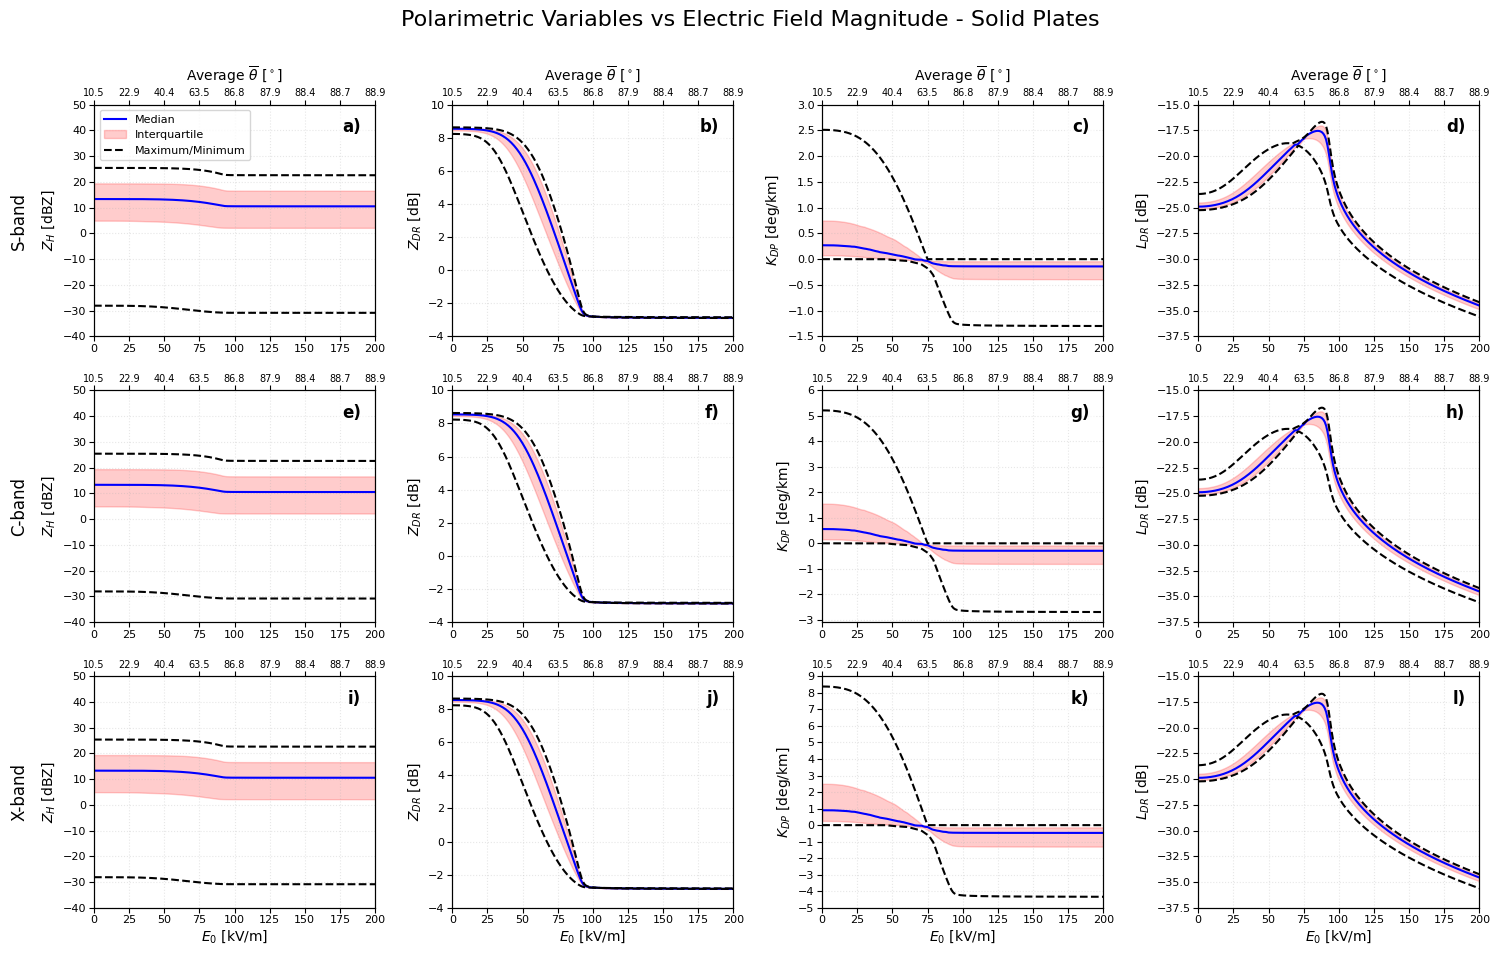

In [6]:
# Mapping functions for the secondary axis
# This assumes secondary_data[i] corresponds to E_vals[i]
def forward(x):
    return np.interp(x, E, secondary_data)

def inverse(x):
    return np.interp(x, secondary_data, E)

dim = (1)

# compute statistics and plots
median_zhS = np.median(data_plateS['zh'], (dim))
zhS_25 = np.percentile(data_plateS['zh'], 25, (dim))
zhS_75 = np.percentile(data_plateS['zh'], 75, (dim))
median_zdrS = np.median(data_plateS['zdr'], (dim))
zdrS_25 = np.percentile(data_plateS['zdr'], 25, (dim))
zdrS_75 = np.percentile(data_plateS['zdr'], 75, (dim))
median_kdpS = np.median(data_plateS['kdp'], (dim))
kdpS_25 = np.percentile(data_plateS['kdp'], 25, (dim))
kdpS_75 = np.percentile(data_plateS['kdp'], 75, (dim))
median_ldrS = np.median(data_plateS['ldr'], (dim))
ldrS_25 = np.percentile(data_plateS['ldr'], 25, (dim))
ldrS_75 = np.percentile(data_plateS['ldr'], 75, (dim))

median_zhC = np.median(data_plateC['zh'], (dim))
zhC_25 = np.percentile(data_plateC['zh'], 25, (dim))
zhC_75 = np.percentile(data_plateC['zh'], 75, (dim))
median_zdrC = np.median(data_plateC['zdr'], (dim))
zdrC_25 = np.percentile(data_plateC['zdr'], 25, (dim))
zdrC_75 = np.percentile(data_plateC['zdr'], 75, (dim))
median_kdpC = np.median(data_plateC['kdp'], (dim))
kdpC_25 = np.percentile(data_plateC['kdp'], 25, (dim))
kdpC_75 = np.percentile(data_plateC['kdp'], 75, (dim))
median_ldrC = np.median(data_plateC['ldr'], (dim))
ldrC_25 = np.percentile(data_plateC['ldr'], 25, (dim))
ldrC_75 = np.percentile(data_plateC['ldr'], 75, (dim))

median_zhX = np.median(data_plateX['zh'], (dim))
zhX_25 = np.percentile(data_plateX['zh'], 25, (dim))
zhX_75 = np.percentile(data_plateX['zh'], 75, (dim))
median_zdrX = np.median(data_plateX['zdr'], (dim))
zdrX_25 = np.percentile(data_plateX['zdr'], 25, (dim))
zdrX_75 = np.percentile(data_plateX['zdr'], 75, (dim))
median_kdpX = np.median(data_plateX['kdp'], (dim))
kdpX_25 = np.percentile(data_plateX['kdp'], 25, (dim))
kdpX_75 = np.percentile(data_plateX['kdp'], 75, (dim))
median_ldrX = np.median(data_plateX['ldr'], (dim))
ldrX_25 = np.percentile(data_plateX['ldr'], 25, (dim))
ldrX_75 = np.percentile(data_plateX['ldr'], 75, (dim))

secondary_data = np.mean(angles_plates['mean'], 1)

fig, axs = plt.subplots(3,4, figsize=[15,9], constrained_layout = True)

rows = [f'{row}' for row in ['S-band', 'C-band', 'X-band']]

for ax, row in zip(axs[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                xycoords=ax.yaxis.label, rotation=90, fontsize = 12, textcoords='offset points',
                ha='right', va='center')

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, median_zhS, c='b', label='Median')
        ax.fill_between(E, zhS_25, zhS_75, alpha=0.2, color='red', label = r'Interquartile')
        #ax.fill_between(E/1e3, np.subtract(mean_zhS, sd_zhS), np.add(mean_zhS, sd_zhS), alpha=0.2, color='red', label = r'$\pm1\sigma$')
        ax.plot(E, np.min(data_plateS['zh'], (dim)), c='k', ls = '--', label=r'Maximum/Minimum')
        ax.plot(E, np.max(data_plateS['zh'], (dim)), c='k', ls = '--')
        #ax.plot(E/1e3, zhS_1, c='k', ls = '--', label=r'$N_0=2\times10^4$ [m$^{-3}$ mm $^{-1}$], $D_0=0.3$')
        #ax.plot(E/1e3, zhS_99, c='k', ls = '-.', label=r'$N_0=2\times10^5$ [m$^{-3}$ mm $^{-1}$], $D_0=0.7$')
        ax.legend(loc = 'upper left', fontsize=8)
        ax.set_ylim(-40, 50)
        
    if n == 1:
        ax.plot(E, median_zdrS, c='b')
        ax.plot(E, np.min(data_plateS['zdr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateS['zdr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_zdrS, sd_zdrS), np.add(mean_zdrS, sd_zdrS), alpha=0.2, color='red')
        ax.fill_between(E, zdrS_25, zdrS_75, alpha=0.2, color='red')
        #ax.plot(E/1e3, zdrS_1, c='k', ls = '--', label=r'$N_0=2\times10^4$ [m$^{-3}$ mm $^{-1}$], $D_0=0.3$')
        #ax.plot(E/1e3, zdrS_99, c='k', ls = '-.', label=r'$N_0=2\times10^5$ [m$^{-3}$ mm $^{-1}$], $D_0=0.7$')
        #ax.set_yticks(np.arange(-3, 2, 0.5))
        ax.set_ylim(-4, 10)
    
    if n == 2:    
        ax.plot(E, median_kdpS, c='b')
        ax.plot(E, np.min(data_plateS['kdp'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateS['kdp'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_kdpS, sd_kdpS), np.add(mean_kdpS, sd_kdpS), alpha=0.2, color='red')
        ax.fill_between(E, kdpS_25, kdpS_75, alpha=0.2, color='red')
        #ax.plot(E/1e3, kdpS_1, c='k', ls = '--', label=r'$N_0=2\times10^4$ [m$^{-3}$ mm $^{-1}$], $D_0=0.3$')
        #ax.plot(E/1e3, kdpS_99, c='k', ls = '-.', label=r'$N_0=2\times10^5$ [m$^{-3}$ mm $^{-1}$], $D_0=0.7$')
        ax.set_ylim(-1.5, 3)

    if n == 3:        
        ax.plot(E, median_ldrS, c='b')
        ax.plot(E, np.min(data_plateS['ldr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateS['ldr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_ldrS, sd_ldrS), np.add(mean_ldrS, sd_ldrS), alpha=0.2, color='red')
        ax.fill_between(E, ldrS_25, ldrS_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-37.5, -12.5, 2.5))

    if n == 4:
        ax.plot(E, median_zhC, c='b', label='Mean')
        #ax.fill_between(E/1e3, np.subtract(mean_zhC, sd_zhC), np.add(mean_zhC, sd_zhC), alpha=0.2, color='red', label = r'$\pm1\sigma$')
        ax.plot(E, np.min(data_plateC['zh'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateC['zh'], (dim)), c='k', ls = '--')
        ax.fill_between(E, zhC_25, zhC_75, alpha=0.2, color='red')
        ax.set_ylim(-40, 50)
        
    if n == 5:
        ax.plot(E, median_zdrC, c='b')
        ax.plot(E, np.min(data_plateC['zdr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateC['zdr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_zdrC, sd_zdrC), np.add(mean_zdrC, sd_zdrC), alpha=0.2, color='red')
        ax.fill_between(E, zdrC_25, zdrC_75, alpha=0.2, color='red')
        ax.set_ylim(-4, 10)
    
    if n == 6:    
        ax.plot(E, median_kdpC, c='b')
        ax.plot(E, np.min(data_plateC['kdp'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateC['kdp'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_kdpC, sd_kdpC), np.add(mean_kdpC, sd_kdpC), alpha=0.2, color='red')
        ax.fill_between(E, kdpC_25, kdpC_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-3, 7, 1))

    if n == 7:        
        ax.plot(E, median_ldrC, c='b')
        ax.plot(E, np.min(data_plateC['ldr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateC['ldr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_ldrX, sd_ldrX), np.add(mean_ldrX, sd_ldrX), alpha=0.2, color='red')
        ax.fill_between(E, ldrC_25, ldrC_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-37.5, -12.5, 2.5))

    if n == 8:
        ax.plot(E, median_zhX, c='b', label='Mean')
        #ax.fill_between(E/1e3, np.subtract(mean_zhC, sd_zhC), np.add(mean_zhC, sd_zhC), alpha=0.2, color='red', label = r'$\pm1\sigma$')
        ax.plot(E, np.min(data_plateX['zh'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateX['zh'], (dim)), c='k', ls = '--')
        ax.fill_between(E, zhX_25, zhX_75, alpha=0.2, color='red')
        ax.set_ylim(-40, 50)
        
    if n == 9:
        ax.plot(E, median_zdrX, c='b')
        ax.plot(E, np.min(data_plateX['zdr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateX['zdr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_zdrC, sd_zdrC), np.add(mean_zdrC, sd_zdrC), alpha=0.2, color='red')
        ax.fill_between(E, zdrX_25, zdrX_75, alpha=0.2, color='red')
        ax.set_ylim(-4, 10)
    
    if n == 10:    
        ax.plot(E, median_kdpX, c='b')
        ax.plot(E, np.min(data_plateX['kdp'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateX['kdp'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_kdpC, sd_kdpC), np.add(mean_kdpC, sd_kdpC), alpha=0.2, color='red')
        ax.fill_between(E, kdpX_25, kdpX_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-5, 10, 1))

    if n == 11:        
        ax.plot(E, median_ldrX, c='b')
        ax.plot(E, np.min(data_plateX['ldr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_plateX['ldr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_ldrX, sd_ldrX), np.add(mean_ldrX, sd_ldrX), alpha=0.2, color='red')
        ax.fill_between(E, ldrX_25, ldrX_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-37.5, -12.5, 2.5))

l = ['a)', 'b)', 'c)', 'd)','e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
# Define primary ticks for alignment
primary_ticks = np.arange(0, 225, 25)

for n, ax in enumerate(axs.ravel()):
    row = n // 4
    col = n % 4
    
    # --- Primary Axis (Bottom) ---
    ax.set_xticks(primary_ticks)
    ax.set_xlim(0, 200)
    ax.tick_params(axis='both', labelsize=8, pad=2)
    ax.grid(True, ls=':', alpha=0.3)

    # SPACE SAVER: Only show the "E [kV/m]" label on the bottom row
    if row == 2:
        ax.set_xlabel(r'$E_0$ [kV/m]', fontsize=10, labelpad=2)
    else:
        ax.set_xlabel('')

    # --- Secondary Axis (Top) ---
    secax = ax.twiny()
    secax.set_xlim(ax.get_xlim())
    secax.set_xticks(primary_ticks)
    
    # Map and format labels to 1 decimal place
    sec_labels = [f"{forward(x):.1f}" for x in primary_ticks]
    secax.set_xticklabels(sec_labels, fontsize=7)
    secax.tick_params(axis='x', pad=1)

    # SPACE SAVER: Only show "Mean [mm]" on the very top row
    if row == 0:
        secax.set_xlabel(r'Average $\overline{\theta}$ $[^\circ]$', fontsize=10, labelpad=5)
    else:
        secax.set_xlabel('')

    # --- Annotation 'a)', 'b)' ---
    # Placed in the top-right corner of each subplot
    ax.annotate(l[n], xy=(0.95, 0.88), xycoords='axes fraction', 
                ha='right', fontsize=12, weight='bold',
                bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':0.6})

    # --- Y-Axis Formatting (Only on the left column) ---
    if col == 0:
        # Define Y-labels based on the row/index
        if row == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
        elif row == 1: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10) # or whatever variable is in row 2
        elif row == 2: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    
    # Use your original column-based logic for specific radar variables:
    if col == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    elif col == 1: ax.set_ylabel(r'$Z_{DR}$ [dB]', fontsize=10)
    elif col == 2: ax.set_ylabel(r'$K_{DP}$ [deg/km]', fontsize=10)
    elif col == 3: ax.set_ylabel(r'$L_{DR}$ [dB]', fontsize=10)

# Adjust spacing so labels don't hit the titles/labels of other plots
plt.rcParams['xtick.major.pad'] = 2

# Set the padding (h_pad is height padding in inches)
fig.set_constrained_layout_pads(h_pad=0.1, w_pad=0.1, hspace=0.05, wspace=0.05)

# Final tweak for title spacing
fig.suptitle('Polarimetric Variables vs Electric Field Magnitude - Solid Plates', fontsize=16, y=1.05)
plt.savefig(f'results_plates.png', bbox_inches = 'tight', dpi=300)

plt.show()


In [7]:
# read the solid short plates look-up tables
with open('sim_full_column_S.pkl',mode='rb') as f:
    data_colS = pickle.load(f)[0]

with open('sim_full_column_C.pkl',mode='rb') as f:
    data_colC = pickle.load(f)[0]

with open('sim_full_column_X.pkl',mode='rb') as f:
    data_colX = pickle.load(f)[0]

for var in data_colS.keys():
    data_colS[var] = data_colS[var].astype(np.float32)

for var in data_colC.keys():
    data_colC[var] = data_colC[var].astype(np.float32)

for var in data_colX.keys():
    data_colX[var] = data_colX[var].astype(np.float32)

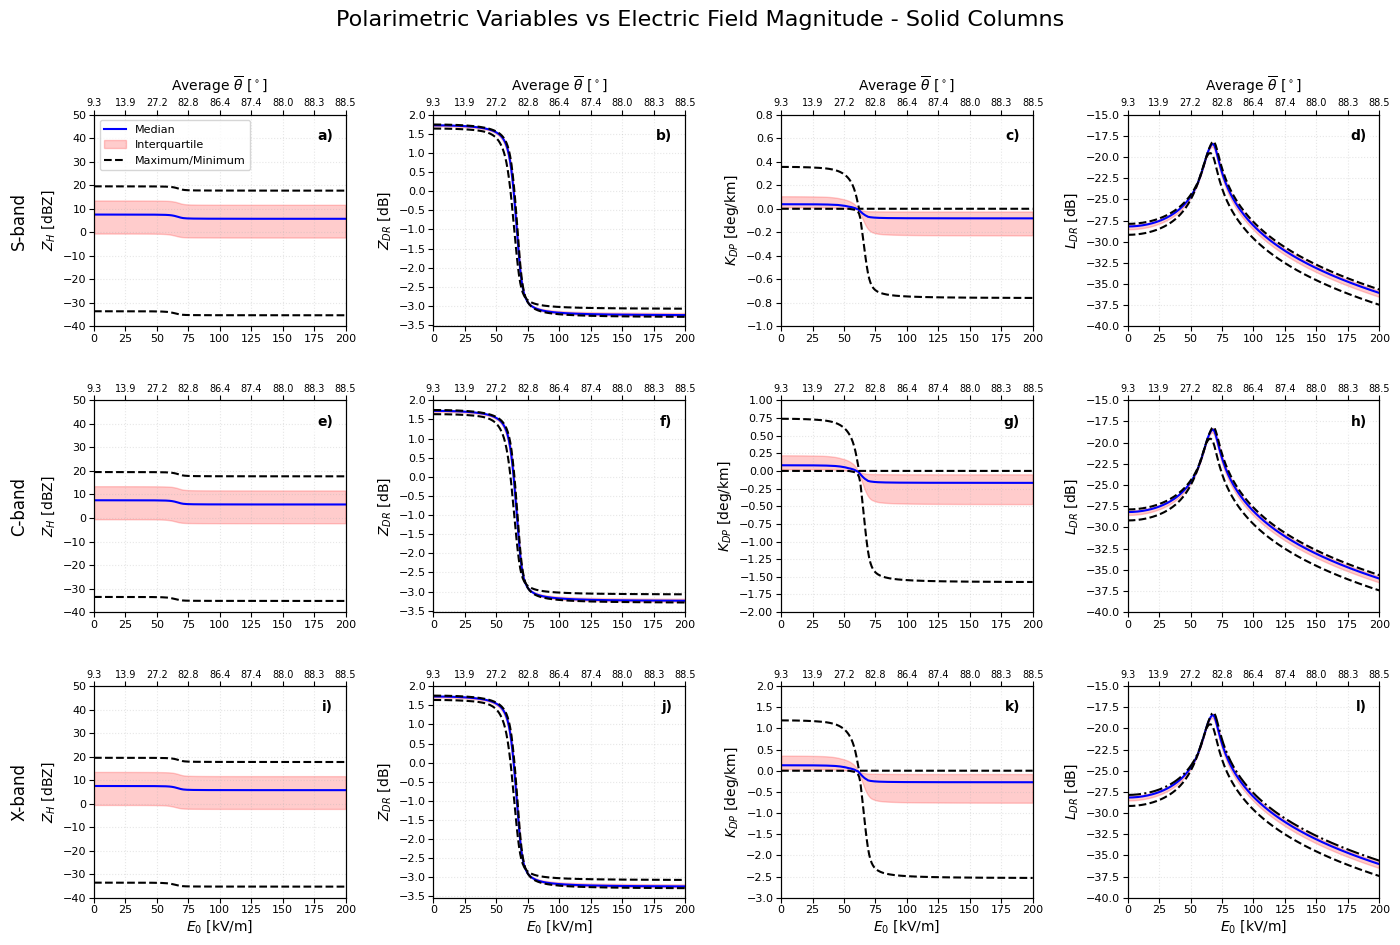

In [8]:
# compute statistics and plots
median_zhS = np.median(data_colS['zh'], (dim))
zhS_25 = np.percentile(data_colS['zh'], 25, (dim))
zhS_75 = np.percentile(data_colS['zh'], 75, (dim))
median_zdrS = np.median(data_colS['zdr'], (dim))
zdrS_25 = np.percentile(data_colS['zdr'], 25, (dim))
zdrS_75 = np.percentile(data_colS['zdr'], 75, (dim))
median_kdpS = np.median(data_colS['kdp'], (dim))
kdpS_25 = np.percentile(data_colS['kdp'], 25, (dim))
kdpS_75 = np.percentile(data_colS['kdp'], 75, (dim))
median_ldrS = np.median(data_colS['ldr'], (dim))
ldrS_25 = np.percentile(data_colS['ldr'], 25, (dim))
ldrS_75 = np.percentile(data_colS['ldr'], 75, (dim))

median_zhC = np.median(data_colC['zh'], (dim))
zhC_25 = np.percentile(data_colC['zh'], 25, (dim))
zhC_75 = np.percentile(data_colC['zh'], 75, (dim))
median_zdrC = np.median(data_colC['zdr'], (dim))
zdrC_25 = np.percentile(data_colC['zdr'], 25, (dim))
zdrC_75 = np.percentile(data_colC['zdr'], 75, (dim))
median_kdpC = np.median(data_colC['kdp'], (dim))
kdpC_25 = np.percentile(data_colC['kdp'], 25, (dim))
kdpC_75 = np.percentile(data_colC['kdp'], 75, (dim))
median_ldrC = np.median(data_colC['ldr'], (dim))
ldrC_25 = np.percentile(data_colC['ldr'], 25, (dim))
ldrC_75 = np.percentile(data_colC['ldr'], 75, (dim))

median_zhX = np.median(data_colX['zh'], (dim))
zhX_25 = np.percentile(data_colX['zh'], 25, (dim))
zhX_75 = np.percentile(data_colX['zh'], 75, (dim))
median_zdrX = np.median(data_colX['zdr'], (dim))
zdrX_25 = np.percentile(data_colX['zdr'], 25, (dim))
zdrX_75 = np.percentile(data_colX['zdr'], 75, (dim))
median_kdpX = np.median(data_colX['kdp'], (dim))
kdpX_25 = np.percentile(data_colX['kdp'], 25, (dim))
kdpX_75 = np.percentile(data_colX['kdp'], 75, (dim))
median_ldrX = np.median(data_colX['ldr'], (dim))
ldrX_25 = np.percentile(data_colX['ldr'], 25, (dim))
ldrX_75 = np.percentile(data_colX['ldr'], 75, (dim))

secondary_data = np.mean(angles_columns['mean'], 1)

fig, axs = plt.subplots(3,4, figsize=[14,9], constrained_layout = True)

for ax, row in zip(axs[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                xycoords=ax.yaxis.label, rotation=90, fontsize = 12, textcoords='offset points',
                ha='right', va='center')

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, median_zhS, c='b', label='Median')
        ax.fill_between(E, zhS_25, zhS_75, alpha=0.2, color='red', label = r'Interquartile')
        #ax.fill_between(E/1e3, np.subtract(mean_zhS, sd_zhS), np.add(mean_zhS, sd_zhS), alpha=0.2, color='red', label = r'$\pm1\sigma$')
        ax.plot(E, np.min(data_colS['zh'], (dim)), c='k', ls = '--', label=r'Maximum/Minimum')
        ax.plot(E, np.max(data_colS['zh'], (dim)), c='k', ls = '--', label=r'')
        ax.legend(loc = 'upper left', fontsize=8)
        ax.set_ylim(-40, 50)
        
    if n == 1:
        ax.plot(E, median_zdrS, c='b')
        ax.plot(E, np.min(data_colS['zdr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colS['zdr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_zdrS, sd_zdrS), np.add(mean_zdrS, sd_zdrS), alpha=0.2, color='red')
        ax.fill_between(E, zdrS_25, zdrS_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-3.5, 2.5, .5))
    
    if n == 2:    
        ax.plot(E, median_kdpS, c='b')
        ax.plot(E, np.min(data_colS['kdp'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colS['kdp'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_kdpS, sd_kdpS), np.add(mean_kdpS, sd_kdpS), alpha=0.2, color='red')
        ax.fill_between(E, kdpS_25, kdpS_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-1, 1, .2))
        #ax.set_ylim(-1, 0.5)

    if n == 3:        
        ax.plot(E, median_ldrS, c='b')
        ax.plot(E, np.min(data_colS['ldr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colS['ldr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_ldrS, sd_ldrS), np.add(mean_ldrS, sd_ldrS), alpha=0.2, color='red')
        ax.fill_between(E, ldrS_25, ldrS_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-40, -12.5, 2.5))

    if n == 4:
        ax.plot(E, median_zhC, c='b', label='Mean')
        #ax.fill_between(E/1e3, np.subtract(mean_zhC, sd_zhC), np.add(mean_zhC, sd_zhC), alpha=0.2, color='red', label = r'$\pm1\sigma$')
        ax.plot(E, np.min(data_colC['zh'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colC['zh'], (dim)), c='k', ls = '--')
        ax.fill_between(E, zhC_25, zhC_75, alpha=0.2, color='red')
        ax.set_ylim(-40, 50)
        
    if n == 5:
        ax.plot(E, median_zdrC, c='b')
        ax.plot(E, np.min(data_colC['zdr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colC['zdr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_zdrC, sd_zdrC), np.add(mean_zdrC, sd_zdrC), alpha=0.2, color='red')
        ax.fill_between(E, zdrC_25, zdrC_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-3.5, 2.5, .5))
    
    if n == 6:    
        ax.plot(E, median_kdpC, c='b')
        ax.plot(E, np.min(data_colC['kdp'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colC['kdp'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_kdpC, sd_kdpC), np.add(mean_kdpC, sd_kdpC), alpha=0.2, color='red')
        ax.fill_between(E, kdpC_25, kdpC_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-2, 1.25, .25))
        ax.set_ylim(-2, 1)

    if n == 7:        
        ax.plot(E, median_ldrC, c='b')
        ax.plot(E, np.min(data_colC['ldr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colC['ldr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_ldrX, sd_ldrX), np.add(mean_ldrX, sd_ldrX), alpha=0.2, color='red')
        ax.fill_between(E, ldrC_25, ldrC_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-40, -12.5, 2.5))

    if n == 8:
        ax.plot(E, median_zhX, c='b', label='Mean')
        #ax.fill_between(E/1e3, np.subtract(mean_zhC, sd_zhC), np.add(mean_zhC, sd_zhC), alpha=0.2, color='red', label = r'$\pm1\sigma$')
        ax.plot(E, np.min(data_colX['zh'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colX['zh'], (dim)), c='k', ls = '--')
        ax.fill_between(E, zhX_25, zhX_75, alpha=0.2, color='red')
        ax.set_ylim(-40, 50)
        
    if n == 9:
        ax.plot(E, median_zdrX, c='b')
        ax.plot(E, np.min(data_colX['zdr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colX['zdr'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_zdrC, sd_zdrC), np.add(mean_zdrC, sd_zdrC), alpha=0.2, color='red')
        ax.fill_between(E, zdrX_25, zdrX_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-3.5, 2.5, .5))
    
    if n == 10:    
        ax.plot(E, median_kdpX, c='b')
        ax.plot(E, np.min(data_colX['kdp'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colX['kdp'], (dim)), c='k', ls = '--')
        #ax.fill_between(E/1e3, np.subtract(mean_kdpC, sd_kdpC), np.add(mean_kdpC, sd_kdpC), alpha=0.2, color='red')
        ax.fill_between(E, kdpX_25, kdpX_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-3, 2.5, .5))

    if n == 11:        
        ax.plot(E, median_ldrX, c='b')
        ax.plot(E, np.min(data_colX['ldr'], (dim)), c='k', ls = '--')
        ax.plot(E, np.max(data_colX['ldr'], (dim)), c='k', ls = '-.')
        #ax.fill_between(E/1e3, np.subtract(mean_ldrX, sd_ldrX), np.add(mean_ldrX, sd_ldrX), alpha=0.2, color='red')
        ax.fill_between(E, ldrX_25, ldrX_75, alpha=0.2, color='red')
        ax.set_yticks(np.arange(-40, -12.5, 2.5))

# Define primary ticks for alignment
primary_ticks = np.arange(0, 225, 25)

for n, ax in enumerate(axs.ravel()):
    row = n // 4
    col = n % 4
    
    # --- Primary Axis (Bottom) ---
    ax.set_xticks(primary_ticks)
    ax.set_xlim(0, 200)
    ax.tick_params(axis='both', labelsize=8, pad=2)
    ax.grid(True, ls=':', alpha=0.3)

    # SPACE SAVER: Only show the "E [kV/m]" label on the bottom row
    if row == 2:
        ax.set_xlabel(r'$E_0$ [kV/m]', fontsize=10, labelpad=2)
    else:
        ax.set_xlabel('')

    # --- Secondary Axis (Top) ---
    secax = ax.twiny()
    secax.set_xlim(ax.get_xlim())
    secax.set_xticks(primary_ticks)
    
    # Map and format labels to 1 decimal place
    sec_labels = [f"{forward(x):.1f}" for x in primary_ticks]
    secax.set_xticklabels(sec_labels, fontsize=7)
    secax.tick_params(axis='x', pad=1)

    # SPACE SAVER: Only show "Mean [mm]" on the very top row
    if row == 0:
        secax.set_xlabel(r'Average $\overline{\theta}$ $[^\circ]$', fontsize=10, labelpad=5)
    else:
        secax.set_xlabel('')

    # --- Annotation 'a)', 'b)' ---
    # Placed in the top-right corner of each subplot
    ax.annotate(l[n], xy=(0.95, 0.88), xycoords='axes fraction', 
                ha='right', fontsize=10, weight='bold',
                bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':0.6})

    # --- Y-Axis Formatting (Only on the left column) ---
    if col == 0:
        # Define Y-labels based on the row/index
        if row == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
        elif row == 1: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10) # or whatever variable is in row 2
        elif row == 2: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    
    # Use your original column-based logic for specific radar variables:
    if col == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    elif col == 1: ax.set_ylabel(r'$Z_{DR}$ [dB]', fontsize=10)
    elif col == 2: ax.set_ylabel(r'$K_{DP}$ [deg/km]', fontsize=10)
    elif col == 3: ax.set_ylabel(r'$L_{DR}$ [dB]', fontsize=10)

# Adjust spacing so labels don't hit the titles/labels of other plots
plt.rcParams['xtick.major.pad'] = 2

# Set the padding (h_pad is height padding in inches)
fig.set_constrained_layout_pads(h_pad=0.2, w_pad=0.1, hspace=0.05, wspace=0.05)

# Final tweak for title spacing
fig.suptitle('Polarimetric Variables vs Electric Field Magnitude - Solid Columns', fontsize=16, y=1.05)
plt.savefig(f'results_columns.png', bbox_inches = 'tight', dpi=300)
plt.show()

In [9]:
# do the same with the snow aggregates
with open('sim_full_graupel_S.pkl',mode='rb') as f:
    data_graupelS = pickle.load(f)[0]

with open('sim_full_graupel_C.pkl',mode='rb') as f:
    data_graupelC = pickle.load(f)[0]

with open('sim_full_graupel_X.pkl',mode='rb') as f:
    data_graupelX = pickle.load(f)[0]

for var in data_graupelS.keys():
    data_graupelS[var] = data_graupelS[var].astype(np.float32)

for var in data_graupelC.keys():
    data_graupelC[var] = data_graupelC[var].astype(np.float32)

for var in data_graupelX.keys():
    data_graupelX[var] = data_graupelX[var].astype(np.float32)

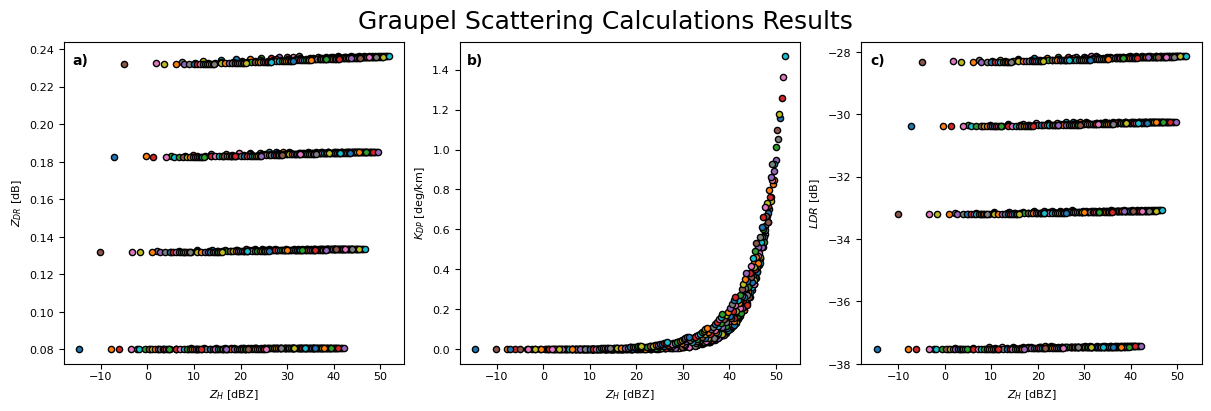

In [10]:
# sanity check
fig, axs = plt.subplots(1,3, figsize=[12,4], constrained_layout = True)

#[axs.ravel()[0].scatter(zh, zv, s=20, edgecolor='k') for zh,zv in zip(data_graupelC['zh'], data_graupelC['zv'])]
#axs.ravel()[0].set_xlabel(r'$Z_{H}$ [dBZ]')
#axs.ravel()[0].set_ylabel(r'$Z_{V}$ [dBZ]')

[axs.ravel()[0].scatter(zh, zdr, s=20, edgecolor='k') for zh,zdr in zip(data_graupelC['zh'], data_graupelC['zdr'])]
axs.ravel()[0].set_xlabel(r'$Z_{H}$ [dBZ]')
axs.ravel()[0].set_ylabel(r'$Z_{DR}$ [dB]')

[axs.ravel()[1].scatter(zh, kdp, s=20, edgecolor='k') for zh,kdp in zip(data_graupelC['zh'], data_graupelC['kdp'])]
axs.ravel()[1].set_xlabel(r'$Z_{H}$ [dBZ]')
axs.ravel()[1].set_ylabel(r'$K_{DP}$ [deg/km]')

[axs.ravel()[2].scatter(zh, ldr, s=20, edgecolor='k') for zh,ldr in zip(data_graupelC['zh'], data_graupelC['ldr'])]
axs.ravel()[2].set_xlabel(r'$Z_{H}$ [dBZ]')
axs.ravel()[2].set_ylabel(r'$LDR$ [dB]')

for n, ax in enumerate(axs.ravel()):
    ax.annotate(l[n], xy=(0.07, 0.93), xycoords='axes fraction', 
                ha='right', fontsize=10, weight='bold',
                bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':0.6})

fig.suptitle('Graupel Scattering Calculations Results', fontsize = 18)

plt.savefig('graupel.png', bbox_inches = 'tight', dpi = 300)

In [11]:
def to_linear(d):
    return {
        "zh": 10.0 ** (d["zh"] / 10.0),
        "zv": 10.0 ** (d["zv"] / 10.0),
        "ldr": 10.0 ** (d["ldr"] / 10.0),
        "kdp": d["kdp"]
    }

def mix_hydrometeors(a, b):
    """
    a, b are dicts with keys zh, zv, ldr, kdp in LINEAR space
    """
    # flatten
    zh_a = a["zh"].ravel()[:, None]
    zh_b = b["zh"].ravel()[None, :]

    zv_a = a["zv"].ravel()[:, None]
    zv_b = b["zv"].ravel()[None, :]

    ldr_a = a["ldr"].ravel()[:, None]
    ldr_b = b["ldr"].ravel()[None, :]

    kdp_a = a["kdp"].ravel()[:, None]
    kdp_b = b["kdp"].ravel()[None, :]

    zh_mix = zh_a + zh_b
    zv_mix = zv_a + zv_b
    ldr_mix = ldr_a + ldr_b
    kdp_mix = kdp_a + kdp_b

    return {
        "ZH": 10.0 * np.log10(zh_mix),
        "ZDR": 10.0 * np.log10(zh_mix / zv_mix),
        "LDR": 10.0 * np.log10(ldr_mix),
        "KDP": kdp_mix
    }

graupelS = to_linear(data_graupelS)
graupelC = to_linear(data_graupelC)
graupelX = to_linear(data_graupelX)

thinS = to_linear(data_plateS)
thinC = to_linear(data_plateC)
thinX = to_linear(data_plateX)

mix_plates_S = mix_hydrometeors(thinS, graupelS)
mix_plates_C = mix_hydrometeors(thinC, graupelC)
mix_plates_X = mix_hydrometeors(thinX, graupelX)

shapes = (E.shape[0], mix_plates_S["ZH"].ravel().shape[0]//201)

mix_plates_ZHS = mix_plates_S["ZH"].ravel().reshape(shapes)
mix_plates_ZDRS = mix_plates_S["ZDR"].ravel().reshape(shapes)
mix_plates_KDPS = mix_plates_S["KDP"].ravel().reshape(shapes)
mix_plates_LDRS = mix_plates_S["LDR"].ravel().reshape(shapes)

mix_plates_ZHC = mix_plates_C["ZH"].ravel().reshape(shapes)
mix_plates_ZDRC = mix_plates_C["ZDR"].ravel().reshape(shapes)
mix_plates_KDPC = mix_plates_C["KDP"].ravel().reshape(shapes)
mix_plates_LDRC = mix_plates_C["LDR"].ravel().reshape(shapes)

mix_plates_ZHX = mix_plates_X["ZH"].ravel().reshape(shapes)
mix_plates_ZDRX = mix_plates_X["ZDR"].ravel().reshape(shapes)
mix_plates_KDPX = mix_plates_X["KDP"].ravel().reshape(shapes)
mix_plates_LDRX = mix_plates_X["LDR"].ravel().reshape(shapes)

shortS = to_linear(data_colS)
shortC = to_linear(data_colC)
shortX = to_linear(data_colX)

mix_columns_S = mix_hydrometeors(shortS, graupelS)
mix_columns_C = mix_hydrometeors(shortC, graupelC)
mix_columns_X = mix_hydrometeors(shortX, graupelX)

mix_columns_ZHS = mix_columns_S["ZH"].ravel().reshape(shapes)
mix_columns_ZDRS = mix_columns_S["ZDR"].ravel().reshape(shapes)
mix_columns_KDPS = mix_columns_S["KDP"].ravel().reshape(shapes)
mix_columns_LDRS = mix_columns_S["LDR"].ravel().reshape(shapes)

mix_columns_ZHC = mix_columns_C["ZH"].ravel().reshape(shapes)
mix_columns_ZDRC = mix_columns_C["ZDR"].ravel().reshape(shapes)
mix_columns_KDPC = mix_columns_C["KDP"].ravel().reshape(shapes)
mix_columns_LDRC = mix_columns_C["LDR"].ravel().reshape(shapes)

mix_columns_ZHX = mix_columns_X["ZH"].ravel().reshape(shapes)
mix_columns_ZDRX = mix_columns_X["ZDR"].ravel().reshape(shapes)
mix_columns_KDPX = mix_columns_X["KDP"].ravel().reshape(shapes)
mix_columns_LDRX = mix_columns_X["LDR"].ravel().reshape(shapes)

In [12]:
#save the output as a pickle file
myvar = [{'zh': mix_plates_ZHS, 'zdr': mix_plates_ZDRS, 'kdp': mix_plates_KDPS, 'ldr': mix_plates_LDRS}] 

#Open a file and use dump() 
with open('sim_mix_plates_graupel_S.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_plates_ZHC, 'zdr': mix_plates_ZDRC, 'kdp': mix_plates_KDPC, 'ldr': mix_plates_LDRC}] 

#Open a file and use dump() 
with open('sim_mix_plates_graupel_C.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_plates_ZHX, 'zdr': mix_plates_ZDRX, 'kdp': mix_plates_KDPX, 'ldr': mix_plates_LDRX}] 

#Open a file and use dump() 
with open('sim_mix_plates_graupel_X.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_columns_ZHS, 'zdr': mix_columns_ZDRS, 'kdp': mix_columns_KDPS, 'ldr': mix_columns_LDRS}] 

#Open a file and use dump() 
with open('sim_mix_columns_graupel_S.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_columns_ZHC, 'zdr': mix_columns_ZDRC, 'kdp': mix_columns_KDPC, 'ldr': mix_columns_LDRC}] 

#Open a file and use dump() 
with open('sim_mix_columns_graupel_C.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_columns_ZHX, 'zdr': mix_columns_ZDRX, 'kdp': mix_columns_KDPX, 'ldr': mix_columns_LDRX}] 

#Open a file and use dump() 
with open('sim_mix_columns_graupel_X.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

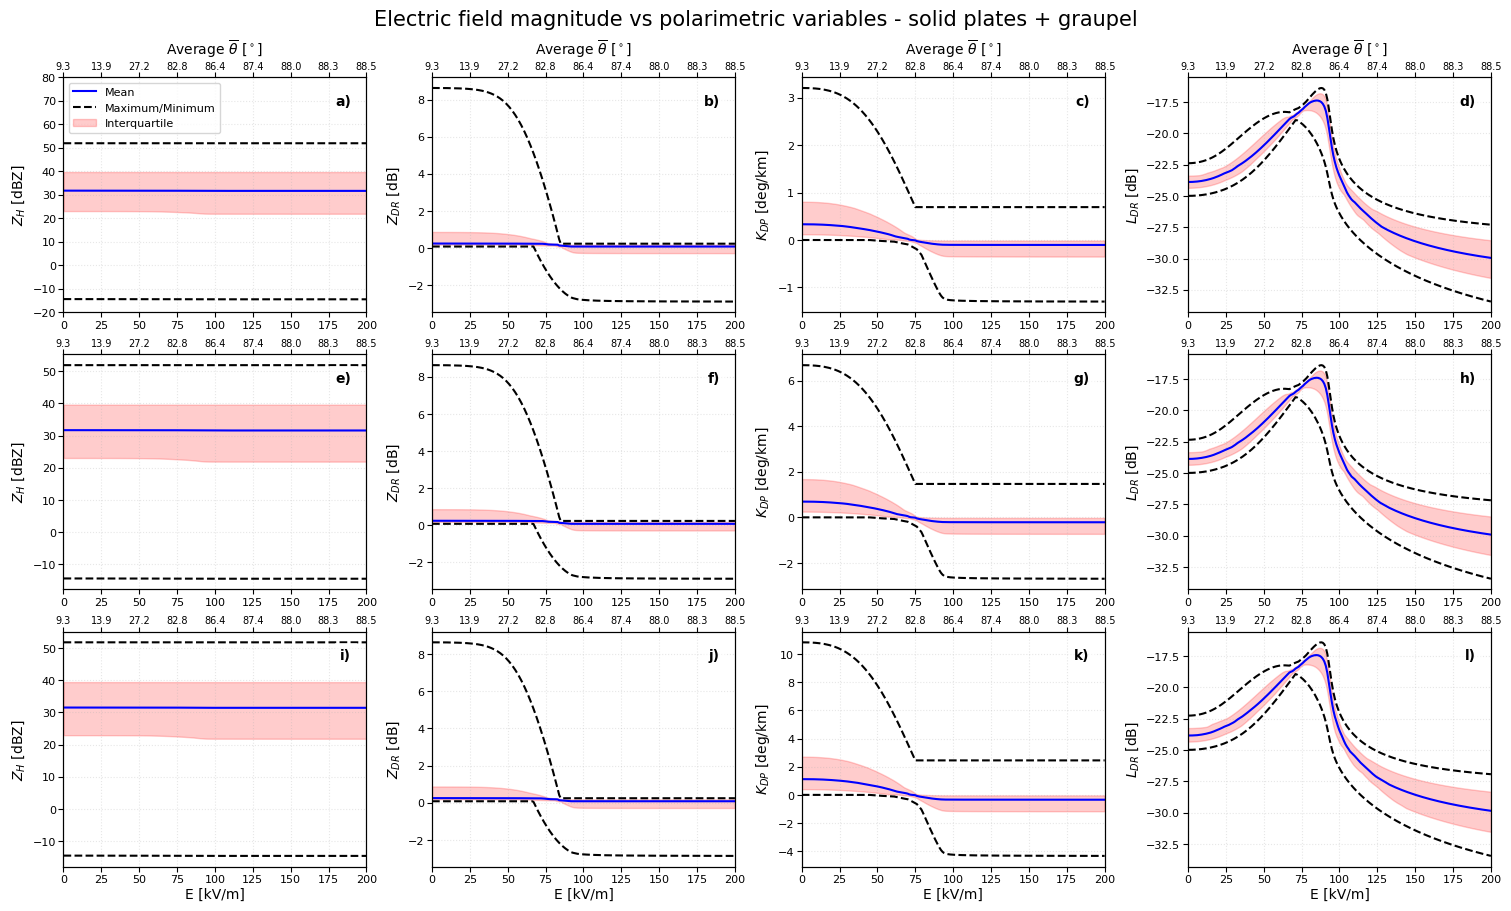

In [13]:
# plot the graupel/crystal mixtures
fig, axs = plt.subplots(3,4, figsize=[15,9], constrained_layout = True)

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, np.median(mix_plates_ZHS, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZHS, 1), c='k', ls = '--', label=r'Maximum/Minimum')
        ax.plot(E, np.max(mix_plates_ZHS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZHS, 25, 1), np.percentile(mix_plates_ZHS, 75, 1), alpha=0.2, color='red', label = r'Interquartile')
        ax.legend(loc = 'upper left', fontsize=8)
        ax.set_yticks(np.arange(-20, 90, 10))
        
    if n == 1:
        ax.plot(E, np.median(mix_plates_ZDRS, 1), c='b')
        ax.plot(E, np.min(mix_plates_ZDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZDRS, 25, 1), np.percentile(mix_plates_ZDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-4, 10, 1))
    
    if n == 2:    
        ax.plot(E, np.median(mix_plates_KDPS, 1), c='b')
        ax.plot(E, np.min(mix_plates_KDPS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_KDPS, 25, 1), np.percentile(mix_plates_KDPS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-0.8, 0.4, 0.1))

    if n == 3:        
        ax.plot(E, np.median(mix_plates_LDRS, 1), c='b')
        ax.plot(E, np.min(mix_plates_LDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_LDRS, 25, 1), np.percentile(mix_plates_LDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 4:
        ax.plot(E, np.median(mix_plates_ZHC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZHC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZHC, 25, 1), np.percentile(mix_plates_ZHC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-20, 90, 10))
        
    if n == 5:
        ax.plot(E, np.median(mix_plates_ZDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZDRC, 25, 1), np.percentile(mix_plates_ZDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-4, 10, 1))
    
    if n == 6:    
        ax.plot(E, np.median(mix_plates_KDPC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_KDPC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_KDPC, 25, 1), np.percentile(mix_plates_KDPC, 75, 1), alpha=0.2, color='red')

    if n == 7:        
        ax.plot(E, np.median(mix_plates_LDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_LDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_LDRC, 25, 1), np.percentile(mix_plates_LDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 8:
        ax.plot(E, np.median(mix_plates_ZHX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZHX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZHX, 25, 1), np.percentile(mix_plates_ZHX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-20, 90, 10))
        
    if n == 9:
        ax.plot(E, np.median(mix_plates_ZDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZDRX, 25, 1), np.percentile(mix_plates_ZDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-4, 10, 1))
    
    if n == 10:    
        ax.plot(E, np.median(mix_plates_KDPX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_KDPX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_KDPX, 25, 1), np.percentile(mix_plates_KDPX, 75, 1), alpha=0.2, color='red')

    if n == 11:        
        ax.plot(E, np.median(mix_plates_LDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_LDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_LDRX, 25, 1), np.percentile(mix_plates_LDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))


for n, ax in enumerate(axs.ravel()):
    row = n // 4
    col = n % 4
    
    # --- Primary Axis (Bottom) ---
    ax.set_xticks(primary_ticks)
    ax.set_xlim(0, 200)
    ax.tick_params(axis='both', labelsize=8, pad=2)
    ax.grid(True, ls=':', alpha=0.3)

    # SPACE SAVER: Only show the "E [kV/m]" label on the bottom row
    if row == 2:
        ax.set_xlabel('E [kV/m]', fontsize=10, labelpad=2)
    else:
        ax.set_xlabel('')

    # --- Secondary Axis (Top) ---
    secax = ax.twiny()
    secax.set_xlim(ax.get_xlim())
    secax.set_xticks(primary_ticks)
    
    # Map and format labels to 1 decimal place
    sec_labels = [f"{forward(x):.1f}" for x in primary_ticks]
    secax.set_xticklabels(sec_labels, fontsize=7)
    secax.tick_params(axis='x', pad=1)

    # SPACE SAVER: Only show "Mean [mm]" on the very top row
    if row == 0:
        secax.set_xlabel(r'Average $\overline{\theta}$ $[^\circ]$', fontsize=10, labelpad=5)
    else:
        secax.set_xlabel('')

    # --- Annotation 'a)', 'b)' ---
    # Placed in the top-right corner of each subplot
    ax.annotate(l[n], xy=(0.95, 0.88), xycoords='axes fraction', 
                ha='right', fontsize=10, weight='bold',
                bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':0.6})

    # --- Y-Axis Formatting (Only on the left column) ---
    if col == 0:
        # Define Y-labels based on the row/index
        if row == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
        elif row == 1: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10) # or whatever variable is in row 2
        elif row == 2: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    
    # Use your original column-based logic for specific radar variables:
    if col == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    elif col == 1: ax.set_ylabel(r'$Z_{DR}$ [dB]', fontsize=10)
    elif col == 2: ax.set_ylabel(r'$K_{DP}$ [deg/km]', fontsize=10)
    elif col == 3: ax.set_ylabel(r'$L_{DR}$ [dB]', fontsize=10)

fig.suptitle('Electric field magnitude vs polarimetric variables - solid plates + graupel', fontsize = 15)

plt.savefig(f'results_graupel_plates.png', bbox_inches = 'tight', dpi=300)

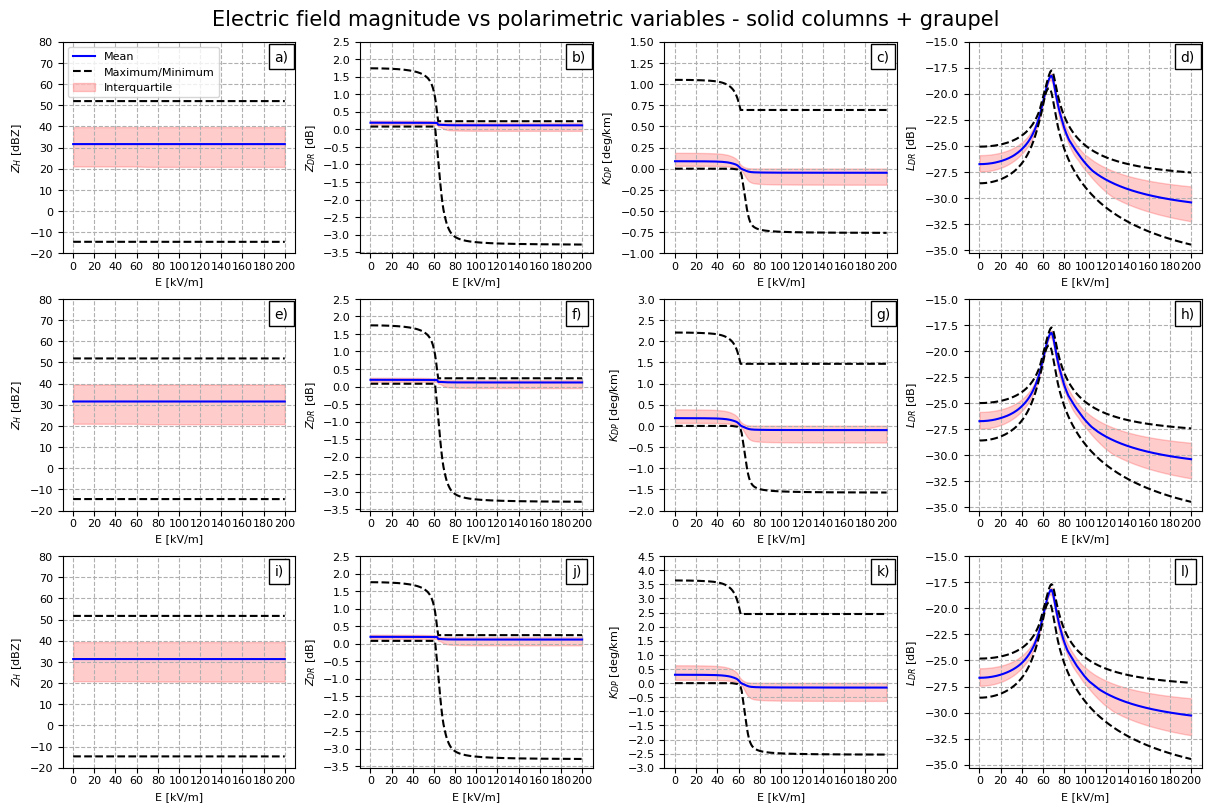

In [14]:
# plot the graupel/crystal mixtures
fig, axs = plt.subplots(3,4, figsize=[12,8], constrained_layout = True)

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, np.median(mix_columns_ZHS, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZHS, 1), c='k', ls = '--', label=r'Maximum/Minimum')
        ax.plot(E, np.max(mix_columns_ZHS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZHS, 25, 1), np.percentile(mix_columns_ZHS, 75, 1), alpha=0.2, color='red', label = r'Interquartile')
        ax.legend(loc = 'upper left', fontsize=8)
        
    if n == 1:
        ax.plot(E, np.median(mix_columns_ZDRS, 1), c='b')
        ax.plot(E, np.min(mix_columns_ZDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZDRS, 25, 1), np.percentile(mix_columns_ZDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 2:    
        ax.plot(E, np.median(mix_columns_KDPS, 1), c='b')
        ax.plot(E, np.min(mix_columns_KDPS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_KDPS, 25, 1), np.percentile(mix_columns_KDPS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-0.8, 0.4, 0.1))

    if n == 3:        
        ax.plot(E, np.median(mix_columns_LDRS, 1), c='b')
        ax.plot(E, np.min(mix_columns_LDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_LDRS, 25, 1), np.percentile(mix_columns_LDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 4:
        ax.plot(E, np.median(mix_columns_ZHC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZHC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZHC, 25, 1), np.percentile(mix_columns_ZHC, 75, 1), alpha=0.2, color='red')
        #ax.set_ylim(-20, 45)
        
    if n == 5:
        ax.plot(E, np.median(mix_columns_ZDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZDRC, 25, 1), np.percentile(mix_columns_ZDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 6:    
        ax.plot(E, np.median(mix_columns_KDPC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_KDPC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_KDPC, 25, 1), np.percentile(mix_columns_KDPC, 75, 1), alpha=0.2, color='red')

    if n == 7:        
        ax.plot(E, np.median(mix_columns_LDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_LDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_LDRC, 25, 1), np.percentile(mix_columns_LDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 8:
        ax.plot(E, np.median(mix_columns_ZHX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZHX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZHX, 25, 1), np.percentile(mix_columns_ZHX, 75, 1), alpha=0.2, color='red')
        #ax.set_ylim(-20, 45)
        
    if n == 9:
        ax.plot(E, np.median(mix_columns_ZDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZDRX, 25, 1), np.percentile(mix_columns_ZDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 10:    
        ax.plot(E, np.median(mix_columns_KDPX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_KDPX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_KDPX, 25, 1), np.percentile(mix_columns_KDPX, 75, 1), alpha=0.2, color='red')

    if n == 11:        
        ax.plot(E, np.median(mix_columns_LDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_LDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_LDRX, 25, 1), np.percentile(mix_columns_LDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))


l = ['a)', 'b)', 'c)', 'd)','e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
for n, ax in enumerate(axs.ravel()):
    ax.set_xlabel('E [kV/m]')
    ax.set_xticks(np.arange(0, 220, 20))
    ax.annotate(l[n], xy = (0.91, 0.91), xycoords = 'axes fraction', fontsize = 10, bbox={'facecolor':'white', 'clip_on':True}, zorder = 50)
    ax.grid(True, ls = '--', which = 'both')
    if (n == 0 or n == 4 or n == 8):
        ax.set_ylabel(r'$Z_{H}$ [dBZ]') 
        ax.set_yticks(np.arange(-20, 90, 10))
    if (n == 1 or n == 5 or n == 9):
        ax.set_ylabel(r'$Z_{DR}$ [dB]')
        ax.set_yticks(np.arange(-3.5, 3, 0.5))
    if (n == 2 or n == 6 or n == 10):
        ax.set_ylabel(r'$K_{DP}$ [deg/km]')
        if n == 2:
            ax.set_yticks(np.arange(-1, 1.75, 0.25))
        elif n == 6:
            ax.set_yticks(np.arange(-2, 3.5, 0.5))
        else:
            ax.set_yticks(np.arange(-3, 5, 0.5))
    if (n == 3 or n == 7 or n == 11):
        ax.set_ylabel(r'$L_{DR}$ [dB]')
        ax.set_yticks(np.arange(-35, -12.5, 2.5))

fig.suptitle('Electric field magnitude vs polarimetric variables - solid columns + graupel', fontsize = 15)
plt.savefig(f'results_graupel_columns.png', bbox_inches = 'tight', dpi=300)

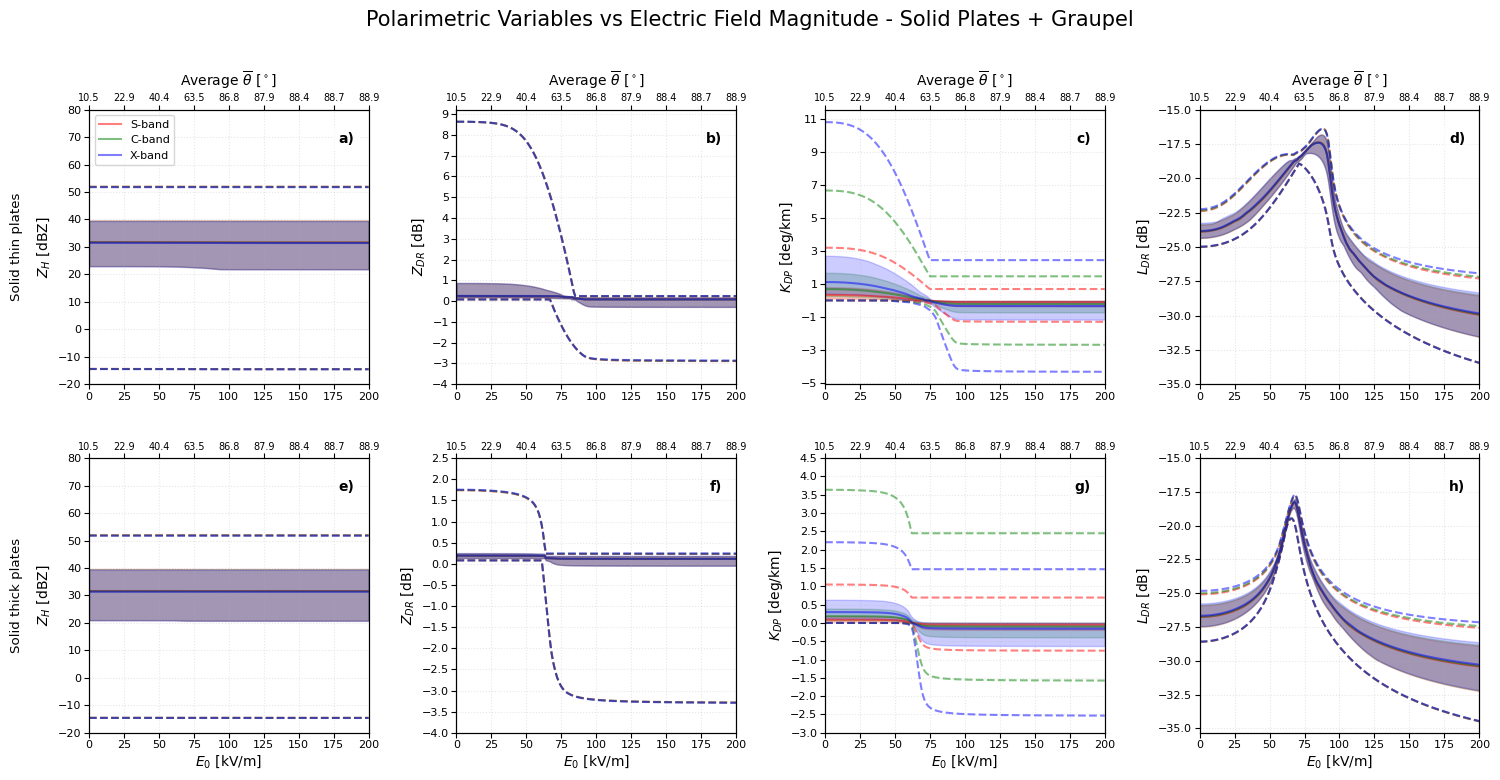

In [18]:
secondary_data = np.mean(angles_plates['mean'], 1)

fig, axs = plt.subplots(2,4, figsize=[15,8], constrained_layout = True)

rows = [f'{row}' for row in ['Solid thin plates', 'Solid thick plates', 'Solid short columns', 'Solid long columns']]

for ax, row in zip(axs[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                xycoords=ax.yaxis.label, rotation=90, textcoords='offset points',
                size='large', ha='right', va='center')

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, np.median(mix_plates_ZHS, 1), alpha=0.5, c='r', label = r'S-band')
        ax.plot(E, np.median(mix_plates_ZHC, 1), alpha=0.5, c='g', label = r'C-band')
        ax.plot(E, np.median(mix_plates_ZHX, 1), alpha=0.5, c='b', label = r'X-band')
        ax.fill_between(E, np.percentile(mix_plates_ZHS, 25, 1), np.percentile(mix_plates_ZHS, 75, 1), alpha=0.2, color='red')
        ax.fill_between(E, np.percentile(mix_plates_ZHC, 25, 1), np.percentile(mix_plates_ZHC, 75, 1), alpha=0.2, color='green')
        ax.fill_between(E, np.percentile(mix_plates_ZHX, 25, 1), np.percentile(mix_plates_ZHX, 75, 1), alpha=0.2, color='blue')
        ax.plot(E, np.min(mix_plates_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.legend(loc='upper left')
        ax.set_yticks(np.arange(-20, 90, 10))
        
    if n == 1:
        ax.plot(E, np.median(mix_plates_ZDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_plates_ZDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_plates_ZDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_plates_ZDRS, 25, 1), np.percentile(mix_plates_ZDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_plates_ZDRC, 25, 1), np.percentile(mix_plates_ZDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_plates_ZDRX, 25, 1), np.percentile(mix_plates_ZDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_plates_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-4, 10, 1))
    
    if n == 2:    
        ax.plot(E, np.median(mix_plates_KDPS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_plates_KDPC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_plates_KDPX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_plates_KDPS, 25, 1), np.percentile(mix_plates_KDPS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_plates_KDPC, 25, 1), np.percentile(mix_plates_KDPC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_plates_KDPX, 25, 1), np.percentile(mix_plates_KDPX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_plates_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_KDPC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_KDPX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-5, 12, 2))

    if n == 3:        
        ax.plot(E, np.median(mix_plates_LDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_plates_LDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_plates_LDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_plates_LDRS, 25, 1), np.percentile(mix_plates_LDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_plates_LDRC, 25, 1), np.percentile(mix_plates_LDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_plates_LDRX, 25, 1), np.percentile(mix_plates_LDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_plates_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-35, -12.5, 2.5))
        
    if n == 4:
        ax.plot(E, np.median(mix_columns_ZHS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_ZHC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_ZHX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_ZHS, 25, 1), np.percentile(mix_columns_ZHS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_ZHC, 25, 1), np.percentile(mix_columns_ZHC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_ZHX, 25, 1), np.percentile(mix_columns_ZHX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-20, 90, 10))
        
    if n == 5:
        ax.plot(E, np.median(mix_columns_ZDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_ZDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_ZDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_ZDRS, 25, 1), np.percentile(mix_columns_ZDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_ZDRC, 25, 1), np.percentile(mix_columns_ZDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_ZDRX, 25, 1), np.percentile(mix_columns_ZDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-4, 3, 0.5))
    
    if n == 6:    
        ax.plot(E, np.median(mix_columns_KDPS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_KDPC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_KDPX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_KDPS, 25, 1), np.percentile(mix_columns_KDPS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_KDPC, 25, 1), np.percentile(mix_columns_KDPC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_KDPX, 25, 1), np.percentile(mix_columns_KDPX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_KDPC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_KDPX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPC, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPX, 1), alpha=0.5, c='g', ls = '--')
        ax.set_yticks(np.arange(-3, 5, 0.5))
        
    if n == 7:        
        ax.plot(E, np.median(mix_columns_LDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_LDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_LDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_LDRS, 25, 1), np.percentile(mix_columns_LDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_LDRC, 25, 1), np.percentile(mix_columns_LDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_LDRX, 25, 1), np.percentile(mix_columns_LDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-35, -12.5, 2.5))


l = ['a)', 'b)', 'c)', 'd)','e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
# Define primary ticks for alignment
primary_ticks = np.arange(0, 225, 25)

for n, ax in enumerate(axs.ravel()):
    row = n // 4
    col = n % 4
    
    # --- Primary Axis (Bottom) ---
    ax.set_xticks(primary_ticks)
    ax.set_xlim(0, 200)
    ax.tick_params(axis='both', labelsize=8, pad=2)
    ax.grid(True, ls=':', alpha=0.3)

    # SPACE SAVER: Only show the "E [kV/m]" label on the bottom row
    if row == 1:
        ax.set_xlabel(r'$E_0$ [kV/m]', fontsize=10, labelpad=2)
    else:
        ax.set_xlabel('')

    # --- Secondary Axis (Top) ---
    secax = ax.twiny()
    secax.set_xlim(ax.get_xlim())
    secax.set_xticks(primary_ticks)
    
    # Map and format labels to 1 decimal place
    sec_labels = [f"{forward(x):.1f}" for x in primary_ticks]
    secax.set_xticklabels(sec_labels, fontsize=7)
    secax.tick_params(axis='x', pad=1)

    # SPACE SAVER: Only show "Mean [mm]" on the very top row
    if row == 0:
        secax.set_xlabel(r'Average $\overline{\theta}$ $[^\circ]$', fontsize=10, labelpad=5)
    else:
        secax.set_xlabel('')

    # --- Annotation 'a)', 'b)' ---
    # Placed in the top-right corner of each subplot
    ax.annotate(l[n], xy=(0.95, 0.88), xycoords='axes fraction', 
                ha='right', fontsize=10, weight='bold',
                bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':0.6})

    # --- Y-Axis Formatting (Only on the left column) ---
    if col == 0:
        # Define Y-labels based on the row/index
        if row == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
        elif row == 1: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10) # or whatever variable is in row 2
        elif row == 2: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    
    # Use your original column-based logic for specific radar variables:
    if col == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    elif col == 1: ax.set_ylabel(r'$Z_{DR}$ [dB]', fontsize=10)
    elif col == 2: ax.set_ylabel(r'$K_{DP}$ [deg/km]', fontsize=10)
    elif col == 3: ax.set_ylabel(r'$L_{DR}$ [dB]', fontsize=10)

# Adjust spacing so labels don't hit the titles/labels of other plots
plt.rcParams['xtick.major.pad'] = 2

# Set the padding (h_pad is height padding in inches)
fig.set_constrained_layout_pads(h_pad=0.2, w_pad=0.1, hspace=0.05, wspace=0.05)

fig.suptitle('Polarimetric Variables vs Electric Field Magnitude - Solid Plates + Graupel', fontsize = 15)

plt.savefig(f'results_crystal_graupel.png', bbox_inches = 'tight', dpi=300)
#plt.savefig(f'results_crystal_graupel_radarconf.png', bbox_inches = 'tight', dpi=300)

In [130]:
# do the same with the snow aggregates
with open('sim_full_snow_S.pkl',mode='rb') as f:
    data_snowS = pickle.load(f)[0]

with open('sim_full_snow_C.pkl',mode='rb') as f:
    data_snowC = pickle.load(f)[0]

with open('sim_full_snow_X.pkl',mode='rb') as f:
    data_snowX = pickle.load(f)[0]

for var in data_snowS.keys():
    data_snowS[var] = data_snowS[var].astype(np.float32)

for var in data_snowC.keys():
    data_snowC[var] = data_snowC[var].astype(np.float32)

for var in data_snowX.keys():
    data_snowX[var] = data_snowX[var].astype(np.float32)

Text(0, 0.5, '$LDR$ [dB]')

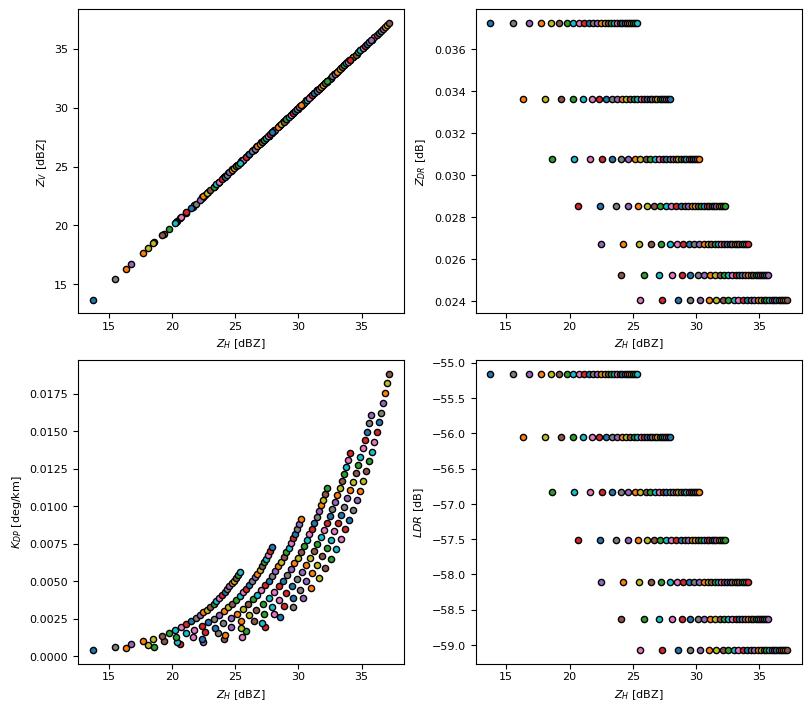

In [131]:
fig, axs = plt.subplots(2,2, figsize=[8,7], constrained_layout = True)

[axs.ravel()[0].scatter(zh, zv, s=20, edgecolor='k') for zh,zv in zip(data_snowS['zh'], data_snowS['zv'])]
axs.ravel()[0].set_xlabel(r'$Z_{H}$ [dBZ]')
axs.ravel()[0].set_ylabel(r'$Z_{V}$ [dBZ]')

[axs.ravel()[1].scatter(zh, zdr, s=20, edgecolor='k') for zh,zdr in zip(data_snowS['zh'], data_snowS['zdr'])]
axs.ravel()[1].set_xlabel(r'$Z_{H}$ [dBZ]')
axs.ravel()[1].set_ylabel(r'$Z_{DR}$ [dB]')

[axs.ravel()[2].scatter(zh, kdp, s=20, edgecolor='k') for zh,kdp in zip(data_snowS['zh'], data_snowS['kdp'])]
axs.ravel()[2].set_xlabel(r'$Z_{H}$ [dBZ]')
axs.ravel()[2].set_ylabel(r'$K_{DP}$ [deg/km]')

[axs.ravel()[3].scatter(zh, ldr, s=20, edgecolor='k') for zh,ldr in zip(data_snowS['zh'], data_snowS['ldr'])]
axs.ravel()[3].set_xlabel(r'$Z_{H}$ [dBZ]')
axs.ravel()[3].set_ylabel(r'$LDR$ [dB]')

In [132]:
def to_linear(d):
    return {
        "zh": 10.0 ** (d["zh"] / 10.0),
        "zv": 10.0 ** (d["zv"] / 10.0),
        "ldr": 10.0 ** (d["ldr"] / 10.0),
        "kdp": d["kdp"]
    }

def mix_hydrometeors(a, b):
    """
    a, b are dicts with keys zh, zv, ldr, kdp in LINEAR space
    """
    # flatten
    zh_a = a["zh"].ravel()[:, None]
    zh_b = b["zh"].ravel()[None, :]

    zv_a = a["zv"].ravel()[:, None]
    zv_b = b["zv"].ravel()[None, :]

    ldr_a = a["ldr"].ravel()[:, None]
    ldr_b = b["ldr"].ravel()[None, :]

    kdp_a = a["kdp"].ravel()[:, None]
    kdp_b = b["kdp"].ravel()[None, :]

    zh_mix = zh_a + zh_b
    zv_mix = zv_a + zv_b
    ldr_mix = ldr_a + ldr_b
    kdp_mix = kdp_a + kdp_b

    return {
        "ZH": 10.0 * np.log10(zh_mix),
        "ZDR": 10.0 * np.log10(zh_mix / zv_mix),
        "LDR": 10.0 * np.log10(ldr_mix),
        "KDP": kdp_mix
    }

snowS = to_linear(data_snowS)
snowC = to_linear(data_snowC)
snowX = to_linear(data_snowX)

thinS = to_linear(data_plateS)
thinC = to_linear(data_plateC)
thinX = to_linear(data_plateX)

mix_plates_S = mix_hydrometeors(thinS, snowS)
mix_plates_C = mix_hydrometeors(thinC, snowC)
mix_plates_X = mix_hydrometeors(thinX, snowX)

shapes = (E.shape[0], mix_plates_S["ZH"].ravel().shape[0]//201)

mix_plates_ZHS = mix_plates_S["ZH"].ravel().reshape(shapes)
mix_plates_ZDRS = mix_plates_S["ZDR"].ravel().reshape(shapes)
mix_plates_KDPS = mix_plates_S["KDP"].ravel().reshape(shapes)
mix_plates_LDRS = mix_plates_S["LDR"].ravel().reshape(shapes)

mix_plates_ZHC = mix_plates_C["ZH"].ravel().reshape(shapes)
mix_plates_ZDRC = mix_plates_C["ZDR"].ravel().reshape(shapes)
mix_plates_KDPC = mix_plates_C["KDP"].ravel().reshape(shapes)
mix_plates_LDRC = mix_plates_C["LDR"].ravel().reshape(shapes)

mix_plates_ZHX = mix_plates_X["ZH"].ravel().reshape(shapes)
mix_plates_ZDRX = mix_plates_X["ZDR"].ravel().reshape(shapes)
mix_plates_KDPX = mix_plates_X["KDP"].ravel().reshape(shapes)
mix_plates_LDRX = mix_plates_X["LDR"].ravel().reshape(shapes)

shortS = to_linear(data_colS)
shortC = to_linear(data_colC)
shortX = to_linear(data_colX)

mix_columns_S = mix_hydrometeors(shortS, snowS)
mix_columns_C = mix_hydrometeors(shortC, snowC)
mix_columns_X = mix_hydrometeors(shortX, snowX)

mix_columns_ZHS = mix_columns_S["ZH"].ravel().reshape(shapes)
mix_columns_ZDRS = mix_columns_S["ZDR"].ravel().reshape(shapes)
mix_columns_KDPS = mix_columns_S["KDP"].ravel().reshape(shapes)
mix_columns_LDRS = mix_columns_S["LDR"].ravel().reshape(shapes)

mix_columns_ZHC = mix_columns_C["ZH"].ravel().reshape(shapes)
mix_columns_ZDRC = mix_columns_C["ZDR"].ravel().reshape(shapes)
mix_columns_KDPC = mix_columns_C["KDP"].ravel().reshape(shapes)
mix_columns_LDRC = mix_columns_C["LDR"].ravel().reshape(shapes)

mix_columns_ZHX = mix_columns_X["ZH"].ravel().reshape(shapes)
mix_columns_ZDRX = mix_columns_X["ZDR"].ravel().reshape(shapes)
mix_columns_KDPX = mix_columns_X["KDP"].ravel().reshape(shapes)
mix_columns_LDRX = mix_columns_X["LDR"].ravel().reshape(shapes)

In [133]:
#save the output as a pickle file
myvar = [{'zh': mix_plates_ZHS, 'zdr': mix_plates_ZDRS, 'kdp': mix_plates_KDPS, 'ldr': mix_plates_LDRS}] 

#Open a file and use dump() 
with open('sim_mix_plates_snow_S.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_plates_ZHC, 'zdr': mix_plates_ZDRC, 'kdp': mix_plates_KDPC, 'ldr': mix_plates_LDRC}] 

#Open a file and use dump() 
with open('sim_mix_plates_snow_C.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_plates_ZHX, 'zdr': mix_plates_ZDRX, 'kdp': mix_plates_KDPX, 'ldr': mix_plates_LDRX}] 

#Open a file and use dump() 
with open('sim_mix_plates_snow_X.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_columns_ZHS, 'zdr': mix_columns_ZDRS, 'kdp': mix_columns_KDPS, 'ldr': mix_columns_LDRS}] 

#Open a file and use dump() 
with open('sim_mix_columns_snow_S.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_columns_ZHC, 'zdr': mix_columns_ZDRC, 'kdp': mix_columns_KDPC, 'ldr': mix_columns_LDRC}] 

#Open a file and use dump() 
with open('sim_mix_columns_snow_C.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

#save the output as a pickle file
myvar = [{'zh': mix_columns_ZHX, 'zdr': mix_columns_ZDRX, 'kdp': mix_columns_KDPX, 'ldr': mix_columns_LDRX}] 

#Open a file and use dump() 
with open('sim_mix_columns_snow_X.pkl', 'wb') as file: 
      
    # A new file will be created 
    pickle.dump(myvar, file) 

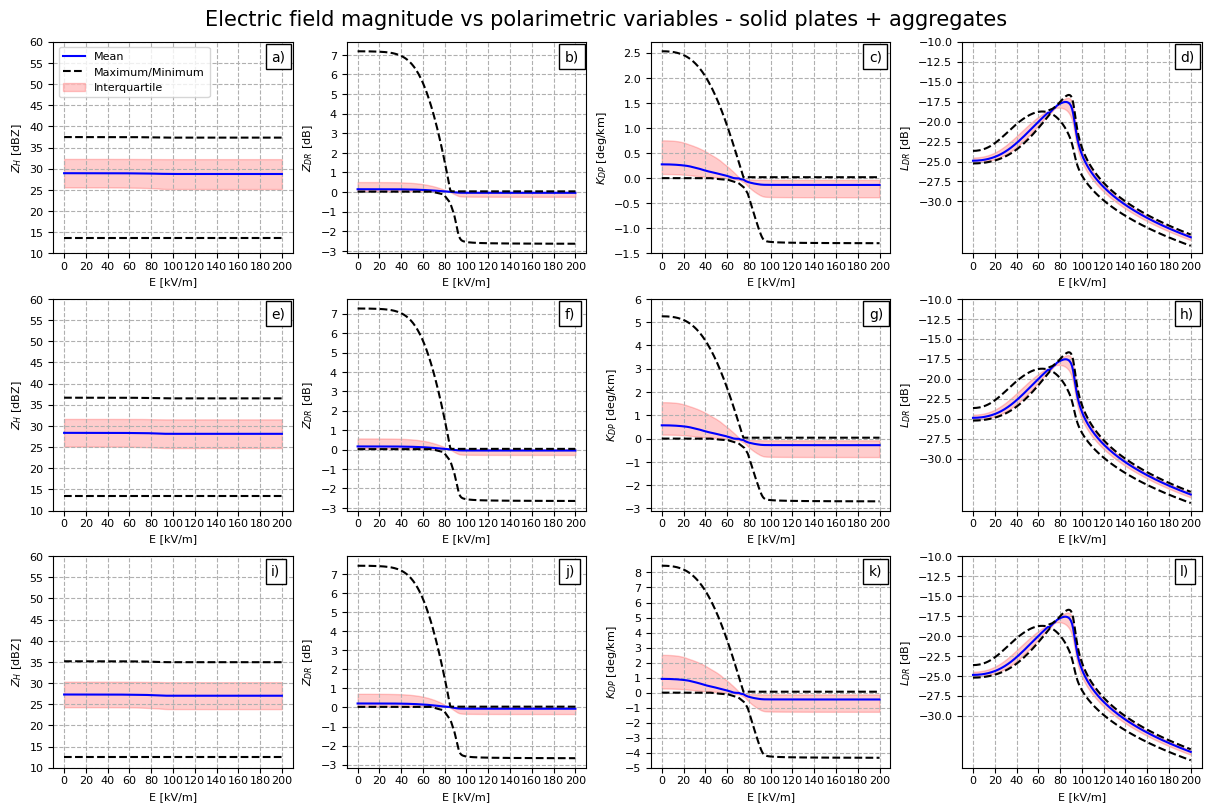

In [134]:
# plot the graupel/crystal mixtures
fig, axs = plt.subplots(3,4, figsize=[12,8], constrained_layout = True)

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, np.median(mix_plates_ZHS, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZHS, 1), c='k', ls = '--', label=r'Maximum/Minimum')
        ax.plot(E, np.max(mix_plates_ZHS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZHS, 25, 1), np.percentile(mix_plates_ZHS, 75, 1), alpha=0.2, color='red', label = r'Interquartile')
        ax.legend(loc = 'upper left', fontsize=8)
        
    if n == 1:
        ax.plot(E, np.median(mix_plates_ZDRS, 1), c='b')
        ax.plot(E, np.min(mix_plates_ZDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZDRS, 25, 1), np.percentile(mix_plates_ZDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 2:    
        ax.plot(E, np.median(mix_plates_KDPS, 1), c='b')
        ax.plot(E, np.min(mix_plates_KDPS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_KDPS, 25, 1), np.percentile(mix_plates_KDPS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-0.8, 0.4, 0.1))

    if n == 3:        
        ax.plot(E, np.median(mix_plates_LDRS, 1), c='b')
        ax.plot(E, np.min(mix_plates_LDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_LDRS, 25, 1), np.percentile(mix_plates_LDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 4:
        ax.plot(E, np.median(mix_plates_ZHC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZHC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZHC, 25, 1), np.percentile(mix_plates_ZHC, 75, 1), alpha=0.2, color='red')
        #ax.set_ylim(-20, 45)
        
    if n == 5:
        ax.plot(E, np.median(mix_plates_ZDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZDRC, 25, 1), np.percentile(mix_plates_ZDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 6:    
        ax.plot(E, np.median(mix_plates_KDPC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_KDPC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_KDPC, 25, 1), np.percentile(mix_plates_KDPC, 75, 1), alpha=0.2, color='red')

    if n == 7:        
        ax.plot(E, np.median(mix_plates_LDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_LDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_LDRC, 25, 1), np.percentile(mix_plates_LDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 8:
        ax.plot(E, np.median(mix_plates_ZHX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZHX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZHX, 25, 1), np.percentile(mix_plates_ZHX, 75, 1), alpha=0.2, color='red')
        #ax.set_ylim(-20, 45)
        
    if n == 9:
        ax.plot(E, np.median(mix_plates_ZDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_ZDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_ZDRX, 25, 1), np.percentile(mix_plates_ZDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 10:    
        ax.plot(E, np.median(mix_plates_KDPX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_KDPX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_KDPX, 25, 1), np.percentile(mix_plates_KDPX, 75, 1), alpha=0.2, color='red')

    if n == 11:        
        ax.plot(E, np.median(mix_plates_LDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_plates_LDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_plates_LDRX, 25, 1), np.percentile(mix_plates_LDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))


l = ['a)', 'b)', 'c)', 'd)','e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
for n, ax in enumerate(axs.ravel()):
    ax.set_xlabel('E [kV/m]')
    ax.set_xticks(np.arange(0, 220, 20))
    ax.annotate(l[n], xy = (0.91, 0.91), xycoords = 'axes fraction', fontsize = 10, bbox={'facecolor':'white', 'clip_on':True}, zorder = 50)
    ax.grid(True, ls = '--', which = 'both')
    if (n == 0 or n == 4 or n == 8):
        ax.set_ylabel(r'$Z_{H}$ [dBZ]') 
        ax.set_yticks(np.arange(10, 65, 5))
    if (n == 1 or n == 5 or n == 9):
        ax.set_ylabel(r'$Z_{DR}$ [dB]')
        ax.set_yticks(np.arange(-3, 8, 1))
    if (n == 2 or n == 6 or n == 10):
        ax.set_ylabel(r'$K_{DP}$ [deg/km]')
        if n == 2:
            ax.set_yticks(np.arange(-1.5, 3, 0.5))
        elif n == 6:
            ax.set_yticks(np.arange(-3, 7, 1))
        else:
            ax.set_yticks(np.arange(-5, 9, 1))
    if (n == 3 or n == 7 or n == 11):
        ax.set_ylabel(r'$L_{DR}$ [dB]')
        ax.set_yticks(np.arange(-30, -7.5, 2.5))

fig.suptitle('Electric field magnitude vs polarimetric variables - solid plates + aggregates', fontsize = 15)

plt.savefig(f'results_snow_plates.png', bbox_inches = 'tight', dpi=300)

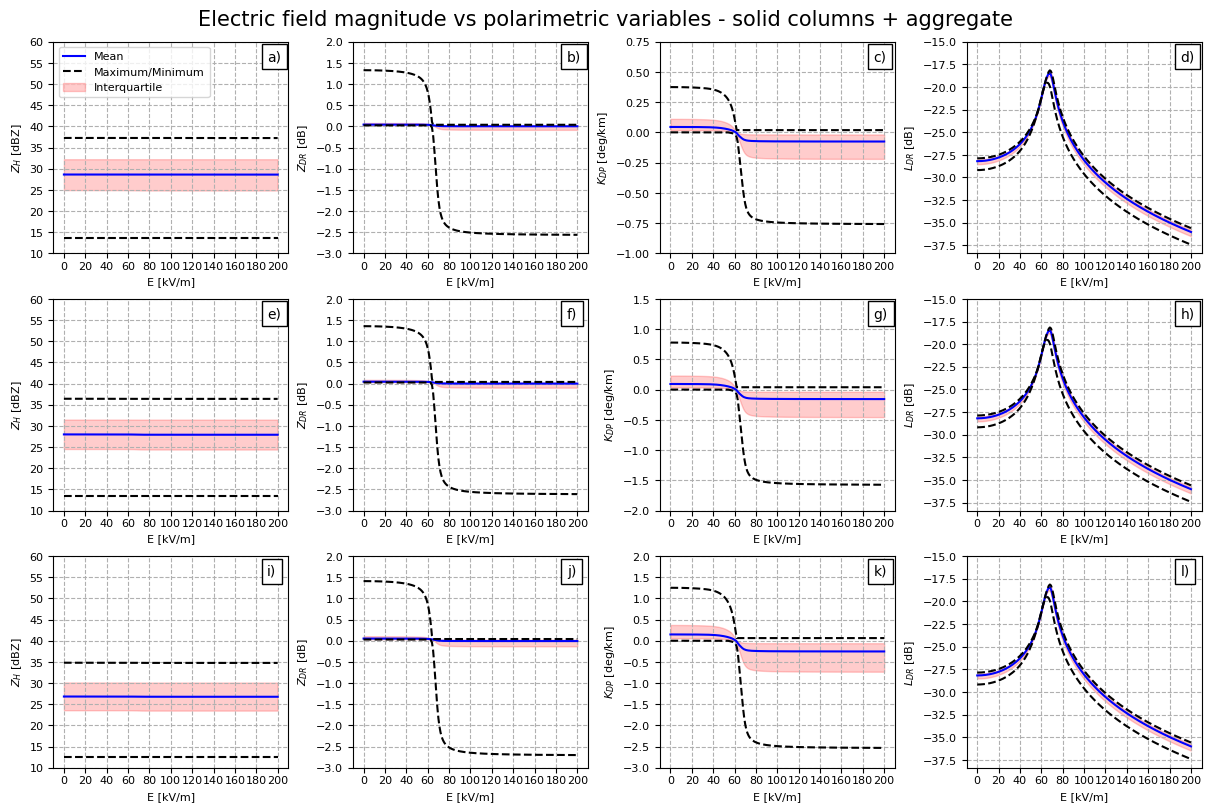

In [135]:
# plot the graupel/crystal mixtures
fig, axs = plt.subplots(3,4, figsize=[12,8], constrained_layout = True)

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, np.median(mix_columns_ZHS, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZHS, 1), c='k', ls = '--', label=r'Maximum/Minimum')
        ax.plot(E, np.max(mix_columns_ZHS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZHS, 25, 1), np.percentile(mix_columns_ZHS, 75, 1), alpha=0.2, color='red', label = r'Interquartile')
        ax.legend(loc = 'upper left', fontsize=8)
        
    if n == 1:
        ax.plot(E, np.median(mix_columns_ZDRS, 1), c='b')
        ax.plot(E, np.min(mix_columns_ZDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZDRS, 25, 1), np.percentile(mix_columns_ZDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 2:    
        ax.plot(E, np.median(mix_columns_KDPS, 1), c='b')
        ax.plot(E, np.min(mix_columns_KDPS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_KDPS, 25, 1), np.percentile(mix_columns_KDPS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-0.8, 0.4, 0.1))

    if n == 3:        
        ax.plot(E, np.median(mix_columns_LDRS, 1), c='b')
        ax.plot(E, np.min(mix_columns_LDRS, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRS, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_LDRS, 25, 1), np.percentile(mix_columns_LDRS, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 4:
        ax.plot(E, np.median(mix_columns_ZHC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZHC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZHC, 25, 1), np.percentile(mix_columns_ZHC, 75, 1), alpha=0.2, color='red')
        #ax.set_ylim(-20, 45)
        
    if n == 5:
        ax.plot(E, np.median(mix_columns_ZDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZDRC, 25, 1), np.percentile(mix_columns_ZDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 6:    
        ax.plot(E, np.median(mix_columns_KDPC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_KDPC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_KDPC, 25, 1), np.percentile(mix_columns_KDPC, 75, 1), alpha=0.2, color='red')

    if n == 7:        
        ax.plot(E, np.median(mix_columns_LDRC, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_LDRC, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRC, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_LDRC, 25, 1), np.percentile(mix_columns_LDRC, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))

    if n == 8:
        ax.plot(E, np.median(mix_columns_ZHX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZHX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZHX, 25, 1), np.percentile(mix_columns_ZHX, 75, 1), alpha=0.2, color='red')
        #ax.set_ylim(-20, 45)
        
    if n == 9:
        ax.plot(E, np.median(mix_columns_ZDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_ZDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_ZDRX, 25, 1), np.percentile(mix_columns_ZDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-5, 3, 1))
    
    if n == 10:    
        ax.plot(E, np.median(mix_columns_KDPX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_KDPX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_KDPX, 25, 1), np.percentile(mix_columns_KDPX, 75, 1), alpha=0.2, color='red')

    if n == 11:        
        ax.plot(E, np.median(mix_columns_LDRX, 1), c='b', label='Mean')
        ax.plot(E, np.min(mix_columns_LDRX, 1), c='k', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRX, 1), c='k', ls = '--')
        ax.fill_between(E, np.percentile(mix_columns_LDRX, 25, 1), np.percentile(mix_columns_LDRX, 75, 1), alpha=0.2, color='red')
        #ax.set_yticks(np.arange(-45, -10, 5))


l = ['a)', 'b)', 'c)', 'd)','e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
for n, ax in enumerate(axs.ravel()):
    ax.set_xlabel('E [kV/m]')
    ax.set_xticks(np.arange(0, 220, 20))
    ax.annotate(l[n], xy = (0.91, 0.91), xycoords = 'axes fraction', fontsize = 10, bbox={'facecolor':'white', 'clip_on':True}, zorder = 50)
    ax.grid(True, ls = '--', which = 'both')
    if (n == 0 or n == 4 or n == 8):
        ax.set_ylabel(r'$Z_{H}$ [dBZ]') 
        ax.set_yticks(np.arange(10, 65, 5))
    if (n == 1 or n == 5 or n == 9):
        ax.set_ylabel(r'$Z_{DR}$ [dB]')
        ax.set_yticks(np.arange(-3, 2.5, 0.5))
    if (n == 2 or n == 6 or n == 10):
        ax.set_ylabel(r'$K_{DP}$ [deg/km]')
        if n == 2:
            ax.set_yticks(np.arange(-1, 1, 0.25))
        elif n == 6:
            ax.set_yticks(np.arange(-2, 2, 0.5))
        else:
            ax.set_yticks(np.arange(-3, 2.5, 0.5))
    if (n == 3 or n == 7 or n == 11):
        ax.set_ylabel(r'$L_{DR}$ [dB]')
        ax.set_yticks(np.arange(-37.5, -12.5, 2.5))

fig.suptitle('Electric field magnitude vs polarimetric variables - solid columns + aggregate', fontsize = 15)
plt.savefig(f'results_graupel_columns.png', bbox_inches = 'tight', dpi=300)

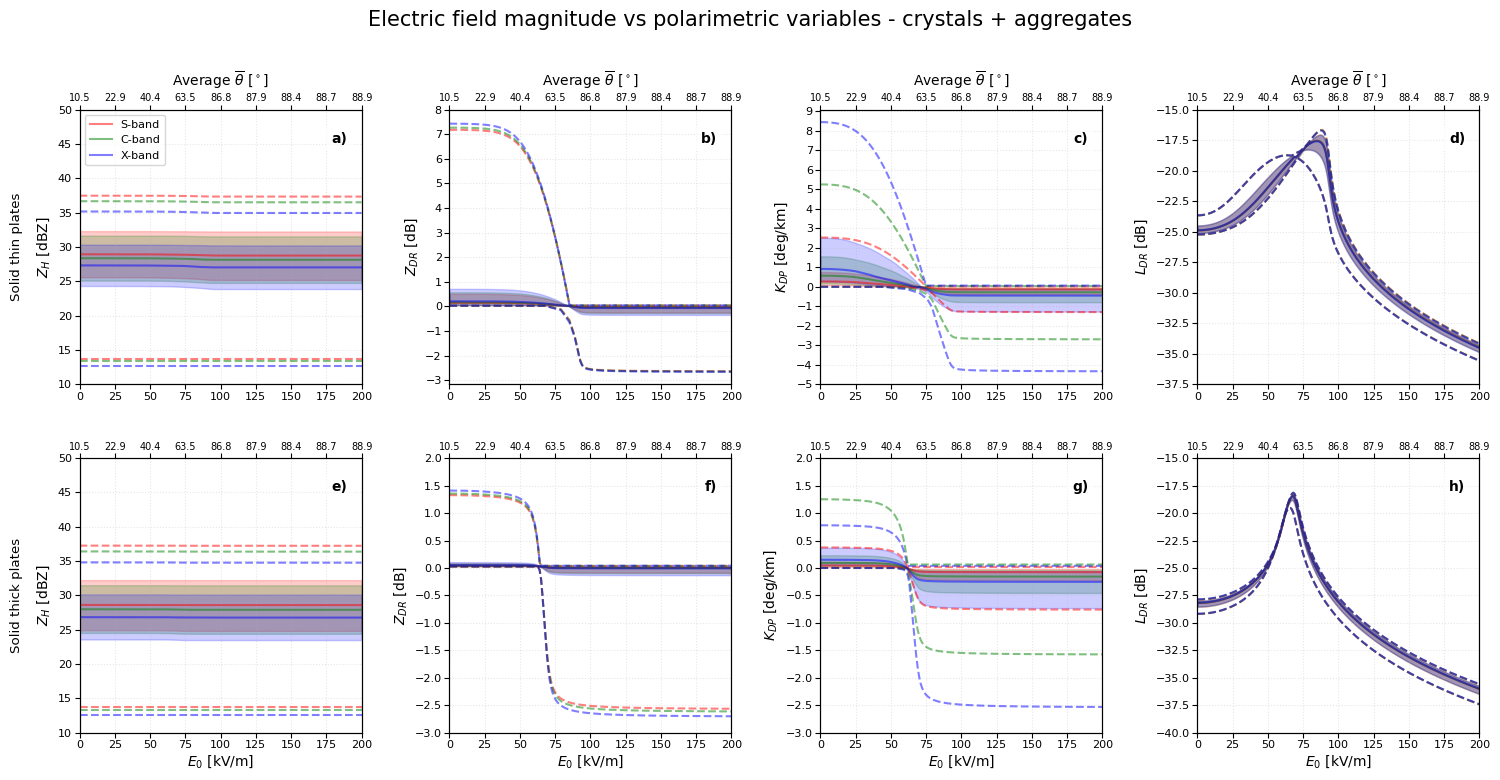

In [137]:
fig, axs = plt.subplots(2,4, figsize=[15,8], constrained_layout = True)

rows = [f'{row}' for row in ['Solid thin plates', 'Solid thick plates', 'Solid short columns', 'Solid long columns']]

for ax, row in zip(axs[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                xycoords=ax.yaxis.label, rotation=90, textcoords='offset points',
                size='large', ha='right', va='center')

for n,ax in enumerate(axs.ravel()):
    if n == 0:
        ax.plot(E, np.median(mix_plates_ZHS, 1), alpha=0.5, c='r', label = r'S-band')
        ax.plot(E, np.median(mix_plates_ZHC, 1), alpha=0.5, c='g', label = r'C-band')
        ax.plot(E, np.median(mix_plates_ZHX, 1), alpha=0.5, c='b', label = r'X-band')
        ax.fill_between(E, np.percentile(mix_plates_ZHS, 25, 1), np.percentile(mix_plates_ZHS, 75, 1), alpha=0.2, color='red')
        ax.fill_between(E, np.percentile(mix_plates_ZHC, 25, 1), np.percentile(mix_plates_ZHC, 75, 1), alpha=0.2, color='green')
        ax.fill_between(E, np.percentile(mix_plates_ZHX, 25, 1), np.percentile(mix_plates_ZHX, 75, 1), alpha=0.2, color='blue')
        ax.plot(E, np.min(mix_plates_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.legend(loc='upper left')
        ax.set_yticks(np.arange(10, 55, 5))
        
    if n == 1:
        ax.plot(E, np.median(mix_plates_ZDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_plates_ZDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_plates_ZDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_plates_ZDRS, 25, 1), np.percentile(mix_plates_ZDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_plates_ZDRC, 25, 1), np.percentile(mix_plates_ZDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_plates_ZDRX, 25, 1), np.percentile(mix_plates_ZDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_plates_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-3, 9, 1))
    
    if n == 2:    
        ax.plot(E, np.median(mix_plates_KDPS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_plates_KDPC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_plates_KDPX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_plates_KDPS, 25, 1), np.percentile(mix_plates_KDPS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_plates_KDPC, 25, 1), np.percentile(mix_plates_KDPC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_plates_KDPX, 25, 1), np.percentile(mix_plates_KDPX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_plates_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_KDPC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_KDPX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_KDPX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-5, 10, 1))

    if n == 3:        
        ax.plot(E, np.median(mix_plates_LDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_plates_LDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_plates_LDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_plates_LDRS, 25, 1), np.percentile(mix_plates_LDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_plates_LDRC, 25, 1), np.percentile(mix_plates_LDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_plates_LDRX, 25, 1), np.percentile(mix_plates_LDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_plates_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_plates_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_plates_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_plates_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-37.5, -12.5, 2.5))
        
    if n == 4:
        ax.plot(E, np.median(mix_columns_ZHS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_ZHC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_ZHX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_ZHS, 25, 1), np.percentile(mix_columns_ZHS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_ZHC, 25, 1), np.percentile(mix_columns_ZHC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_ZHX, 25, 1), np.percentile(mix_columns_ZHX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_columns_ZHX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(10, 55, 5))
        
    if n == 5:
        ax.plot(E, np.median(mix_columns_ZDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_ZDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_ZDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_ZDRS, 25, 1), np.percentile(mix_columns_ZDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_ZDRC, 25, 1), np.percentile(mix_columns_ZDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_ZDRX, 25, 1), np.percentile(mix_columns_ZDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_columns_ZDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-3, 2.5, 0.5))
    
    if n == 6:    
        ax.plot(E, np.median(mix_columns_KDPS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_KDPC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_KDPX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_KDPS, 25, 1), np.percentile(mix_columns_KDPS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_KDPC, 25, 1), np.percentile(mix_columns_KDPC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_KDPX, 25, 1), np.percentile(mix_columns_KDPX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_KDPC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_KDPX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPC, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_KDPX, 1), alpha=0.5, c='g', ls = '--')
        ax.set_yticks(np.arange(-3, 2.5, 0.5))
        
    if n == 7:        
        ax.plot(E, np.median(mix_columns_LDRS, 1), alpha=0.5, c='r')
        ax.plot(E, np.median(mix_columns_LDRC, 1), alpha=0.5, c='g')
        ax.plot(E, np.median(mix_columns_LDRX, 1), alpha=0.5, c='b')
        ax.fill_between(E, np.percentile(mix_columns_LDRS, 25, 1), np.percentile(mix_columns_LDRS, 75, 1), alpha=0.2, color='red', label = r'S-band')
        ax.fill_between(E, np.percentile(mix_columns_LDRC, 25, 1), np.percentile(mix_columns_LDRC, 75, 1), alpha=0.2, color='green', label = r'C-band')
        ax.fill_between(E, np.percentile(mix_columns_LDRX, 25, 1), np.percentile(mix_columns_LDRX, 75, 1), alpha=0.2, color='blue', label = r'X-band')
        ax.plot(E, np.min(mix_columns_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.min(mix_columns_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.min(mix_columns_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRS, 1), alpha=0.5, c='r', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRC, 1), alpha=0.5, c='g', ls = '--')
        ax.plot(E, np.max(mix_columns_LDRX, 1), alpha=0.5, c='b', ls = '--')
        ax.set_yticks(np.arange(-40, -12.5, 2.5))

l = ['a)', 'b)', 'c)', 'd)','e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
# Define primary ticks for alignment
primary_ticks = np.arange(0, 225, 25)

for n, ax in enumerate(axs.ravel()):
    row = n // 4
    col = n % 4
    
    # --- Primary Axis (Bottom) ---
    ax.set_xticks(primary_ticks)
    ax.set_xlim(0, 200)
    ax.tick_params(axis='both', labelsize=8, pad=2)
    ax.grid(True, ls=':', alpha=0.3)

    # SPACE SAVER: Only show the "E [kV/m]" label on the bottom row
    if row == 1:
        ax.set_xlabel(r'$E_0$ [kV/m]', fontsize=10, labelpad=2)
    else:
        ax.set_xlabel('')

    # --- Secondary Axis (Top) ---
    secax = ax.twiny()
    secax.set_xlim(ax.get_xlim())
    secax.set_xticks(primary_ticks)
    
    # Map and format labels to 1 decimal place
    sec_labels = [f"{forward(x):.1f}" for x in primary_ticks]
    secax.set_xticklabels(sec_labels, fontsize=7)
    secax.tick_params(axis='x', pad=1)

    # SPACE SAVER: Only show "Mean [mm]" on the very top row
    if row == 0:
        secax.set_xlabel(r'Average $\overline{\theta}$ $[^\circ]$', fontsize=10, labelpad=5)
    else:
        secax.set_xlabel('')

    # --- Annotation 'a)', 'b)' ---
    # Placed in the top-right corner of each subplot
    ax.annotate(l[n], xy=(0.95, 0.88), xycoords='axes fraction', 
                ha='right', fontsize=10, weight='bold',
                bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':0.6})

    # --- Y-Axis Formatting (Only on the left column) ---
    if col == 0:
        # Define Y-labels based on the row/index
        if row == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
        elif row == 1: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10) # or whatever variable is in row 2
        elif row == 2: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    
    # Use your original column-based logic for specific radar variables:
    if col == 0: ax.set_ylabel(r'$Z_{H}$ [dBZ]', fontsize=10)
    elif col == 1: ax.set_ylabel(r'$Z_{DR}$ [dB]', fontsize=10)
    elif col == 2: ax.set_ylabel(r'$K_{DP}$ [deg/km]', fontsize=10)
    elif col == 3: ax.set_ylabel(r'$L_{DR}$ [dB]', fontsize=10)

# Adjust spacing so labels don't hit the titles/labels of other plots
plt.rcParams['xtick.major.pad'] = 2

# Set the padding (h_pad is height padding in inches)
fig.set_constrained_layout_pads(h_pad=0.2, w_pad=0.1, hspace=0.05, wspace=0.05)

fig.suptitle('Electric field magnitude vs polarimetric variables - crystals + aggregates', fontsize = 15)

plt.savefig(f'results_crystal_aggregate.png', bbox_inches = 'tight', dpi=300)
#plt.savefig(f'results_crystal_graupel_radarconf.png', bbox_inches = 'tight', dpi=300)

In [39]:
for h in np.arange(4000, 16000, 1000):
    with open(f'sim_full_plate_{h}_S.pkl',mode='rb') as f:
        data_plateS = pickle.load(f)[0]
    
    for var in data_plateS.keys():
        data_plateS[var] = data_plateS[var].astype(np.float32)
    
    with open(f'sim_full_column_{h}_S.pkl',mode='rb') as f:
        data_colS = pickle.load(f)[0]
    
    for var in data_colS.keys():
        data_colS[var] = data_colS[var].astype(np.float32)
    
    with open('sim_full_snow_S.pkl',mode='rb') as f:
        data_snowS = pickle.load(f)[0]
    
    for var in data_snowS.keys():
        data_snowS[var] = data_snowS[var].astype(np.float32)
    
    with open('sim_full_graupel_S.pkl',mode='rb') as f:
        data_graupelS = pickle.load(f)[0]
    
    for var in data_graupelS.keys():
        data_graupelS[var] = data_graupelS[var].astype(np.float32)
    
    graupelS = to_linear(data_graupelS)
    snowS = to_linear(data_snowS)
    thinS = to_linear(data_plateS)
    shortS = to_linear(data_colS)
    
    snow_plates_S = mix_hydrometeors(thinS, snowS)
    snow_columns_S = mix_hydrometeors(shortS, snowS)
    graupel_plates_S = mix_hydrometeors(thinS, graupelS)
    graupel_columns_S = mix_hydrometeors(shortS, graupelS)
    
    shapes = (E.shape[0], snow_plates_S["ZH"].ravel().shape[0]//201)
    
    snow_plates_ZHS = snow_plates_S["ZH"].ravel().reshape(shapes)
    snow_plates_ZDRS = snow_plates_S["ZDR"].ravel().reshape(shapes)
    snow_plates_KDPS = snow_plates_S["KDP"].ravel().reshape(shapes)
    snow_plates_LDRS = snow_plates_S["LDR"].ravel().reshape(shapes)
    
    snow_columns_ZHS = snow_columns_S["ZH"].ravel().reshape(shapes)
    snow_columns_ZDRS = snow_columns_S["ZDR"].ravel().reshape(shapes)
    snow_columns_KDPS = snow_columns_S["KDP"].ravel().reshape(shapes)
    snow_columns_LDRS = snow_columns_S["LDR"].ravel().reshape(shapes)
    
    shapes = (E.shape[0], graupel_plates_S["ZH"].ravel().shape[0]//201)
    
    graupel_plates_ZHS = graupel_plates_S["ZH"].ravel().reshape(shapes)
    graupel_plates_ZDRS = graupel_plates_S["ZDR"].ravel().reshape(shapes)
    graupel_plates_KDPS = graupel_plates_S["KDP"].ravel().reshape(shapes)
    graupel_plates_LDRS = graupel_plates_S["LDR"].ravel().reshape(shapes)
    
    graupel_columns_ZHS = graupel_columns_S["ZH"].ravel().reshape(shapes)
    graupel_columns_ZDRS = graupel_columns_S["ZDR"].ravel().reshape(shapes)
    graupel_columns_KDPS = graupel_columns_S["KDP"].ravel().reshape(shapes)
    graupel_columns_LDRS = graupel_columns_S["LDR"].ravel().reshape(shapes)
    
    #save the output as a pickle file
    myvar = [{'zh': snow_plates_ZHS, 'zdr': snow_plates_ZDRS, 'kdp': snow_plates_KDPS, 'ldr': snow_plates_LDRS}] 
    
    #Open a file and use dump() 
    with open(f'sim_mix_plates_snow_{h}_S.pkl', 'wb') as file: 
          
        # A new file will be created 
        pickle.dump(myvar, file) 
    
    #save the output as a pickle file
    myvar = [{'zh': snow_columns_ZHS, 'zdr': snow_columns_ZDRS, 'kdp': snow_columns_KDPS, 'ldr': snow_columns_LDRS}] 
    
    #Open a file and use dump() 
    with open(f'sim_mix_columns_snow_{h}_S.pkl', 'wb') as file: 
          
        # A new file will be created 
        pickle.dump(myvar, file) 
    
    #save the output as a pickle file
    myvar = [{'zh': graupel_columns_ZHS, 'zdr': graupel_columns_ZDRS, 'kdp': graupel_columns_KDPS, 'ldr': graupel_columns_LDRS}] 
    
    #Open a file and use dump() 
    with open(f'sim_mix_columns_graupel_{h}_S.pkl', 'wb') as file: 
          
        # A new file will be created 
        pickle.dump(myvar, file) 
    
    #save the output as a pickle file
    myvar = [{'zh': graupel_plates_ZHS, 'zdr': graupel_plates_ZDRS, 'kdp': graupel_plates_KDPS, 'ldr': graupel_plates_LDRS}] 
    
    #Open a file and use dump() 
    with open(f'sim_mix_plates_graupel_{h}_S.pkl', 'wb') as file: 
          
        # A new file will be created 
        pickle.dump(myvar, file) 

In [62]:
######## Radar analysis ###############

def calculate_dynamic_membership_params_vectorized(Z_array: np.ndarray):
    """
    Calculates dynamic parameters for membership functions based on an array of Z values.
    """
    f1 = -0.5 + 2.5e-3 * Z_array + 7.5e-4 * Z_array**2
    f2 = 0.68 - 4.81e-2 * Z_array + 2.92e-3 * Z_array**2
    f3 = 1.42 + 6.67e-2 * Z_array + 4.85e-4 * Z_array**2

    g_1 = -44.0 + 0.8 * Z_array
    g_2 = -22.0 + 0.5 * Z_array
    return f1, f2, f3, g_1, g_2

def trapezoidal_membership_vectorized(values: np.ndarray, bounds: np.ndarray) -> np.ndarray:
    """
    Compute trapezoidal membership function for an array of values using vectorized operations.

    Parameters:
    - values: A 2D numpy array of input values (e.g., a radar field for one sweep).
    - bounds: A 4xN numpy array where N is the number of classes.
              Each column represents [a, b, c, d] for a trapezoidal function.
              This array must have a float dtype.

    Returns:
    - P: A 3D numpy array of shape (rows, cols, num_classes) of membership values.
    """
    rows, cols = values.shape
    num_classes = bounds.shape[1]

    a = bounds[0, np.newaxis, np.newaxis, :]
    b = bounds[1, np.newaxis, np.newaxis, :]
    c = bounds[2, np.newaxis, np.newaxis, :]
    d = bounds[3, np.newaxis, np.newaxis, :]

    values_reshaped = values[:, :, np.newaxis]

    P = np.zeros((rows, cols, num_classes), dtype=float)

    mask_rising = (values_reshaped >= a) & (values_reshaped < b)
    val_minus_a = values_reshaped - a
    b_minus_a = b - a
    result_rising_slope = np.zeros((rows, cols, num_classes), dtype=float)
    np.divide(val_minus_a, b_minus_a, out=result_rising_slope, where=(b_minus_a != 0))
    P[mask_rising] = result_rising_slope[mask_rising]

    mask_plateau = (values_reshaped >= b) & (values_reshaped < c)
    P[mask_plateau] = 1.0

    mask_falling = (values_reshaped >= c) & (values_reshaped < d)
    d_minus_val = d - values_reshaped
    d_minus_c = d - c
    result_falling_slope = np.zeros((rows, cols, num_classes), dtype=float)
    np.divide(d_minus_val, d_minus_c, out=result_falling_slope, where=(d_minus_c != 0))
    P[mask_falling] = result_falling_slope[mask_falling]

    return P

def trapezoidal_membership_vectorized_dynamic_bounds(values: np.ndarray, bounds_per_pixel: np.ndarray) -> np.ndarray:
    """
    Compute trapezoidal membership function for an array of values where bounds also vary per pixel.

    Parameters:
    - values: A 2D numpy array of input values (rows, cols).
    - bounds_per_pixel: A 4D numpy array of shape (rows, cols, 4, num_classes).

    Returns:
    - P: A 3D numpy array of shape (rows, cols, num_classes) of membership values.
    """
    rows, cols = values.shape
    num_classes = bounds_per_pixel.shape[3]

    a = bounds_per_pixel[:, :, 0, :]  
    b = bounds_per_pixel[:, :, 1, :]  
    c = bounds_per_pixel[:, :, 2, :]  
    d = bounds_per_pixel[:, :, 3, :]  

    values_reshaped = values[:, :, np.newaxis]

    P = np.zeros((rows, cols, num_classes), dtype=float)

    mask_rising = (values_reshaped >= a) & (values_reshaped < b)
    val_minus_a = values_reshaped - a
    b_minus_a = b - a
    result_rising_slope = np.zeros((rows, cols, num_classes), dtype=float)
    np.divide(val_minus_a, b_minus_a, out=result_rising_slope, where=(b_minus_a != 0))
    P[mask_rising] = result_rising_slope[mask_rising]

    mask_plateau = (values_reshaped >= b) & (values_reshaped < c)
    P[mask_plateau] = 1.0

    mask_falling = (values_reshaped >= c) & (values_reshaped < d)
    d_minus_val = d - values_reshaped
    d_minus_c = d - c
    result_falling_slope = np.zeros((rows, cols, num_classes), dtype=float)
    np.divide(d_minus_val, d_minus_c, out=result_falling_slope, where=(d_minus_c != 0))
    P[mask_falling] = result_falling_slope[mask_falling]

    return P


def classification_pixel_vectorized(Z: np.ndarray, ZDR: np.ndarray, RhoHV: np.ndarray, LKDP: np.ndarray,
                                   SDZ: np.ndarray, SDP: np.ndarray, A_static: dict,
                                   hgt_field: np.ndarray, Hb: float, Ht: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Classificate each range gate using the fuzzy logic

    Parameters:
    - Z: A 2D numpy array of the horizontal reflectivity factor.
    - ZDR: A 2D numpy array of the differential reflectivity.
    - RhoHV: A 2D numpy array of the cross correlation coefficient.
    - LKDP: A 2D numpy array of the logarithm of specific differential phase.
    - SDZ: A 2D numpy array of the texture of the horizontal reflectivity factor.
    - SDP: A 2D numpy array of the texture of the differential phase.
    - A_static: Load the static membership functions.
    - hgt_field: A 2D numpy array of the range gate heights.
    - Hb: Base of the melting layer in km.
    - Ht: top of the melting layer in km.

    Returns:
    - class_matrix: A list containing the clasification index of all range gates
    - text_labels: A list contained the labels of all range gates.
    """
    
    no_echo_mask = np.isnan(Z)

    XZ, Xrho, Xsdz, Xsdp = A_static['XZ'], A_static['Xrho'], A_static['Xsdz'], A_static['Xsdp']
    WZ, WZdr, Wrho, Wlkdp, Wsdz, Wsdp = (A_static[key][np.newaxis, np.newaxis, :] for key in ['WZ', 'WZdr', 'Wrho', 'Wlkdp', 'Wsdz', 'Wsdp'])

    f1_arr, f2_arr, f3_arr, g_1_arr, g_2_arr = calculate_dynamic_membership_params_vectorized(Z)

    rows, cols = Z.shape
    num_classes = XZ.shape[1]

    XZdr_pixel = np.zeros((rows, cols, 4, num_classes), dtype=float)
    Xlkdp_pixel = np.zeros((rows, cols, 4, num_classes), dtype=float)

    XZdr_pixel[:,:,0,:] = np.array([-4.0, 0.0, -0.3, 0.5, 0.1, -0.3, -0.3, -0.3, -0.3, -0.3])[np.newaxis, np.newaxis, :]
    XZdr_pixel[:,:,1,:] = np.array([-2.0, 2.0, 0.0, 1.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0])[np.newaxis, np.newaxis, :]
    XZdr_pixel[:,:,2,:] = np.array([1.0, 10.0, 0.3, 2.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0])[np.newaxis, np.newaxis, :]
    XZdr_pixel[:,:,3,:] = np.array([2.0, 12.0, 0.6, 3.0, 3.3, 0.0, 0.0, 0.0, 0.0, 0.0])[np.newaxis, np.newaxis, :]

    XZdr_pixel[:,:,0,5] = -0.3
    XZdr_pixel[:,:,0,6] = f2_arr - 0.3
    XZdr_pixel[:,:,0,7] = f1_arr - 0.3
    XZdr_pixel[:,:,0,8] = f1_arr - 0.3
    XZdr_pixel[:,:,0,9] = -0.3

    XZdr_pixel[:,:,1,5] = 0.0
    XZdr_pixel[:,:,1,6] = f2_arr
    XZdr_pixel[:,:,1,7] = f1_arr
    XZdr_pixel[:,:,1,8] = f1_arr
    XZdr_pixel[:,:,1,9] = 0.0

    XZdr_pixel[:,:,2,5] = f1_arr
    XZdr_pixel[:,:,2,6] = f3_arr
    XZdr_pixel[:,:,2,7] = f2_arr
    XZdr_pixel[:,:,2,8] = f2_arr
    XZdr_pixel[:,:,2,9] = f1_arr

    XZdr_pixel[:,:,3,5] = f1_arr + 0.3
    XZdr_pixel[:,:,3,6] = f3_arr + 1.0
    XZdr_pixel[:,:,3,7] = f2_arr + 0.5
    XZdr_pixel[:,:,3,8] = f2_arr + 0.5
    XZdr_pixel[:,:,3,9] = f1_arr + 0.5

    Xlkdp_pixel[:,:,0,:] = np.array([-30.0, -30.0, -30.0, -30.0, -5.0, -30.0, -1.0, -1.0, -1.0, -10.0])[np.newaxis, np.newaxis, :]
    Xlkdp_pixel[:,:,1,:] = np.array([-25.0, -25.0, -25.0, -25.0, 0.0, -25.0, 0.0, 0.0, 0.0, -4.0])[np.newaxis, np.newaxis, :]
    Xlkdp_pixel[:,:,2,:] = np.array([10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 0.0, 0.0, 0.0, 0.0])[np.newaxis, np.newaxis, :]
    Xlkdp_pixel[:,:,3,:] = np.array([20.0, 10.0, 20.0, 20.0, 15.0, 20.0, 1.0, 1.0, 1.0, 1.0])[np.newaxis, np.newaxis, :]

    Xlkdp_pixel[:,:,0,6] = g_1_arr - 1.0
    Xlkdp_pixel[:,:,0,7] = g_1_arr - 1.0
    Xlkdp_pixel[:,:,0,8] = g_1_arr - 1.0

    Xlkdp_pixel[:,:,1,6] = g_1_arr
    Xlkdp_pixel[:,:,1,7] = g_1_arr
    Xlkdp_pixel[:,:,1,8] = g_1_arr

    Xlkdp_pixel[:,:,2,6] = g_2_arr
    Xlkdp_pixel[:,:,2,7] = g_2_arr
    Xlkdp_pixel[:,:,2,8] = g_2_arr
    Xlkdp_pixel[:,:,2,9] = g_1_arr

    Xlkdp_pixel[:,:,3,6] = g_2_arr + 1.0
    Xlkdp_pixel[:,:,3,7] = g_2_arr + 1.0
    Xlkdp_pixel[:,:,3,8] = g_2_arr + 1.0
    Xlkdp_pixel[:,:,3,9] = g_2_arr + 1.0

    PZ = trapezoidal_membership_vectorized(Z, XZ)
    PZdr = trapezoidal_membership_vectorized_dynamic_bounds(ZDR, XZdr_pixel)
    Prho = trapezoidal_membership_vectorized(RhoHV, Xrho)
    Plkdp = trapezoidal_membership_vectorized_dynamic_bounds(LKDP, Xlkdp_pixel)
    Psdz = trapezoidal_membership_vectorized(SDZ, Xsdz)
    Psdp = trapezoidal_membership_vectorized(SDP, Xsdp)

    sum_weights_scalar = np.sum(A_static['WZ'] + A_static['WZdr'] + A_static['Wrho'] + A_static['Wlkdp'] + A_static['Wsdz'] + A_static['Wsdp'])
    Ai = (PZ * WZ + PZdr * WZdr + Prho * Wrho + Plkdp * Wlkdp + Psdz * Wsdz + Psdp * Wsdp) / sum_weights_scalar

    hgt_below_Hb_mask = (hgt_field < Hb) & (Hb > 0)
    hgt_above_Ht_mask = (hgt_field > Ht) & (Ht > 0)
    
    for class_idx in [2, 3, 4, 5]:
        Ai[hgt_below_Hb_mask, class_idx] = 0
    for class_idx in [0, 1, 3, 6, 7, 8]:
        Ai[hgt_above_Ht_mask, class_idx] = 0

    class_id_initial = np.argmax(Ai, axis=2) + 1

    no_classification_by_Ai_mask = (np.max(Ai, axis=2) <= 0)
    final_no_classification_mask = no_echo_mask | no_classification_by_Ai_mask
    class_id_initial[final_no_classification_mask] = 0

    needs_reclassify_mask = (
        ((class_id_initial == 3) & (ZDR > 2)) |
        ((class_id_initial == 4) & ((Z < 20) | (ZDR < 0))) |
        ((class_id_initial == 5) & (Z > 40)) |
        ((class_id_initial == 6) & ((Z < 10) | (Z > 60))) |
        ((class_id_initial == 7) & (ZDR < f2_arr - 0.3)) |
        ((class_id_initial == 8) & (Z > 50)) |
        ((class_id_initial == 9) & (Z < 30)) |
        ((class_id_initial == 10) & (Z < 30)))

    if np.any(needs_reclassify_mask):
        rows_reclassify, cols_reclassify = np.where(needs_reclassify_mask)
        prev_class_indices_reclassify = class_id_initial[needs_reclassify_mask] - 1
        Ai[rows_reclassify, cols_reclassify, prev_class_indices_reclassify] = -np.inf

        new_class_ids_for_reclassified = np.argmax(Ai[needs_reclassify_mask], axis=1) + 1
        class_id_initial[needs_reclassify_mask] = new_class_ids_for_reclassified

        no_classification_after_reclassify = (np.max(Ai[needs_reclassify_mask], axis=1) <= 0)
        class_id_initial[needs_reclassify_mask][no_classification_after_reclassify] = 0

    class_matrix = class_id_initial
    TP = ['GC', 'BS', 'DS', 'WS', 'CR', 'GR', 'BD', 'RA', 'HR', 'RH']

    text_labels = np.full(class_matrix.shape, 'NE', dtype=object)

    for i in range(len(TP)):
        text_labels[class_matrix == (i + 1)] = TP[i]

    return class_matrix, text_labels

def define_static_membership_functions():
    """
    Define static membership functions and weights for the radar echo classification.
    These do not depend on Z.
    """
    A_static = dict()

    A_static['XZ'] = np.array([[15, 5, 5, 25, 0, 25, 20, 5, 40, 45],
                               [20, 10, 10, 30, 5, 35, 25, 10, 45, 50],
                               [70, 20, 35, 40, 20, 50, 45, 45, 55, 75],
                               [80, 30, 40, 50, 25, 55, 50, 50, 60, 80]], dtype=float)

    A_static['Xrho']=np.asarray([[0.5, 0.3, 0.95, 0.88, 0.95, 0.9, 0.92, 0.95, 0.92, 0.85],
                                 [0.6, 0.5, 0.98, 0.92, 0.98, 0.97, 0.95, 0.97, 0.95, 0.9],
                                 [0.9, 0.8, 1.0, 0.95, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
                                 [0.95, 0.83, 1.01, 0.985, 1.01, 1.01, 1.01, 1.01, 1.01, 1.01]], dtype=float)

    A_static['Xsdz']=np.asarray([[2, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                                 [4, 2, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
                                 [10, 4, 3, 3, 3, 3, 3, 3, 3, 3],
                                 [15, 7, 6, 6, 6, 6, 6, 6, 6, 6]], dtype=float)

    A_static['Xsdp']=np.asarray([[30, 8, 0, 0, 0, 0, 0, 0, 0, 0],
                                 [40, 10, 1, 1, 1, 1, 1, 1, 1, 1],
                                 [50, 40, 15, 15, 15, 15, 15, 15, 15, 15],
                                 [60, 60, 30, 30, 30, 30, 30, 30, 30, 30]], dtype=float)

    A_static['WZ'] = np.asarray([0.2, 0.4, 1.0, 0.6, 1.0, 0.8, 0.8, 1.0, 1.0, 1.0], dtype=float)
    A_static['WZdr'] = np.asarray([0.4, 0.6, 0.8, 0.8, 0.6, 1.0, 1.0, 0.8, 0.8, 0.8], dtype=float)
    A_static['Wrho'] = np.asarray([1.0, 1.0, 0.6, 1.0, 0.4, 0.4, 0.6, 0.6, 0.6, 0.6], dtype=float)
    A_static['Wlkdp'] = np.asarray([0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 1.0, 1.0], dtype=float)
    A_static['Wsdz'] = np.asarray([0.6, 0.8, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2], dtype=float)
    A_static['Wsdp'] = np.asarray([0.8, 0.8, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2], dtype=float)

    return A_static

def range_ml(Hbt, elevation_angle_deg, radar_altitude=0, Re=6.371e3, k=4/3, bw = 1.3):
    """
    Convert height above radar to slant range considering Earth's curvature.
    Currently, it only returns the provided melting layer heights.

    Parameters:
    - Hbt: tuple or list (Hb, Ht) - bottom and top melting layer heights (m)
    - elevation_angle_deg: radar elevation angle (degrees) (currently unused)
    - radar_altitude: radar height above sea level (m) (currently unused)
    - Re: Earth's radius (m), default 6371 km (currently unused)
    - k: effective Earth radius factor, default 4/3 (currently unused)
    - bw: beamwidth (degrees) (currently unused)

    Returns:
    - np.array: A numpy array containing [Hb, Ht].
    """
    Hb, Ht = Hbt
    if Hbt[0] > 0:
        return np.array([Hb, Ht], dtype=float) 
    else:
        return np.array([-99.0, -99.0], dtype=float)

def radar_echo_class_3input_parallel(radar, Hbt=None, resolution=38, n_jobs=-1):
    """
    Parallelized version of radar_echo_class_3input with a progress bar,
    optimized for speed through vectorization.

    Parameters:
    - radar : radar object
    - Hbt : list of float, melting layer heights (Hb, Ht) in km
    - resolution : float, range resolution (currently unused as hgt is derived from radar object)
    - n_jobs : int, number of parallel jobs (-1 = all CPUs)
    """
    if Hbt is None:
        Hbt = [-99.0, -99.0]

    A_static = define_static_membership_functions()
    Hb, Ht = range_ml(Hbt, radar.fixed_angle['data'][0] if radar.fixed_angle['data'].size > 0 else 0)

    def process_sweep(n, el_deg):

        Z = radar.get_field(n, 'reflectivity').astype(np.float32)
        ZDR = radar.get_field(n, 'differential_reflectivity').astype(np.float32)
        KDP = radar.get_field(n, 'specific_differential_phase').astype(np.float32)
        RhoHV = radar.get_field(n, 'cross_correlation_ratio').astype(np.float32)
        SDZ = radar.get_field(n, 'SDZ').astype(np.float32)
        SDP = radar.get_field(n, 'SDP').astype(np.float32)

        _,_,hgt_field = radar.get_gate_x_y_z(n)
        hgt_field = hgt_field.astype(np.float32) / 1000

        LKDP = np.full(KDP.shape, -30.0, dtype=np.float32)
        valid_kdp_mask = KDP >= 1e-3
        LKDP[valid_kdp_mask] = 10 * np.log10(KDP[valid_kdp_mask])

        class_matrix, text_labels = classification_pixel_vectorized(Z, ZDR, RhoHV, LKDP, SDZ, SDP, A_static, hgt_field, Hb, Ht)

        return class_matrix, text_labels

    num_sweeps = len(radar.fixed_angle['data'])
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_sweep)(n, el_deg)
        for n, el_deg in tqdm(enumerate(radar.fixed_angle['data']), total=num_sweeps, desc="Processing Radar Sweeps")
    )

    HID, label = zip(*results)

    return list(HID), list(label)

In [88]:
files = sorted(glob.glob('/mnt/d/20240427/Scan_6/MATLAB/HRUS_240428_012359000_100.mat'))

20240428_012359


(<Figure size 1200x800 with 12 Axes>,
 array([[<Axes: xlabel='East West distance from radar (km)', ylabel='North South distance from radar (km)'>,
         <Axes: xlabel='East West distance from radar (km)', ylabel='North South distance from radar (km)'>,
         <Axes: xlabel='East West distance from radar (km)', ylabel='North South distance from radar (km)'>],
        [<Axes: xlabel='East West distance from radar (km)', ylabel='North South distance from radar (km)'>,
         <Axes: xlabel='East West distance from radar (km)', ylabel='North South distance from radar (km)'>,
         <Axes: xlabel='East West distance from radar (km)', ylabel='North South distance from radar (km)'>]],
       dtype=object))

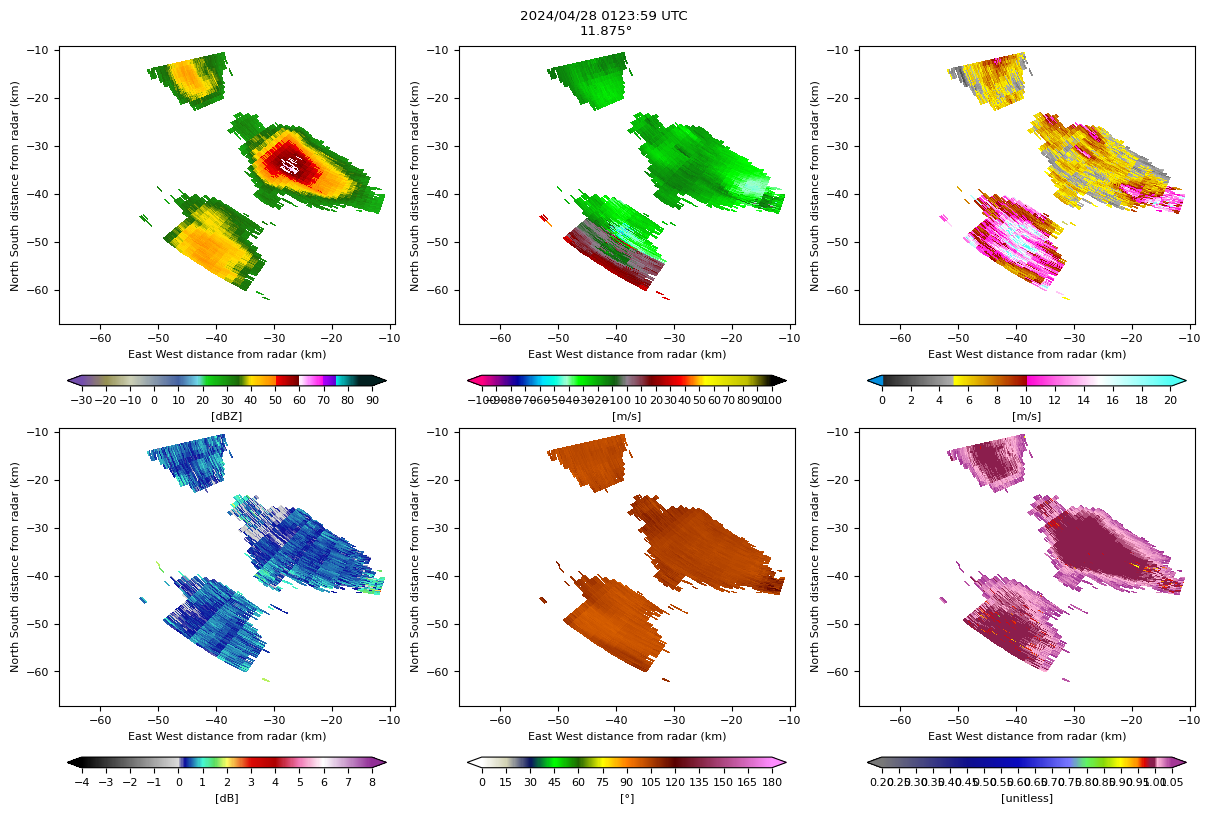

In [89]:
#quick ppi plot
sweep = 9

radar = mat_to_pyart(files[0])

radar.range['data'] = radar.range['data'] - 8740
radar.fields['specific_differential_phase']['units'] = 'deg/km'

quick_ppi(radar, matfile=True, s = sweep)


In [90]:
# Do the hydrometeor classification
HCA = radar_echo_class_3input_parallel(radar, [2.7, 3.3], n_jobs=-1)

hca_id = np.array(HCA[0]).reshape(16*48, 1822)
hca_label = np.array(HCA[1]).reshape(16*48, 1822)

Processing Radar Sweeps:   0%|          | 0/16 [00:00<?, ?it/s]

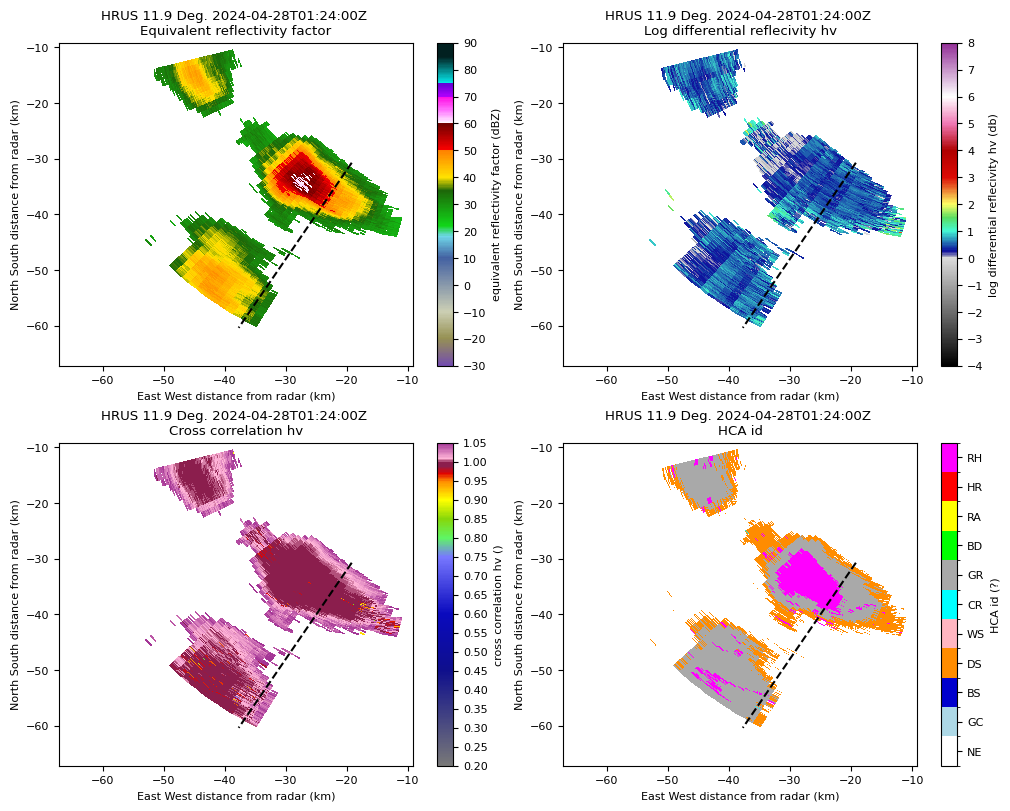

In [91]:
# Define the colormap boundaries for the HCA
TP=['NE','GC','BS','DS','WS','CR','GR','BD','RA','HR','RH']
ticks = np.arange(len(TP))
hid_colors = ['White', 'LightBlue', 'MediumBlue', 'DarkOrange', 'LightPink',
              'Cyan','DarkGray', 'Lime', 'Yellow', 'Red', 'Fuchsia']
cmaphid = mplcolors.ListedColormap(hid_colors)
boundaries = np.arange(-0.5, len(TP))
norm = mplcolors.BoundaryNorm(boundaries, 11)

# Add the HCA results
radar.add_field('HCA_id', dic={'data':hca_id}, replace_existing=True)
radar.add_field('HCA_label', dic={'data':hca_label}, replace_existing=True)

# Check the HCA output
fig, axs = plt.subplots(2, 2, figsize=[10, 8], constrained_layout = True)

# This is the azimuth that transects the flash initiation
theta = 212
x = radar.range['data']*np.sin(np.deg2rad(theta))/1e3
y = radar.range['data']*np.cos(np.deg2rad(theta))/1e3

for ax in axs.ravel():
    ax.plot(x,y, 'k--')
    #ax.set_xlim(-75, -25)
    #ax.set_ylim(-75, -25)

display = pyart.graph.RadarDisplay(radar)
display.plot_ppi('reflectivity', sweep, cmap=ref_cmap, norm=ref_norm, ticks=ZH_Ticks, ax=axs.ravel()[0], colorbar_orient='vertical')
display.plot_ppi('differential_reflectivity', sweep, cmap=zdr_cmap, norm=zdr_norm, ticks=ZDR_Ticks, ax=axs.ravel()[1], colorbar_orient='vertical')
display.plot_ppi('cross_correlation_ratio', sweep, cmap=rho_cmap, norm=rho_norm, ticks=RHO_Ticks, ax=axs.ravel()[2], colorbar_orient='vertical')
display.plot_ppi('HCA_id', sweep, cmap=cmaphid, norm=norm, ticks=ticks, ticklabs=TP, ax=axs.ravel()[3], colorbar_orient='vertical')

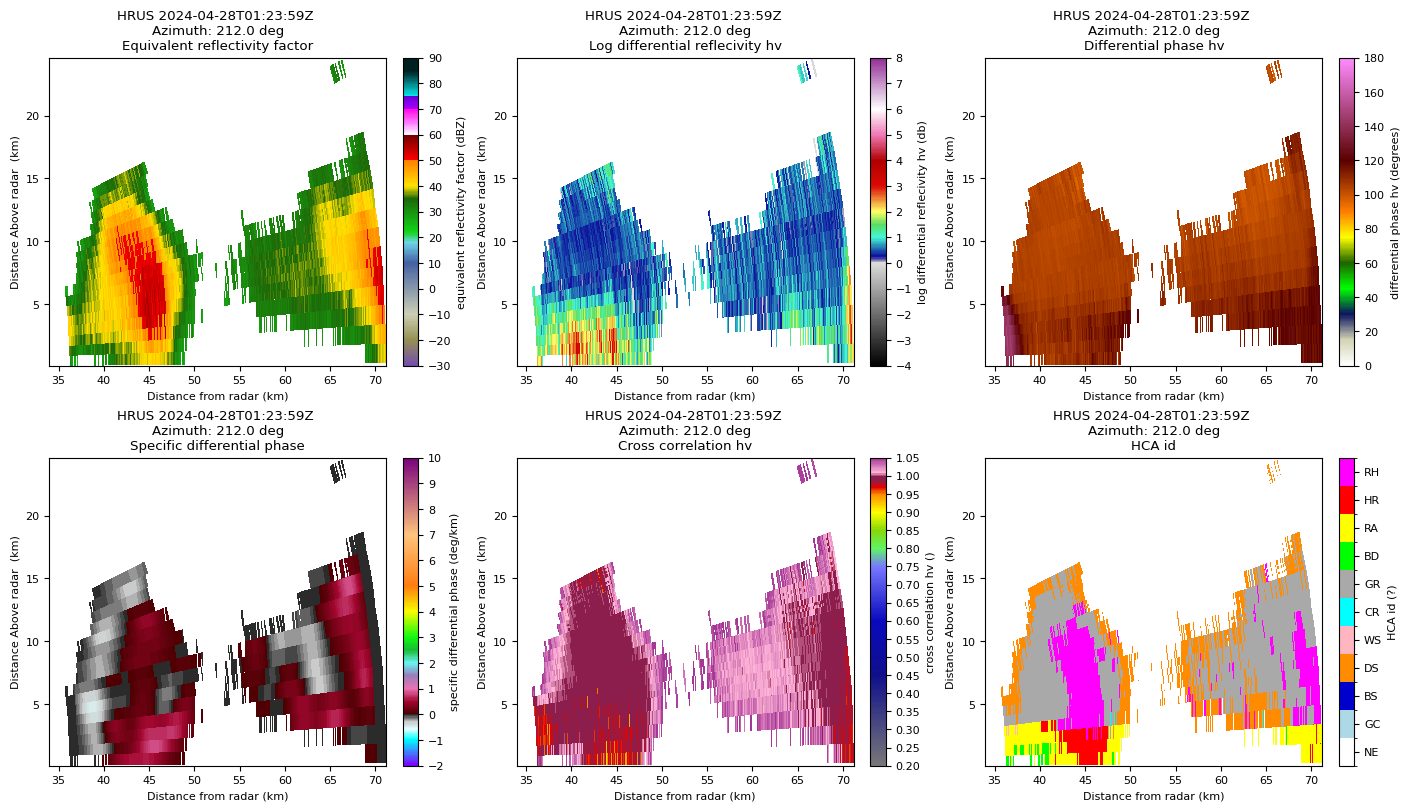

In [92]:
# Check the HCA output
fig, axs = plt.subplots(2, 3, figsize=[14, 8], constrained_layout = True)

azi = theta

display = pyart.graph.RadarDisplay(radar)
display.plot_azimuth_to_rhi('reflectivity', azi, cmap=ref_cmap, norm=ref_norm, ticks=ZH_Ticks, ax=axs.ravel()[0], colorbar_orient='vertical')
display.plot_azimuth_to_rhi('differential_reflectivity', azi, cmap=zdr_cmap, norm=zdr_norm, ticks=ZDR_Ticks, ax=axs.ravel()[1], colorbar_orient='vertical')
display.plot_azimuth_to_rhi('differential_phase', azi, cmap=phi_cmap, vmin=0, vmax=180, ax=axs.ravel()[2], colorbar_orient='vertical')
display.plot_azimuth_to_rhi('specific_differential_phase', azi, cmap=kdp_cmap, norm=kdp_norm, ticks=KDP_Ticks, ax=axs.ravel()[3], colorbar_orient='vertical')
display.plot_azimuth_to_rhi('cross_correlation_ratio', azi, cmap=rho_cmap, norm=rho_norm, ticks=RHO_Ticks, ax=axs.ravel()[4], colorbar_orient='vertical')
display.plot_azimuth_to_rhi('HCA_id', azi, cmap=cmaphid, norm=norm, ticks=ticks, ticklabs=TP, ax=axs.ravel()[5], colorbar_orient='vertical')

#plt.savefig('/mnt/c/Users/goed0002/OneDrive - University of Oklahoma/Desktop/HCARHI.png', bbox_inches = 'tight', dpi=300)

In [93]:
def breakeven(z):
    """
    Calculate the breakeven electric field

    Parameters
    ----------
    z: array-like.
        heights.

    Returns
    -------
    breakeven: obj.
        The breakeven electric field.
    """
    return 216*np.exp(-z/8.4), 281*np.exp(-z/8.4)

In [94]:
# Estimate the electric fields based on the radar data
def find_E_by_multivariable_match(KDP_array, E_field_array, ZH_array, ZDR_array,
                                  KDP_target=None, ZH_target=None, ZDR_target=None,
                                  weights=(1.0, 1.0, 1.0)):
    """
    Finds the Electric Field by matching radar targets against lookup tables.
    """
    # Safety Check: Row dimension must match E-field array
    if KDP_array.shape[0] != len(E_field_array):
        raise ValueError(f"Lookup table rows ({KDP_array.shape[0]}) must match E-field length ({len(E_field_array)}).")

    target_values = []
    data_arrays = []
    active_weights = []

    # 1. ONLY add to the search list if the TARGET observation is not NaN
    for val, arr, w in zip([KDP_target, ZH_target, ZDR_target], 
                           [KDP_array, ZH_array, ZDR_array], weights):
        if val is not None and not np.isnan(val): # Added check for NaN targets
            target_values.append(val)
            data_arrays.append(arr.flatten())
            active_weights.append(w)

    if not data_arrays:
        return np.nan

    target = np.array(target_values)
    W = np.array(active_weights)
    data = np.vstack(data_arrays).T.astype(np.float16)
    
    # 2. Filter out NaNs in the LOOKUP TABLE side
    valid_mask = ~np.isnan(data).any(axis=1)
    if not np.any(valid_mask):
        return np.nan

    # 3. Perform calculation on clean data only
    # The warning should disappear now because W, data[valid_mask], and target are all numeric
    diff = data[valid_mask] - target
    weighted_diff = W * diff
    distances = np.linalg.norm(weighted_diff, axis=1)
    
    min_idx_relative = np.argmin(distances)
    original_flat_index = np.where(valid_mask)[0][min_idx_relative]
    row_idx, _ = np.unravel_index(original_flat_index, KDP_array.shape)

    return E_field_array[row_idx]

def process_hca_label_optimized(n, h, z_val, w_sets, K_DP, Z_H, Z_DR, E_array, tables):
    # 1. Convert height to meters (assuming input is in km)
    z_meters = z_val[n] * 1000.0
    
    # 2. Height binning logic with clamping
    if z_meters < 6000:
        # Clamps all low-altitude data (0.47km+) to your lowest table (5000m)
        z_bin = 5000
    elif z_meters >= 15000:
        z_bin = 15000
    else:
        # Normal 1000m binning
        z_bin = int(np.floor(z_meters / 1000) * 1000)

    # 3. Retrieve table
    data = tables.get((h, z_bin))
    
    # If the HCA label (like 'RA' or 'HR') isn't in your tables, return NaN
    if data is None:
        return np.nan

    # 4. Select weight set: 0=CR, 1=DS, 2=GR
    # Note: Only CR, DS, and GR are in your lookup tables
    w_idx = 0 if h == 'CR' else 1 if h == 'DS' else 2

    return find_E_by_multivariable_match(
        KDP_array=data['kdp'], E_field_array=E_array,
        ZH_array=data['zh'], ZDR_array=data['zdr'],
        KDP_target=K_DP[n], ZH_target=Z_H[n], ZDR_target=Z_DR[n], 
        weights=w_sets[w_idx]
    )

In [20]:
# test the effect of the weights in the retrievals
Z_H = np.random.uniform(-12, 20, 100)
Z_DR = np.random.uniform(-4.2, 2, 100)
K_DP = np.random.uniform(-0.8, 0.2, 100)
HCA_labels = np.resize(['CR'], 100)
z = np.random.uniform(5000, 9000, 100)

weight_sets = [
    (1, 1, 1),
    (0.75, 1, 1),
    (0.5, 1, 1),
    (0.25, 1, 1),
    (1, 0.75, 1),
    (1, 0.5, 1),
    (1, 0.25, 1),
    (1, 1, 0.75),
    (1, 1, 0.5),
    (1, 1, 0.25)
]

# 1. Use a physical disk directory for temp files to avoid /dev/shm filling up
temp_folder = os.path.expanduser('~/joblib_temp')
if not os.path.exists(temp_folder):
    os.makedirs(temp_folder)

# 2. Restructured Loop: Keep the parallel backend open
crystal_results = []

# We wrap the OUTER loop or keep the backend active to avoid re-initializing
with parallel_backend('loky', temp_folder=temp_folder):
    for w_set in weight_sets:
        # Pass only what is necessary. 
        # Note: 'data_plate', etc., are still being pulled from global scope.
        # If they are very large, loky will memory-map them to 'temp_folder'.
        result = Parallel(n_jobs=-1)(
            delayed(process_hca_label_optimized)(n, h, z, [w_set, w_set, w_set], K_DP, Z_H, Z_DR)
            for n, h in enumerate(tqdm(HCA_labels, desc=f"Weights {w_set}"))
        )
        crystal_results.append(result)

Weights (1, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

TypeError: process_hca_label_optimized() missing 2 required positional arguments: 'E_array' and 'tables'

In [26]:
Z_H = np.random.uniform(0, 40, 100)
Z_DR = np.random.uniform(-1, 0.5, 100)
K_DP = np.random.uniform(-1, 1, 100)
HCA_labels = np.resize(['DS'], 100)
z = np.random.uniform(5000, 9000, 100)

# 1. Use a physical disk directory for temp files to avoid /dev/shm filling up
temp_folder = os.path.expanduser('~/joblib_temp')
if not os.path.exists(temp_folder):
    os.makedirs(temp_folder)

snow_results = []
# We wrap the OUTER loop or keep the backend active to avoid re-initializing
with parallel_backend('loky', temp_folder=temp_folder):
    for w_set in weight_sets:
        # Pass only what is necessary. 
        # Note: 'data_plate', etc., are still being pulled from global scope.
        # If they are very large, loky will memory-map them to 'temp_folder'.
        result = Parallel(n_jobs=-1)(
            delayed(process_hca_label)(n, h, z, [w_set, w_set, w_set], K_DP, Z_H, Z_DR)
            for n, h in enumerate(tqdm(HCA_labels, desc=f"Weights {w_set}"))
        )
        snow_results.append(result)

Weights (1, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (0.75, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (0.5, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (0.25, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 0.75, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 0.5, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 0.25, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 1, 0.75):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 1, 0.5):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 1, 0.25):   0%|          | 0/100 [00:00<?, ?it/s]

In [27]:
Z_H = np.random.uniform(0, 50, 100)
Z_DR = np.random.uniform(-1, 0.5, 100)
K_DP = np.random.uniform(-1, 1, 100)
HCA_labels = np.resize(['GR'], 100)
z = np.random.uniform(5000, 9000, 100)

# Parallel processing calls (unchanged)
weight_sets = [
    (1, 1, 1),
    (0.75, 1, 1),
    (0.5, 1, 1),
    (0.25, 1, 1),
    (1, 0.75, 1),
    (1, 0.5, 1),
    (1, 0.25, 1),
    (1, 1, 0.75),
    (1, 1, 0.5),
    (1, 1, 0.25)
]

# 1. Use a physical disk directory for temp files to avoid /dev/shm filling up
temp_folder = os.path.expanduser('~/joblib_temp')
if not os.path.exists(temp_folder):
    os.makedirs(temp_folder)

graupel_results = []
# We wrap the OUTER loop or keep the backend active to avoid re-initializing
with parallel_backend('loky', temp_folder=temp_folder):
    for w_set in weight_sets:
        # Pass only what is necessary. 
        # Note: 'data_plate', etc., are still being pulled from global scope.
        # If they are very large, loky will memory-map them to 'temp_folder'.
        result = Parallel(n_jobs=-1)(
            delayed(process_hca_label)(n, h, z, [w_set, w_set, w_set], K_DP, Z_H, Z_DR)
            for n, h in enumerate(tqdm(HCA_labels, desc=f"Weights {w_set}"))
        )
        graupel_results.append(result)

Weights (1, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (0.75, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (0.5, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (0.25, 1, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 0.75, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 0.5, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 0.25, 1):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 1, 0.75):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 1, 0.5):   0%|          | 0/100 [00:00<?, ?it/s]

Weights (1, 1, 0.25):   0%|          | 0/100 [00:00<?, ?it/s]

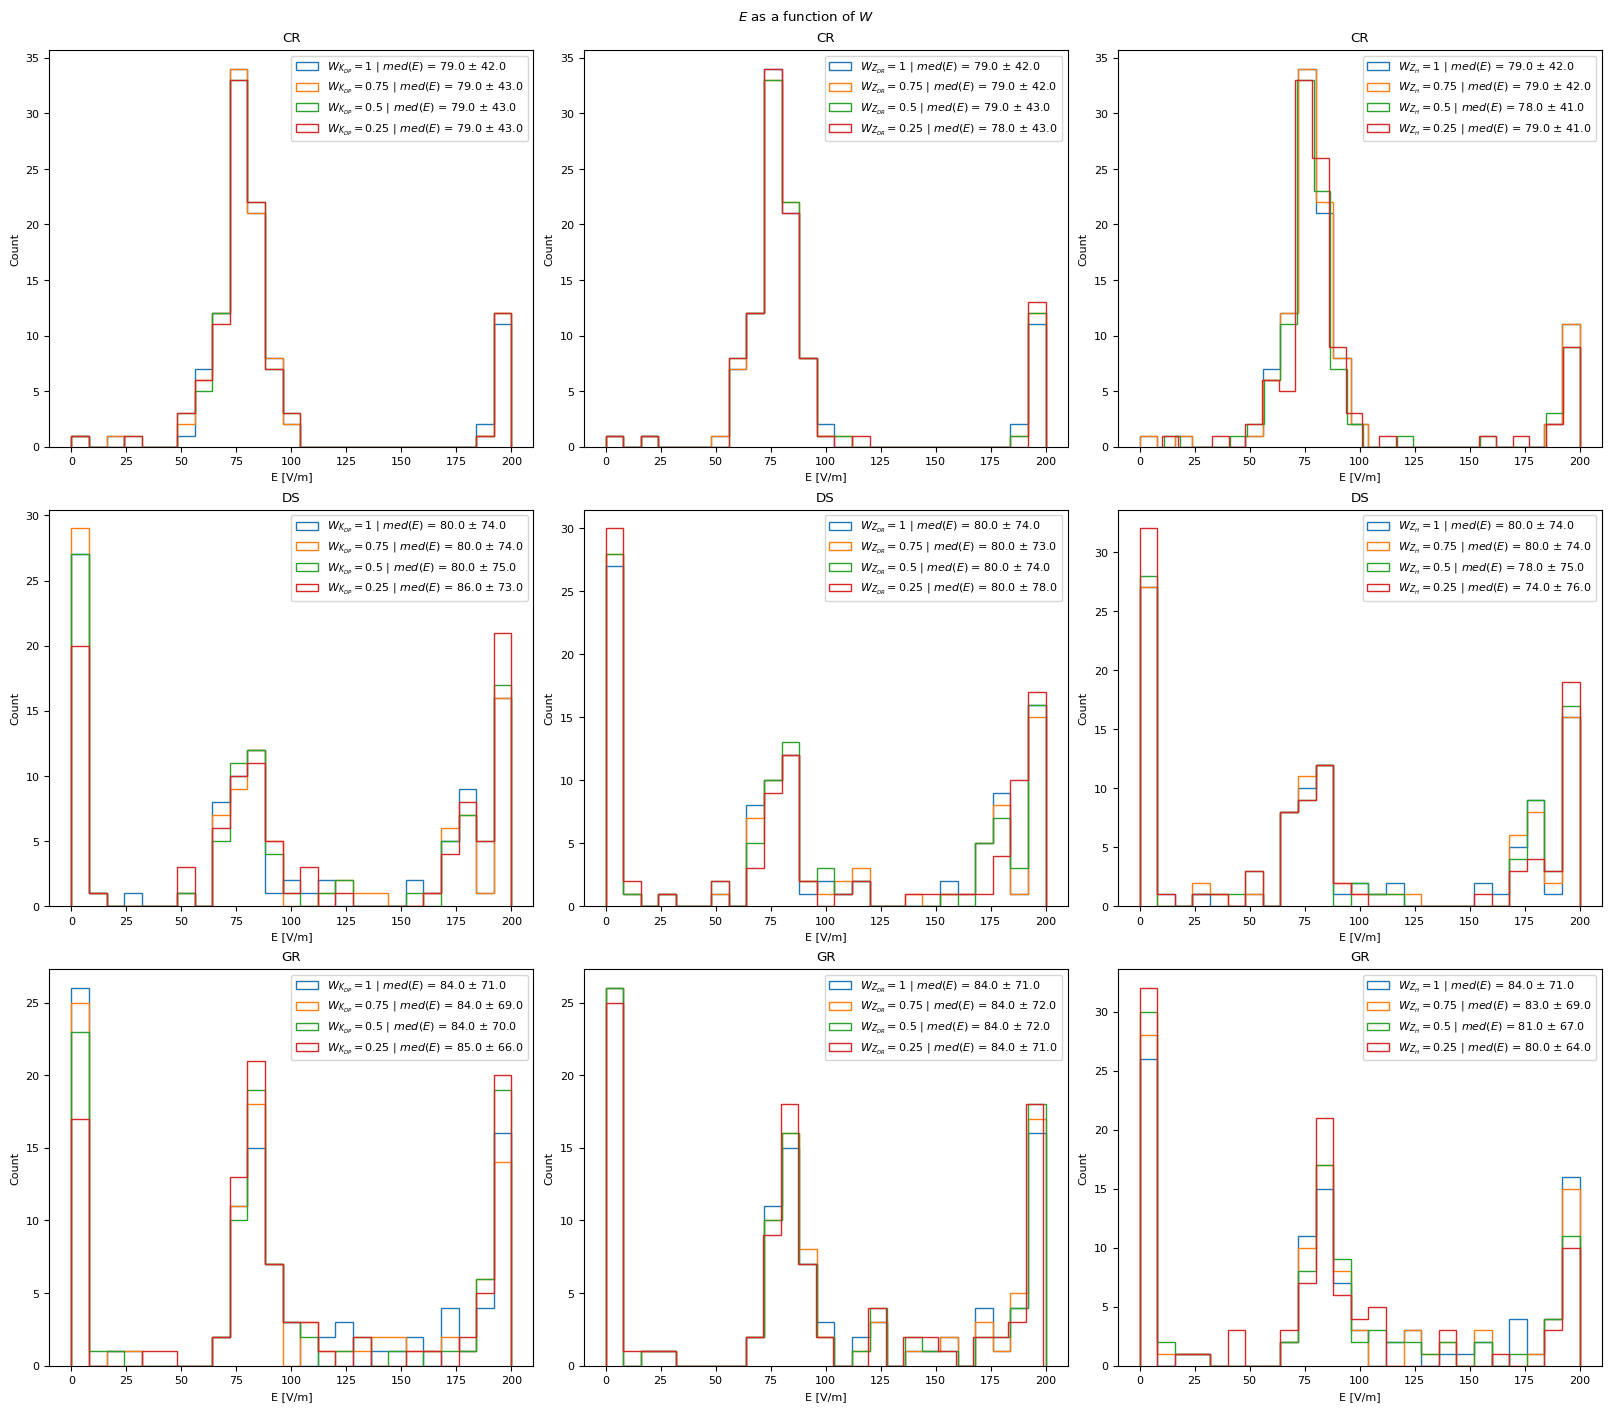

In [28]:
#plot the test results
fig, axs = plt.subplots(3,3,figsize=[16,14], constrained_layout=True)

axs.ravel()[0].hist(crystal_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[0]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[0]))}')
axs.ravel()[0].hist(crystal_results[1], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[1]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[1]))}')
axs.ravel()[0].hist(crystal_results[2], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[2]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[2]))}')
axs.ravel()[0].hist(crystal_results[3], bins = 25, histtype='step', stacked=True, fill=False,\
                    label = r'$W_{K_{DP}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[3]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[3]))}')
axs.ravel()[0].set_xlabel('E [V/m]')
axs.ravel()[0].set_ylabel('Count')
axs.ravel()[0].legend()
axs.ravel()[0].set_title(r'CR')

axs.ravel()[1].hist(crystal_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[0]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[0]))}')
axs.ravel()[1].hist(crystal_results[4], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[4]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[4]))}')
axs.ravel()[1].hist(crystal_results[5], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[5]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[5]))}')
axs.ravel()[1].hist(crystal_results[6], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[6]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[6]))}')
axs.ravel()[1].set_xlabel('E [V/m]')
axs.ravel()[1].set_ylabel('Count')
axs.ravel()[1].legend()
axs.ravel()[1].set_title(r'CR')

axs.ravel()[2].hist(crystal_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[0]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[0]))}')
axs.ravel()[2].hist(crystal_results[7], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[7]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[7]))}')
axs.ravel()[2].hist(crystal_results[8], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[8]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[8]))}')
axs.ravel()[2].hist(crystal_results[9], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(crystal_results[9]))}' + r' $\pm$' + f' {np.round(np.std(crystal_results[9]))}')
axs.ravel()[2].set_xlabel('E [V/m]')
axs.ravel()[2].set_ylabel('Count')
axs.ravel()[2].legend()
axs.ravel()[2].set_title(r'CR')

axs.ravel()[3].hist(snow_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[0]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[0]))}')
axs.ravel()[3].hist(snow_results[1], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[1]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[1]))}')
axs.ravel()[3].hist(snow_results[2], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[2]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[2]))}')
axs.ravel()[3].hist(snow_results[3], bins = 25, histtype='step', stacked=True, fill=False,\
                    label = r'$W_{K_{DP}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[3]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[3]))}')
axs.ravel()[3].set_xlabel('E [V/m]')
axs.ravel()[3].set_ylabel('Count')
axs.ravel()[3].legend()
axs.ravel()[3].set_title(r'DS')

axs.ravel()[4].hist(snow_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[0]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[0]))}')
axs.ravel()[4].hist(snow_results[4], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[4]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[4]))}')
axs.ravel()[4].hist(snow_results[5], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[5]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[5]))}')
axs.ravel()[4].hist(snow_results[6], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[6]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[6]))}')
axs.ravel()[4].set_xlabel('E [V/m]')
axs.ravel()[4].set_ylabel('Count')
axs.ravel()[4].legend()
axs.ravel()[4].set_title(r'DS')

axs.ravel()[5].hist(snow_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[0]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[0]))}')
axs.ravel()[5].hist(snow_results[7], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[7]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[7]))}')
axs.ravel()[5].hist(snow_results[8], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[8]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[8]))}')
axs.ravel()[5].hist(snow_results[9], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(snow_results[9]))}' + r' $\pm$' + f' {np.round(np.std(snow_results[9]))}')
axs.ravel()[5].set_xlabel('E [V/m]')
axs.ravel()[5].set_ylabel('Count')
axs.ravel()[5].legend()
axs.ravel()[5].set_title(r'DS')

axs.ravel()[6].hist(graupel_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[0]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[0]))}')
axs.ravel()[6].hist(graupel_results[1], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[1]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[1]))}')
axs.ravel()[6].hist(graupel_results[2], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[2]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[2]))}')
axs.ravel()[6].hist(graupel_results[3], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{K_{DP}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[3]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[3]))}')
axs.ravel()[6].set_xlabel('E [V/m]')
axs.ravel()[6].set_ylabel('Count')
axs.ravel()[6].legend()
axs.ravel()[6].set_title(r'GR')

axs.ravel()[7].hist(graupel_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[0]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[0]))}')
axs.ravel()[7].hist(graupel_results[4], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[4]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[4]))}')
axs.ravel()[7].hist(graupel_results[5], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[5]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[5]))}')
axs.ravel()[7].hist(graupel_results[6], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{DR}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[6]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[6]))}')
axs.ravel()[7].set_xlabel('E [V/m]')
axs.ravel()[7].set_ylabel('Count')
axs.ravel()[7].legend()
axs.ravel()[7].set_title(r'GR')

axs.ravel()[8].hist(graupel_results[0], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=1$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[0]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[0]))}')
axs.ravel()[8].hist(graupel_results[7], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.75$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[7]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[7]))}')
axs.ravel()[8].hist(graupel_results[8], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.5$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[8]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[8]))}')
axs.ravel()[8].hist(graupel_results[9], bins = 25, histtype='step', stacked=True, fill=False,
                    label = r'$W_{Z_{H}}=0.25$' + r' | $med(E)$' + f' = {np.round(np.median(graupel_results[9]))}' + r' $\pm$' + f' {np.round(np.std(graupel_results[9]))}')
axs.ravel()[8].set_xlabel('E [V/m]')
axs.ravel()[8].set_ylabel('Count')
axs.ravel()[8].legend()
axs.ravel()[8].set_title(r'GR')

fig.suptitle('$E$ as a function of $W$')

plt.savefig('tests.png', dpi = 300, bbox_inches = 'tight')

In [12]:
# List of all files you need to load
file_mapping = {
    ('CR', 4000): 'sim_full_plate_5000_S.pkl',
    ('CR', 5000): 'sim_full_plate_5000_S.pkl',
    ('CR', 6000): 'sim_full_plate_6000_S.pkl',
    ('CR', 7000): 'sim_full_plate_7000_S.pkl',
    ('CR', 8000): 'sim_full_plate_8000_S.pkl',
    ('CR', 9000): 'sim_full_plate_9000_S.pkl',
    ('CR', 10000): 'sim_full_column_10000_S.pkl',
    ('CR', 11000): 'sim_full_column_11000_S.pkl',
    ('CR', 12000): 'sim_full_column_12000_S.pkl',
    ('CR', 13000): 'sim_full_column_13000_S.pkl',
    ('CR', 14000): 'sim_full_column_14000_S.pkl',
    ('CR', 15000): 'sim_full_column_15000_S.pkl',
    ('DS', 4000): 'sim_mix_plates_snow_5000_S.pkl',
    ('DS', 5000): 'sim_mix_plates_snow_5000_S.pkl',
    ('DS', 6000): 'sim_mix_plates_snow_6000_S.pkl',
    ('DS', 7000): 'sim_mix_plates_snow_7000_S.pkl',
    ('DS', 8000): 'sim_mix_plates_snow_8000_S.pkl',
    ('DS', 9000): 'sim_mix_plates_snow_9000_S.pkl',
    ('DS', 10000): 'sim_mix_columns_snow_10000_S.pkl',
    ('DS', 11000): 'sim_mix_columns_snow_11000_S.pkl',
    ('DS', 12000): 'sim_mix_columns_snow_12000_S.pkl',
    ('DS', 13000): 'sim_mix_columns_snow_13000_S.pkl',
    ('DS', 14000): 'sim_mix_columns_snow_14000_S.pkl',
    ('DS', 15000): 'sim_mix_columns_snow_15000_S.pkl',
    ('GR', 4000): 'sim_mix_plates_graupel_5000_S.pkl',
    ('GR', 5000): 'sim_mix_plates_graupel_5000_S.pkl',
    ('GR', 6000): 'sim_mix_plates_graupel_6000_S.pkl',
    ('GR', 7000): 'sim_mix_plates_graupel_7000_S.pkl',
    ('GR', 8000): 'sim_mix_plates_graupel_8000_S.pkl',
    ('GR', 9000): 'sim_mix_plates_graupel_9000_S.pkl',
    ('GR', 10000): 'sim_mix_columns_graupel_10000_S.pkl',
    ('GR', 11000): 'sim_mix_columns_graupel_11000_S.pkl',
    ('GR', 12000): 'sim_mix_columns_graupel_12000_S.pkl',
    ('GR', 13000): 'sim_mix_columns_graupel_13000_S.pkl',
    ('GR', 14000): 'sim_mix_columns_graupel_14000_S.pkl',
    ('GR', 15000): 'sim_mix_columns_graupel_15000_S.pkl',
}


loaded_tables = {}
print("Loading lookup tables into memory...")
for key, fname in tqdm(file_mapping.items()):
    try:
        with open(fname, 'rb') as f:
            loaded_tables[key] = pickle.load(f)[0]
    except FileNotFoundError:
        print(f"Warning: {fname} not found. Skipping.")

for key in loaded_tables:
    for var in ['kdp', 'zh', 'zdr']:
        loaded_tables[key][var] = loaded_tables[key][var].astype(np.float16)

Loading lookup tables into memory...


  0%|          | 0/36 [00:00<?, ?it/s]

In [15]:
#retrieve the E field for the sweep closest to the flash initiation.
x,y,z=radar.get_gate_x_y_z(sweep)
z=z.flatten()

Z_H = radar.get_field(sweep, 'reflectivity').flatten()
Z_DR = radar.get_field(sweep, 'differential_reflectivity').flatten()
K_DP = radar.get_field(sweep, 'specific_differential_phase').flatten()
HCA_labels = radar.get_field(sweep, 'HCA_label').flatten()

weight_sets = [
    (1, 1, 0.25),
    (1, 0.5, 0.25),
    (1, 0.25, 0)
]


# 1. Use a physical disk directory for temp files to avoid /dev/shm filling up
temp_folder = os.path.expanduser('~/joblib_temp')
if not os.path.exists(temp_folder):
    os.makedirs(temp_folder)


final_results = Parallel(n_jobs=10, backend='threading')(
    delayed(process_hca_label_optimized)(
        n, h, z, weight_sets, K_DP, Z_H, Z_DR, E, loaded_tables
    ) for n, h in enumerate(tqdm(HCA_labels))
)

  0%|          | 0/87456 [00:00<?, ?it/s]


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather 

Text(0.5, 0.98, 'Horus 11.875$^{\\circ}$')

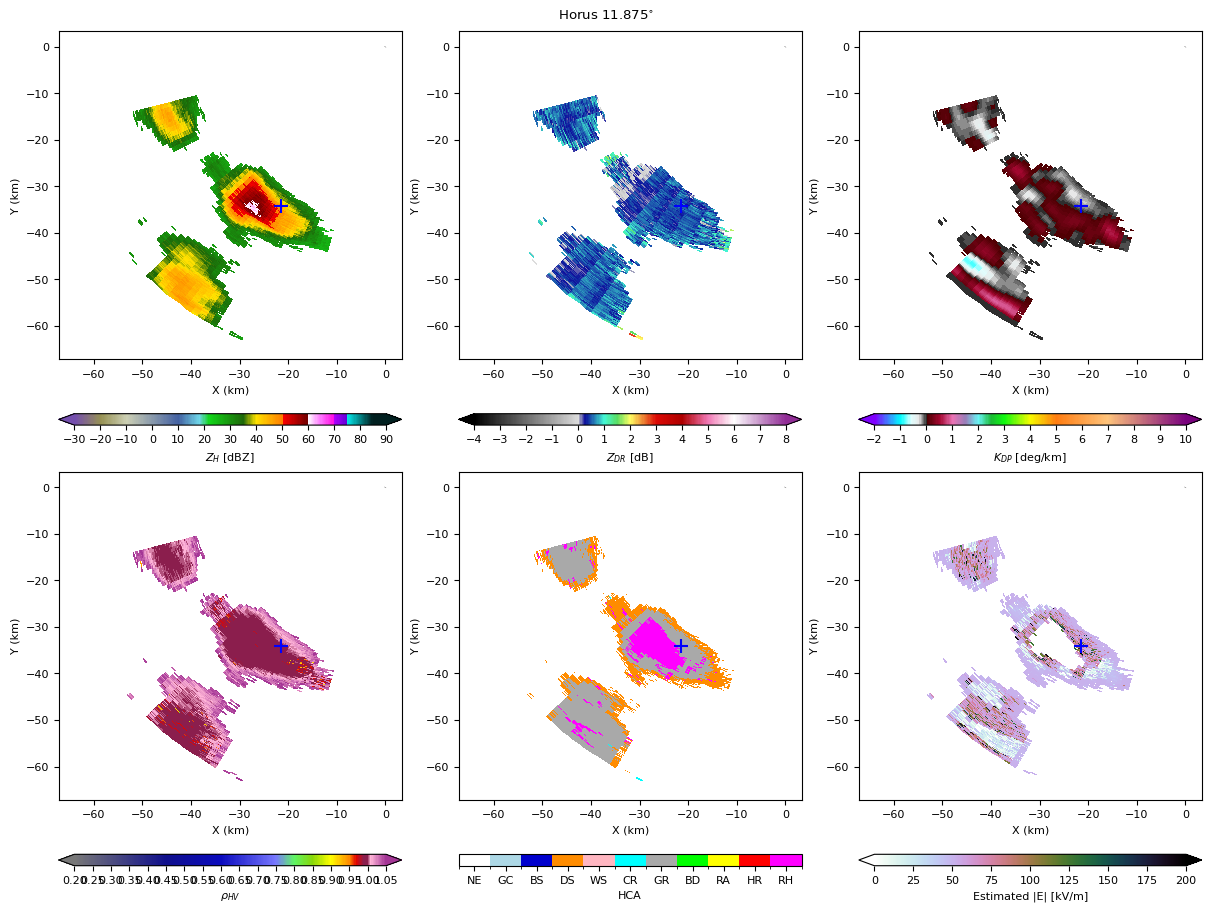

In [32]:
# Plot the results
x1,y1,z1=radar.get_gate_x_y_z(sweep,)
x1/=1000
y1/=1000
z1/=1000

xf = -21.4
yf = -34.2

E_f = np.asarray(final_results).reshape(radar.get_field(sweep, 'reflectivity').shape)

fig, axs = plt.subplots(2,3,figsize=[12,9],constrained_layout=True)

a = axs.ravel()[0].pcolormesh(x1,y1,radar.get_field(sweep, 'reflectivity'), cmap=ref_cmap, norm=ref_norm)
cbar = plt.colorbar(a, ticks=ZH_Ticks, orientation='horizontal', label = r'$Z_H$ [dBZ]', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[1].pcolormesh(x1,y1,radar.get_field(sweep, 'differential_reflectivity'), cmap=zdr_cmap, norm=zdr_norm)
cbar = plt.colorbar(a, ticks=ZDR_Ticks, orientation='horizontal', label = r'$Z_{DR}$ [dB]', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[2].pcolormesh(x1,y1,radar.get_field(sweep, 'specific_differential_phase'), cmap=kdp_cmap, norm=kdp_norm)
cbar = plt.colorbar(a, ticks=KDP_Ticks, orientation='horizontal', label = r'$K_{DP}$ [deg/km]', extend='both', aspect = 30)
cbar.minorticks_off() 

a = axs.ravel()[3].pcolormesh(x1,y1,radar.get_field(sweep, 'cross_correlation_ratio'), cmap=rho_cmap, norm=rho_norm)
cbar = plt.colorbar(a, ticks=RHO_Ticks, orientation='horizontal', label = r'$\rho_{HV}$', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[4].pcolormesh(x1,y1,radar.get_field(sweep, 'HCA_id'),cmap=cmaphid, norm=norm)
cbar = plt.colorbar(a, ticks=ticks.tolist(), orientation='horizontal', label = r'HCA', aspect = 30)
cbar.ax.set_xticklabels(TP) 

a = axs.ravel()[5].pcolormesh(x1,y1,E_f,vmin=0, vmax=200, cmap='cubehelix_r')
cbar = fig.colorbar(a, orientation='horizontal', label = r'Estimated |E| [kV/m]', extend='both', aspect = 30)
cbar.minorticks_off() 

x = np.linspace(10,70,100)*np.sin(np.deg2rad(theta))/1e3
y = np.linspace(10,70,100)*np.cos(np.deg2rad(theta))/1e3
for ax in axs.ravel():
    #ax.set_xlim(-50, -10)
    #ax.set_ylim(-50, -10)
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.plot(x,y, 'k--')
    ax.scatter(xf,yf, 100, c='blue', marker='+')

fig.suptitle(f'Horus {radar.get_elevation(sweep)[0]}'+'$^{\circ}$')
#plt.savefig('E_ppi.png', bbox_inches='tight', dpi=300)

In [95]:
# repeat, but now for the cross section
radar1 = pyart.util.cross_section_ppi(radar, [theta])

x2,y2,z2=radar1.get_gate_x_y_z(0)
z2 = z2.flatten()

Z_H = radar1.get_field(0, 'reflectivity').flatten().astype(np.float16)
Z_DR = radar1.get_field(0, 'differential_reflectivity').flatten().astype(np.float16)
K_DP = radar1.get_field(0, 'specific_differential_phase').flatten().astype(np.float16)
HCA_labels = radar1.get_field(0, 'HCA_label').flatten()

weight_sets = [
    (1, 1, 0.25),
    (1, 0.5, 0.25),
    (1, 0.25, 0)
]

# 1. Use a physical disk directory for temp files to avoid /dev/shm filling up
temp_folder = os.path.expanduser('~/joblib_temp')
if not os.path.exists(temp_folder):
    os.makedirs(temp_folder)


final_results = Parallel(n_jobs=10, backend='threading')(
    delayed(process_hca_label_optimized)(
        n, h, z2, weight_sets, K_DP, Z_H, Z_DR, E, loaded_tables
    ) for n, h in enumerate(tqdm(HCA_labels))
)

  0%|          | 0/29152 [00:00<?, ?it/s]


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather 

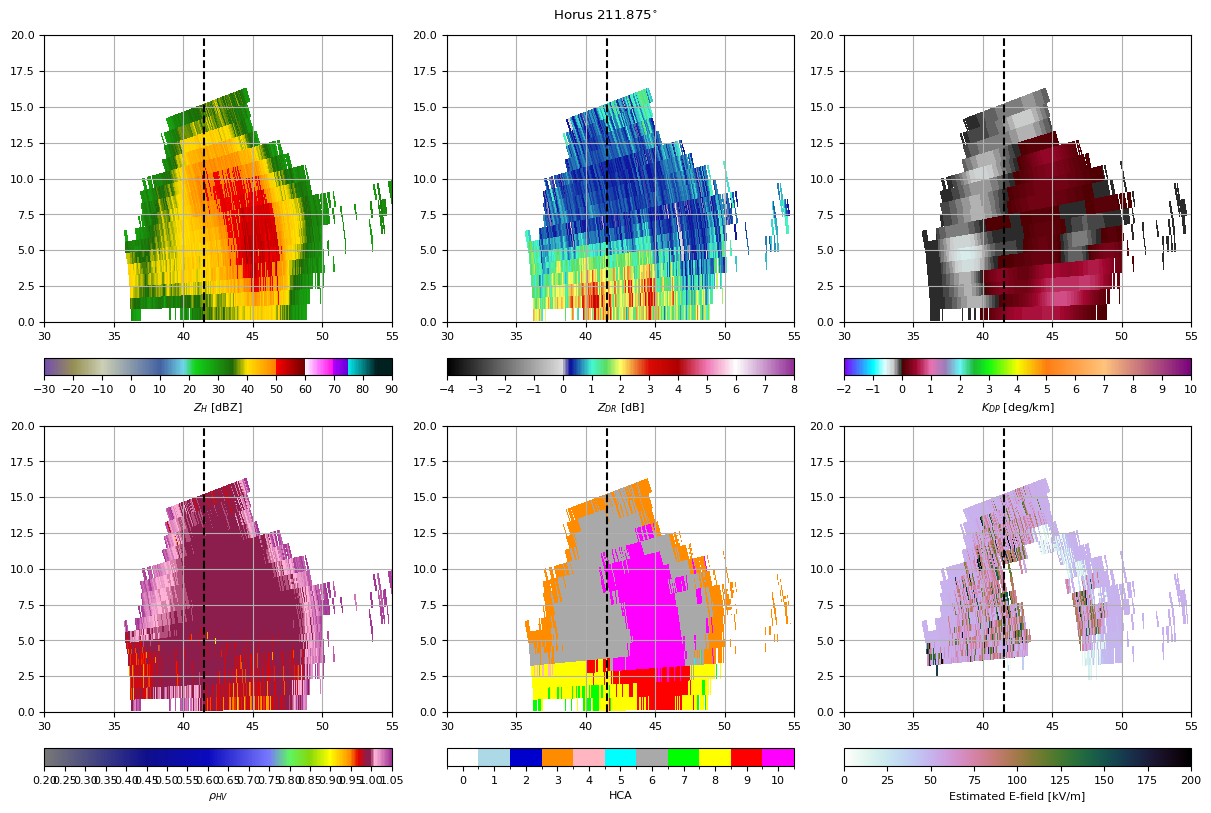

In [96]:
xf = -21.4
yf = -34.2

x2,y2,z2=radar1.get_gate_x_y_z(0)
z2 = z2.flatten()

r2 = np.sqrt(x2**2+y2**2)/1e3
z2 = z2.reshape(r2.shape)/1e3
dist= np.sqrt(xf**2+yf**2)/1e3


E_f2 = np.asarray(final_results).reshape(radar1.fields['reflectivity']['data'].shape)

fig, axs = plt.subplots(2,3,figsize=[12,8],constrained_layout=True)

a = axs.ravel()[0].pcolormesh(r2,z2,radar1.fields['reflectivity']['data'], cmap=ref_cmap, norm=ref_norm)
cbar = plt.colorbar(a, ticks=ZH_Ticks, orientation='horizontal', label = r'$Z_H$ [dBZ]')

a = axs.ravel()[1].pcolormesh(r2,z2,radar1.get_field(0, 'differential_reflectivity'), cmap=zdr_cmap, norm=zdr_norm)
cbar = plt.colorbar(a, ticks=ZDR_Ticks, orientation='horizontal', label = r'$Z_{DR}$ [dB]') 

a = axs.ravel()[2].pcolormesh(r2,z2,radar1.get_field(0, 'specific_differential_phase'), cmap=kdp_cmap, norm=kdp_norm)
cbar = plt.colorbar(a, ticks=KDP_Ticks, orientation='horizontal', label = r'$K_{DP}$ [deg/km]')

a = axs.ravel()[3].pcolormesh(r2,z2,radar1.get_field(0, 'cross_correlation_ratio'), cmap=rho_cmap, norm=rho_norm)
cbar = plt.colorbar(a, ticks=RHO_Ticks, orientation='horizontal', label = r'$\rho_{HV}$')

a = axs.ravel()[4].pcolormesh(r2,z2,radar1.get_field(0, 'HCA_id'),cmap=cmaphid, norm=norm)
cbar = plt.colorbar(a, ticks=ticks.tolist(), orientation='horizontal', label = r'HCA')

a = axs.ravel()[5].pcolormesh(r2,z2,E_f2,vmin=0, vmax=200, cmap='cubehelix_r')
fig.colorbar(a, orientation='horizontal', label = r'Estimated E-field [kV/m]')

for ax in axs.ravel():
    ax.axvline(41.5, c='k', linestyle='--')
    ax.set_xlim(30, 55)
    ax.set_ylim(0, 20)
    ax.grid()

fig.suptitle(f'Horus {radar1.get_azimuth(0)[0]}'+'$^{\circ}$')
plt.savefig('E_rhi.png', bbox_inches='tight', dpi=300)

In [18]:
E_f = np.asarray(graupel_results).reshape(radar.get_field(sweep, 'reflectivity').shape)

NameError: name 'graupel_results' is not defined

LMA data already in memory


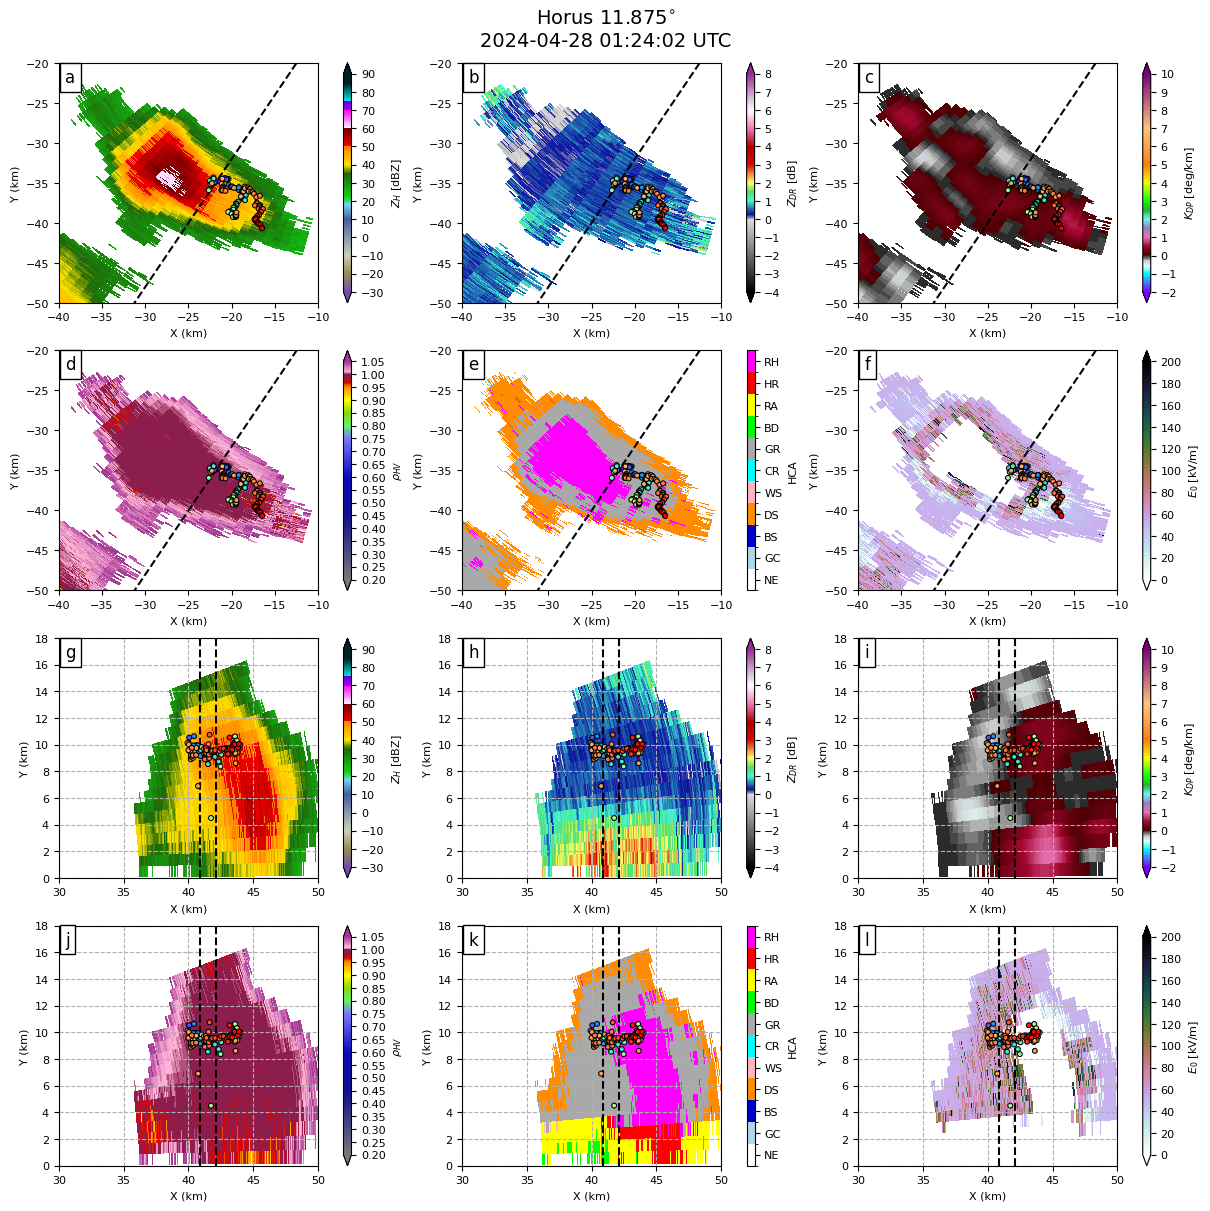

In [40]:
# Make the figure with the LMA sources
import string
from pyxlma.lmalib.io import read as lma_read
from pyxlma.plot.xlma import XlmaPlot
from pyxlma.lmalib.flash.cluster import cluster_flashes
from pyxlma.lmalib.flash.properties import flash_stats
from pyxlma.lmalib.grid import  create_regular_grid, assign_regular_bins, events_to_grid

#with open('horus_E.pickle',mode='rb') as f:
#    E_f = pickle.load(f)

#radar.add_field('E', {'data':E_f['E'].reshape(radar.fields['reflectivity']['data'].shape)}, replace_existing=True)

theta = 212
x = radar.range['data']*np.sin(np.deg2rad(theta))/1e3
y = radar.range['data']*np.cos(np.deg2rad(theta))/1e3
radar1 = pyart.util.cross_section_ppi(radar, [theta])

x2,y2,z2=radar1.get_gate_x_y_z(0)
z2 = z2.flatten()
r2 = np.sqrt(x2**2+y2**2)/1e3
z2 = z2.reshape(r2.shape)/1e3
dist= 41.5


min_stations = 6 # more stations = more confident it's a good solution
max_chi = 5 # lower reduced chi^2 = more confident it's a good solution
tbuffer = 60 # How many seconds around the radar scan time do you want to plot LMA data?
max_dist = 25e3 # meters, max distance of an LMA source to a radar grid centroid to be plotted
transparent = 'True' # True to increase transparency of sources farther from the grid centroid 
method = 'kdtree'

rx,ry,rz = radar.get_gate_x_y_z(9)

radar_time1 = pyart.util.datetime_from_radar(radar)
radar_time1 = datetime.strptime(str(radar_time1),'%Y-%m-%d %H:%M:%S')
tmin = 0.4 
tmax = .9

# Set your directory with the LMA files
LMA_dir = '/home/vitorgoede/work/LMA/20240427_OKLMA/'
if 'event_time' in locals():
    if ((radar_time1-timedelta(minutes=0))>event_time.min())&(
        (radar_time1+timedelta(minutes=1))<event_time.max()):
        print ('LMA data already in memory')
        pass
    else:
        print ('LMA data in memory for incorrect time. Reading new data now.')
        filenames = glob.glob('{}L*{}000_0600.dat.gz'.format(LMA_dir,
                     (radar_time1-timedelta(minutes=0)).strftime('%Y%m%d_%H%M')[2:-1]))
        filenames = filenames + glob.glob('{}L*{}000_0600.dat.gz'.format(LMA_dir,
                     (radar_time1-timedelta(minutes=1)).strftime('%Y%m%d_%H%M')[2:-1]))
        filenames = list(set(filenames))
        lma_data, starttime = lma_read.dataset(filenames)
else:
    print ('LMA data has not be read in yet. Reading now.')
    filenames = glob.glob('{}L*{}000_0600.dat.gz'.format(LMA_dir,
                 (radar_time1-timedelta(minutes=1)).strftime('%Y%m%d_%H%M')[2:-1]))
    filenames = filenames + glob.glob('{}L*{}000_0600.dat.gz'.format(LMA_dir,
                 (radar_time1-timedelta(minutes=1)).strftime('%Y%m%d_%H%M')[2:-1]))
    filenames = list(set(filenames))
    lma_data, starttime = lma_read.dataset(filenames)

# xarray doesn't handle time well, so switch that to a pandas object
event_time = pd.Series(lma_data.event_time)

# Pull times +/- tbuffer from the radartime (from the file name)
min_t = radar_time1+timedelta(seconds=tmin) # Nevermind before, use start time
max_t = radar_time1+timedelta(seconds=tmax)

# Select all the good sources
selection = (lma_data.event_stations>min_stations)&(
             lma_data.event_chi2<max_chi)&(
             event_time>min_t)&(
             event_time<max_t)

# Pull x,y,z on a radar-centered grid
lma_z = lma_data.event_altitude[selection]
lma_x, lma_y = pyart.core.geographic_to_cartesian_aeqd(lma_data.event_longitude[selection], 
                                        lma_data.event_latitude[selection],
                                        radar.longitude['data'][0], 
                                        radar.latitude['data'][0], R=6370997.0)


box = (lma_x>-55e3) & (lma_x<-20) & (lma_y>-55e3) & (lma_y<-10e3)

lma_z2 = lma_data.event_altitude[selection][box]
lma_x2, lma_y2 = pyart.core.geographic_to_cartesian_aeqd(lma_data.event_longitude[selection][box], 
                                        lma_data.event_latitude[selection][box],
                                        radar1.longitude['data'][0], 
                                        radar1.latitude['data'][0], R=6370997.0)

if method == 'kdtree':
    # Convert to range
    cartesian_lma_r = (lma_x2**2+lma_y2**2)**0.5
    # Define a KD tree of the radar grid points
    radar_tree = spatial.KDTree(np.array([x2.ravel(), 
                                          y2.ravel(), 
                                          z2.ravel()]).T)
    # Look for LMA sources near the radar grid points
    dists, indext = radar_tree.query(np.array([lma_x2,lma_y2,lma_z2]).T)

elif method == 'cartesian':
    az_rad = np.deg2rad(radar.azimuth["data"][0]-90)
    cartesian_lma_r = lma_x*np.cos(az_rad) - lma_y*np.sin(az_rad) # Cartesian x
    dists           = lma_y*np.cos(az_rad) + lma_x*np.sin(az_rad) # Cartesian y

sel2 = np.abs(dists)<max_dist

t = lma_data.event_time[selection][box].values.astype(datetime)
t2 = lma_data.event_time[selection][box][sel2].values.astype(datetime)

fig, axs = plt.subplots(4,3,figsize=[12,12],constrained_layout=True)

a = axs.ravel()[0].pcolormesh(x1,y1,radar.get_field(sweep, 'reflectivity'), cmap=ref_cmap, norm=ref_norm)
cbar = plt.colorbar(a, ticks=ZH_Ticks, orientation='vertical', label = r'$Z_H$ [dBZ]', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[1].pcolormesh(x1,y1,radar.get_field(sweep, 'differential_reflectivity'), cmap=zdr_cmap, norm=zdr_norm)
cbar = plt.colorbar(a, ticks=ZDR_Ticks, orientation='vertical', label = r'$Z_{DR}$ [dB]', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[2].pcolormesh(x1,y1,radar.get_field(sweep, 'specific_differential_phase'), cmap=kdp_cmap, norm=kdp_norm)
cbar = plt.colorbar(a, ticks=KDP_Ticks, orientation='vertical', label = r'$K_{DP}$ [deg/km]', extend='both', aspect = 30)
cbar.minorticks_off() 

a = axs.ravel()[3].pcolormesh(x1,y1,radar.get_field(sweep, 'cross_correlation_ratio'), cmap=rho_cmap, norm=rho_norm)
cbar = plt.colorbar(a, ticks=RHO_Ticks, orientation='vertical', label = r'$\rho_{HV}$', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[4].pcolormesh(x1,y1,radar.get_field(sweep, 'HCA_id'), cmap=cmaphid, norm=norm)
cbar = plt.colorbar(a, ticks=ticks.tolist(), orientation='vertical', label = r'HCA', aspect = 30)
cbar.ax.set_yticklabels(TP) 

a = axs.ravel()[5].pcolormesh(x1,y1, E_f, vmin=0, vmax=200, cmap='cubehelix_r')
cbar = fig.colorbar(a, ticks=np.arange(0, 220, 20), orientation='vertical', label = r'$E_0$ [kV/m]', extend='both', aspect = 30)
cbar.minorticks_off() 

a = axs.ravel()[6].pcolormesh(r2,z2,radar1.get_field(0, 'reflectivity'), cmap=ref_cmap, norm=ref_norm)
cbar = plt.colorbar(a, ticks=ZH_Ticks, orientation='vertical', label = r'$Z_H$ [dBZ]', extend='both', aspect = 30)
cbar.minorticks_off() 

a = axs.ravel()[7].pcolormesh(r2,z2,radar1.get_field(0, 'differential_reflectivity'), cmap=zdr_cmap, norm=zdr_norm)
cbar = plt.colorbar(a, ticks=ZDR_Ticks, orientation='vertical', label = r'$Z_{DR}$ [dB]', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[8].pcolormesh(r2,z2,radar1.get_field(0, 'specific_differential_phase'), cmap=kdp_cmap, norm=kdp_norm)
cbar = plt.colorbar(a, ticks=KDP_Ticks, orientation='vertical', label = r'$K_{DP}$ [deg/km]', extend='both', aspect = 30)
cbar.minorticks_off() 

a = axs.ravel()[9].pcolormesh(r2,z2,radar1.get_field(0, 'cross_correlation_ratio'), cmap=rho_cmap, norm=rho_norm)
cbar = plt.colorbar(a, ticks=RHO_Ticks, orientation='vertical', label = r'$\rho_{HV}$', extend='both', aspect = 30)
cbar.minorticks_off()

a = axs.ravel()[10].pcolormesh(r2,z2,radar1.get_field(0, 'HCA_id'),cmap=cmaphid, norm=norm)
cbar = plt.colorbar(a, ticks=ticks.tolist(), orientation='vertical', label = r'HCA', aspect = 30)
cbar.ax.set_yticklabels(TP) 

a = axs.ravel()[11].pcolormesh(r2,z2,E_f2,vmin=0, vmax=200, cmap='cubehelix_r')
cbar = fig.colorbar(a, ticks=np.arange(0, 220, 20), orientation='vertical', label = r'$E_0$ [kV/m]', extend='both', aspect = 30)
cbar.minorticks_off()

x = np.linspace(10000, 90000, 1000)*np.sin(np.deg2rad(theta))/1e3
y = np.linspace(10000, 90000, 1000)*np.cos(np.deg2rad(theta))/1e3

# 2. Setup the Colormap and Normalization
cmap_name = 'rainbow'
t_cmap = cm.get_cmap(cmap_name)

# 1. Ensure t is a NumPy array of floating-point numbers
# This handles cases where t is a list, tuple, or a non-standard array type.
t_data = np.asarray(t, dtype=np.float64)

# 2. Re-calculate the normalization using the converted data array
t_norm = mplcolors.Normalize(vmin=t_data.min(), vmax=t_data.max())

# 3. Apply normalization/colormap using the clean array
edge_colors_array_t = t_cmap(t_norm(t_data))
letters = list(string.ascii_lowercase)

for n,ax in enumerate(axs.ravel()):
    ax.annotate(letters[n], xy = (0.025, 0.92), xycoords = 'axes fraction', fontsize = 12, bbox={'facecolor':'white', 'clip_on':True}, zorder = 50)
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    if n <=5:
        if len(t) > 0:
            c = ax.scatter(lma_x[box]/1e3, lma_y[box]/1e3, c=t, vmin = t[0], vmax = t[-1], edgecolors='k',
                           s=50, marker='.', linewidths = 0.75, cmap = 'rainbow', zorder = 10)

        ax.set_xlim(-40, -10)
        ax.set_ylim(-50, -20)
        #ax.set_xticks(np.arange(-40, 5, 5))
        #ax.set_yticks(np.arange(-40, 5, 5))
        ax.plot(x,y, 'k--')
        #ax.scatter(xf,yf, 100, marker='*', c = "w", edgecolors = "k", linewidths = 1, zorder = 10)
    else:
        if len(t) > 0:
            c = ax.scatter(cartesian_lma_r[sel2]/1e3, lma_z2[sel2]/1e3, c=t, vmin = t[0], vmax = t[-1], edgecolors='k',
                           s=50, marker='.', linewidths = 0.75, cmap = 'rainbow', zorder = 10)
        [ax.axvline(rg, c='k', linestyle='--') for rg in [dist-0.6, dist+0.6]]
        #ax.axvline(dist, c='k', linestyle='--')
        ax.set_ylim(0, 18)
        ax.set_xlim(30, 50)
        #ax.set_xticks(np.arange(30, 80, 5))
        ax.grid(True, ls = '--')

fig.suptitle(f'Horus {radar.get_elevation(sweep)[0]}'+'$^{\circ}$' + '\n' + f'{radar_time1} UTC', fontsize = 14)
plt.savefig('E_all.png', bbox_inches='tight', dpi=300)

In [61]:
35/40*100

87.5

In [97]:
# Get the vertical profiles at 20 m steps in range centered over the initial source and save
arr = []
for d in np.arange(1e3*dist-0.6, 1e3*dist+0.6, .02):
    i = []
    for n in range(radar.nsweeps):
        i.append(np.argmin(np.abs(d-r2[n,:])))
        
for ii in i:
    arr.append(z2[:, ii])

myvar = [{'E': np.asarray([E_f2[:, ii] for ii in i]), 'z': np.asarray([z2[:, ii] for ii in i])}] 

#Open a file and use dump() 
with open('E_240428_012359000_100_pl.pkl', 'wb') as file: 
    # A new file will be created 
    pickle.dump(myvar, file) 

In [98]:
E_s=[]
for file in sorted(glob.glob('/home/vitorgoede/work/JAMC/*pl.pkl')):
    with open(file,mode='rb') as f:
        E_s.append(pickle.load(f)[0])

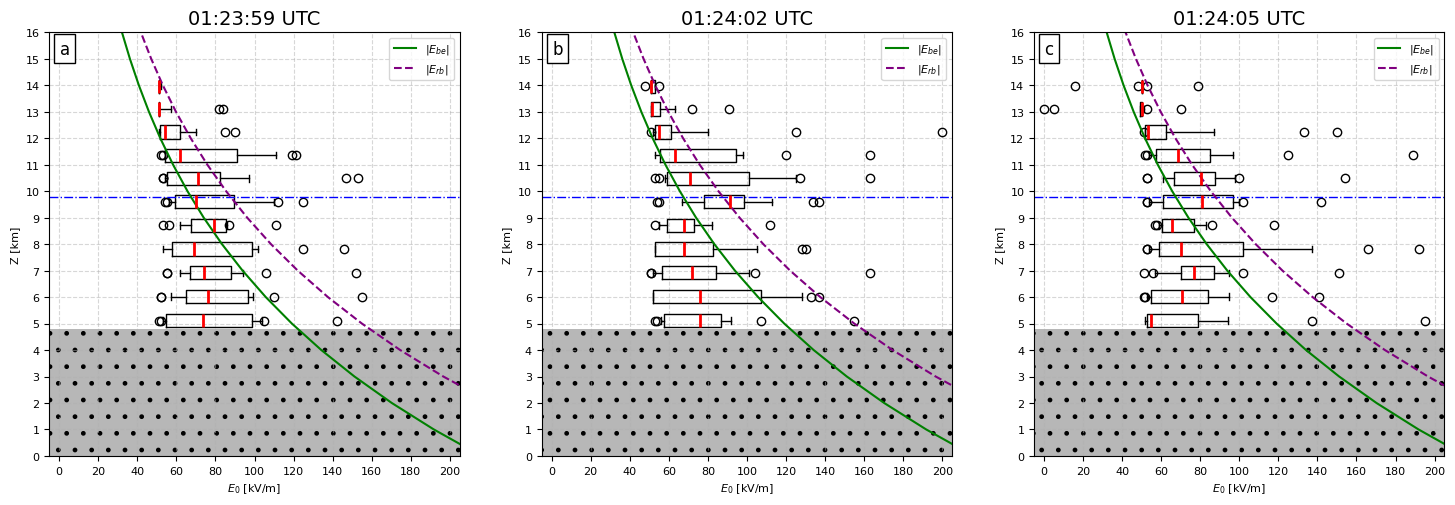

In [99]:
R, Z = np.meshgrid(np.arange(-10, 212, 10), np.arange(0, 4.769, 0.001))
C = np.ones_like(R)

# Calculate the average of 'z' along axis 0 to use for the x-axis positions.
# We use nanmean for safety, though the 'z' array in this data has no NaNs.
z_avg_per_column = np.nanmean(E_s[0]['z'], axis=0)

# Prepare 'E' data for boxplots. Matplotlib's boxplot expects a sequence of arrays,
# where each array contains the data for a single boxplot. We need to create an
# array of non-NaN values for each column of 'E'.
e_data_for_boxplot0 = [E_s[0]['E'][:, i][~np.isnan(E_s[0]['E'][:, i])] for i in range(E_s[0]['E'].shape[1])]
e_data_for_boxplot1 = [E_s[1]['E'][:, i][~np.isnan(E_s[1]['E'][:, i])] for i in range(E_s[1]['E'].shape[1])]
e_data_for_boxplot2 = [E_s[2]['E'][:, i][~np.isnan(E_s[2]['E'][:, i])] for i in range(E_s[2]['E'].shape[1])]

# Create the boxplot figure
fig, axs = plt.subplots(1,3,figsize=(18, 5.5))

# Plot the boxplots. The 'positions' argument places each boxplot at the
# corresponding value from our calculated z_avg_per_column.
axs.ravel()[0].boxplot(e_data_for_boxplot0[5:], positions=z_avg_per_column[5:], whis=(10, 90), widths=0.5, vert = False, medianprops={'color':'r', 'lw':2})
#axs.ravel()[0].plot(np.nanpercentile(E_s[0]['E'],90, 0), z_avg_per_column, 'r--', lw = 1, label = r'E 95th percentile')
axs.ravel()[0].set_title('01:23:59 UTC', fontsize = 14)

axs.ravel()[1].boxplot(e_data_for_boxplot1[5:], positions=z_avg_per_column[5:], whis=(10, 90), widths=0.5, vert = False, medianprops={'color':'r', 'lw':2})
#axs.ravel()[1].plot(np.nanpercentile(E_s[1]['E'],90, 0), z_avg_per_column, 'r--', lw = 1, label = r'E 95th percentile')
axs.ravel()[1].set_title('01:24:02 UTC', fontsize = 14)

axs.ravel()[2].boxplot(e_data_for_boxplot2[5:], positions=z_avg_per_column[5:], whis=(10, 90), widths=0.5, vert = False, medianprops={'color':'r', 'lw':2})
#axs.ravel()[2].plot(np.nanpercentile(E_s[2]['E'],90, 0), z_avg_per_column, 'r--', lw = 1, label = r'E 95th percentile')
axs.ravel()[2].set_title('01:24:05 UTC', fontsize = 14)

letters = list(string.ascii_lowercase)
for n,ax in enumerate(axs.ravel()):
    ax.annotate(letters[n], xy = (0.025, 0.95), xycoords = 'axes fraction', fontsize = 12, bbox={'facecolor':'white', 'clip_on':True}, zorder = 50)
    ax.contourf(R, Z, C, colors='gray', hatches=['.'], alpha=0.56, label='N/A')
    ax.axhline(9.8, c='b', linestyle='-.', lw=1)
    ax.plot(breakeven(np.arange(0,17))[0], np.arange(0,17), 'green', label = r'|$E_{be}$|')
    ax.plot(breakeven(np.arange(0,17))[1], np.arange(0,17), 'purple', ls = '--', label = r'|$E_{rb}$|')
    ax.set_xlim(-5, 205)
    ax.set_xticks(np.arange(0,220, 20))
    ax.set_ylim(0, 16)
    ax.set_yticks(np.arange(0,17, 1),
           ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16'])
    ax.grid(ls = '--', alpha = 0.5)
    ax.legend()
    ax.set_xlabel(r'$E_0$ [kV/m]')
    ax.set_ylabel('Z [km]')

plt.savefig('profile.png', dpi = 300, bbox_inches='tight')

In [68]:
myvar

[{'E': array([[ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  nan,  nan,  nan,
           nan,  nan,  nan,  nan,  nan],
         [ nan,  nan,  nan,  nan, 173.,  65.,  46.,  45.,  